# **Day-02 - Single-cell RNA-seq Marker Analysis and Cell Annotation - Bioinformatics Workshop 2026**

## Loading the library and other data
Download the following files from the UVA-box and upload here


1.   R_library.tar.gz
2.   obj_combined.integrated_40res.rds
3.   weighted_networks_nsga2r_final.rds
4.   lr_network_human_21122021.rds
5.   ligand_target_matrix_nsga2r_final.rds


In [ ]:
#untar("R_library.tar.gz")
#untar("library_23July2026.tar.gz")
#list.files("library")

In [ ]:
# change the R library directory into './library'
#.libPaths("library")

In [2]:
source("/content/setup.R")


Installing system libraries ...

Extracting ...

Library ready: 468 packages on .libPaths()[1] = /content/library



In [3]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.6.0 but the current version is
4.6.1; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.7.5 but the current
version is 1.7.6; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [4]:
obj40 <- readRDS(file = "obj_combined.integrated_40res.rds")
obj40

An object of class Seurat 
44779 features across 1868 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, umap, tsne

In [5]:
DefaultAssay(obj40) <- "SCT"

## Find markers for every cluster compared to all remaining cells, report only the positive ones
Prior to performing differential expression, we first run PrepSCTFindMarkers, which ensures that the fixed value is set properly.

In [6]:
obj40 <- PrepSCTFindMarkers(obj40)

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 2045.95476398253



In [7]:
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.markers <- FindAllMarkers(obj40, only.pos = TRUE, min.pct = 0.30, logfc.threshold = 0.30, recorrect_umi = FALSE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7



## Now lets generate heatmap and dotplot for each of the clusters.

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: CDKN2A, KCNB2, NRCAM, FDCSP, ENSG00000248515, SFRP1, NTRK2, CALML5, GNGT1”


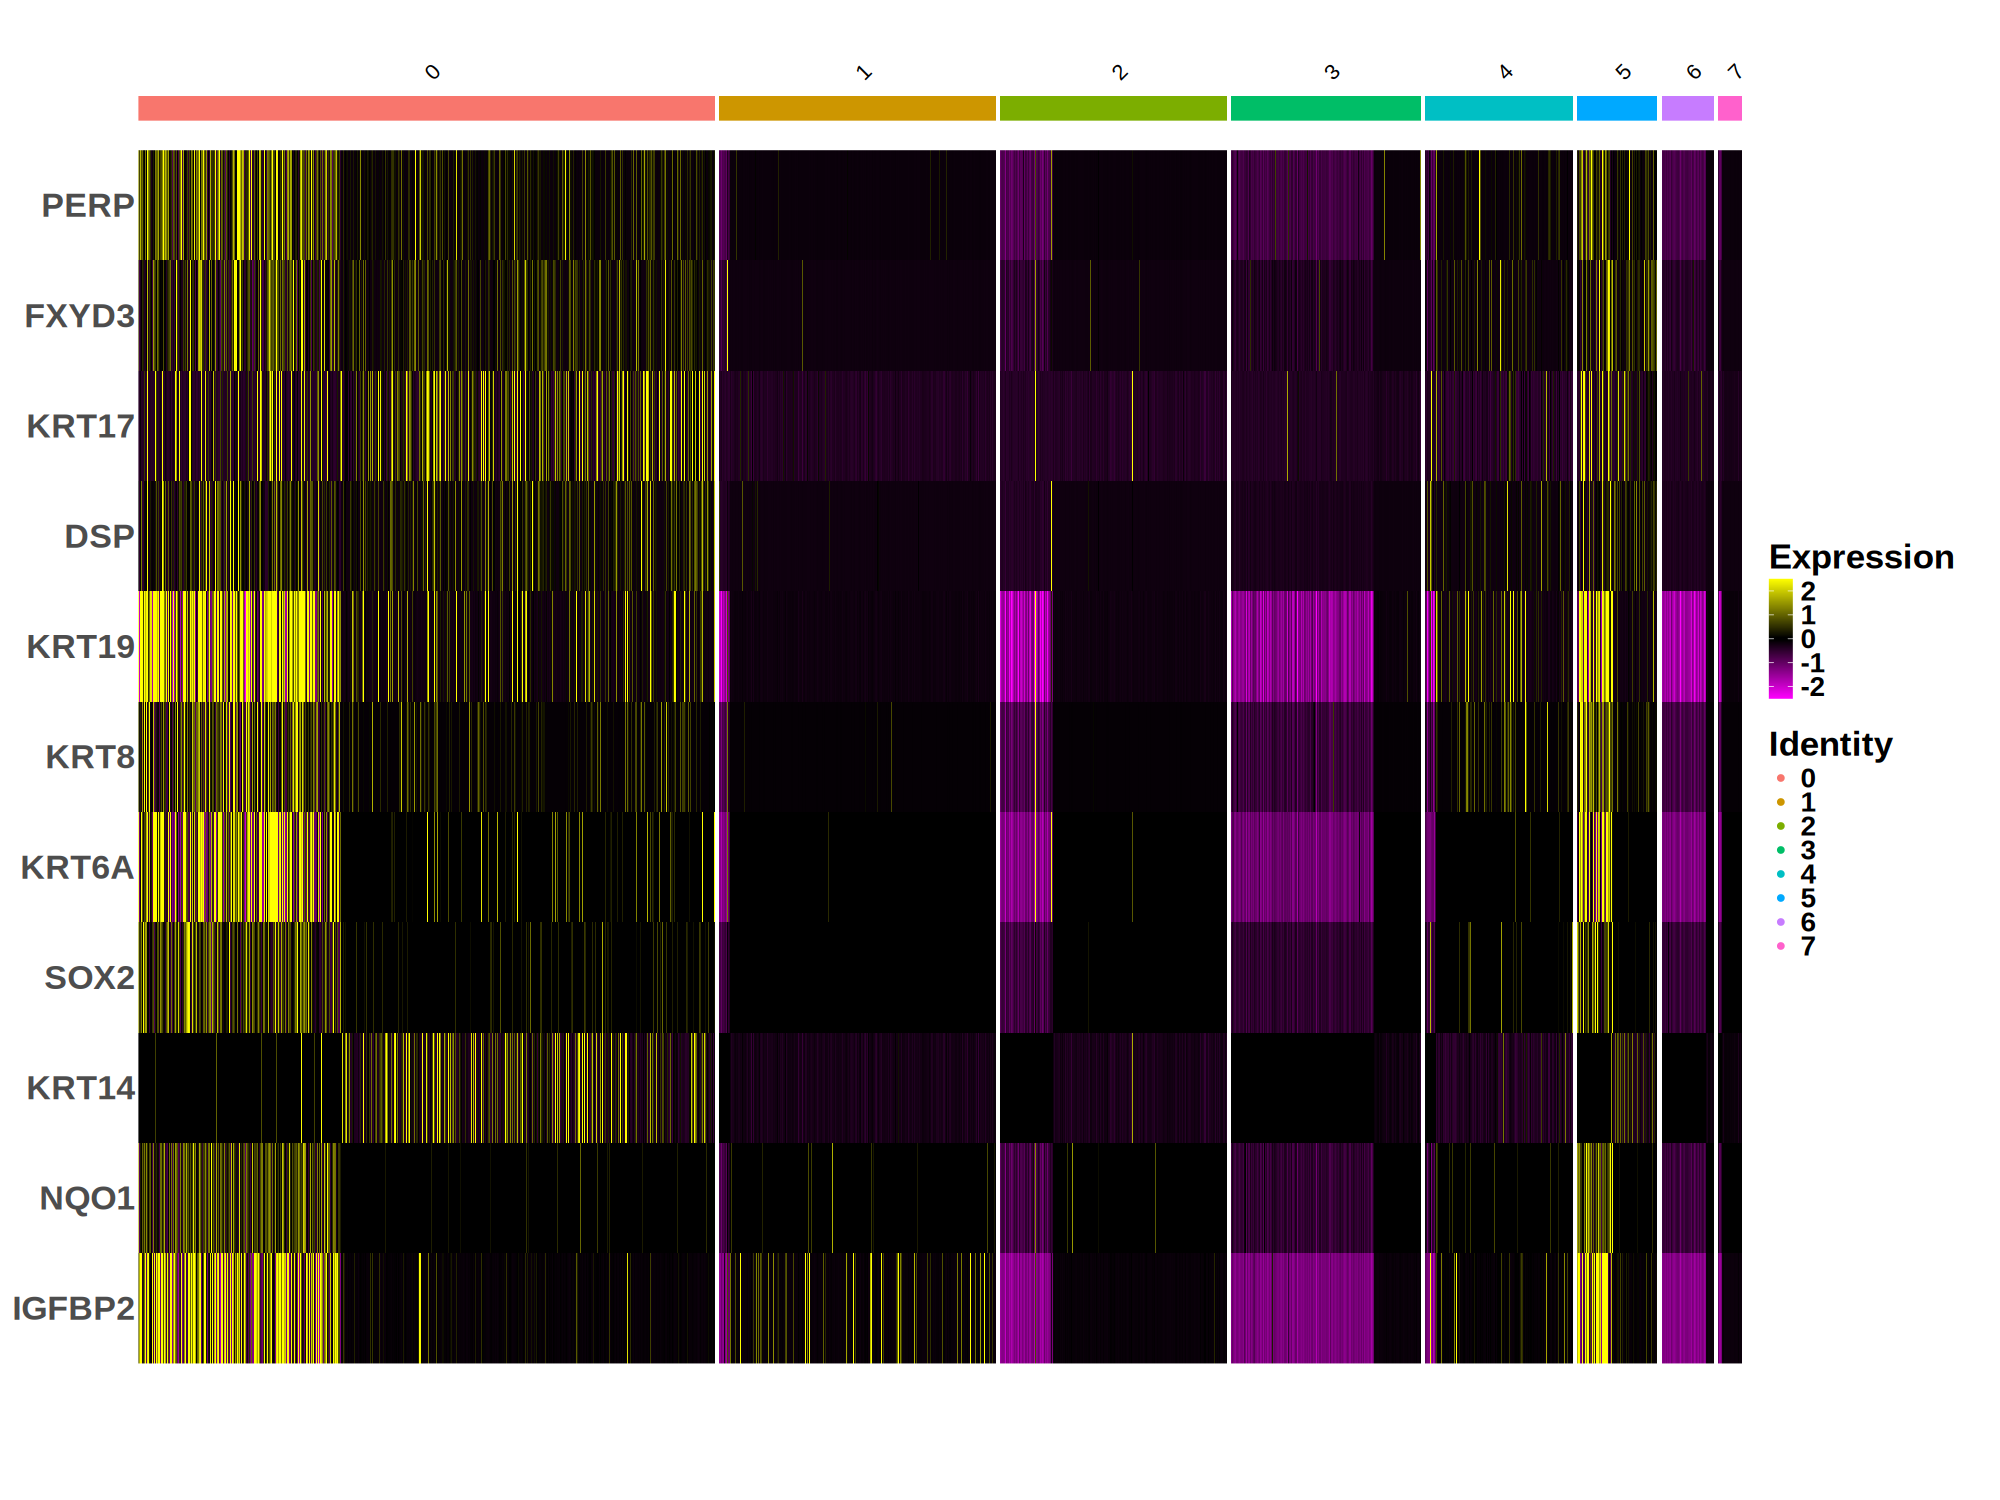

In [8]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_0.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster0.markers <- obj40.markers %>% filter(cluster==0) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), slot = "scale.data") & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

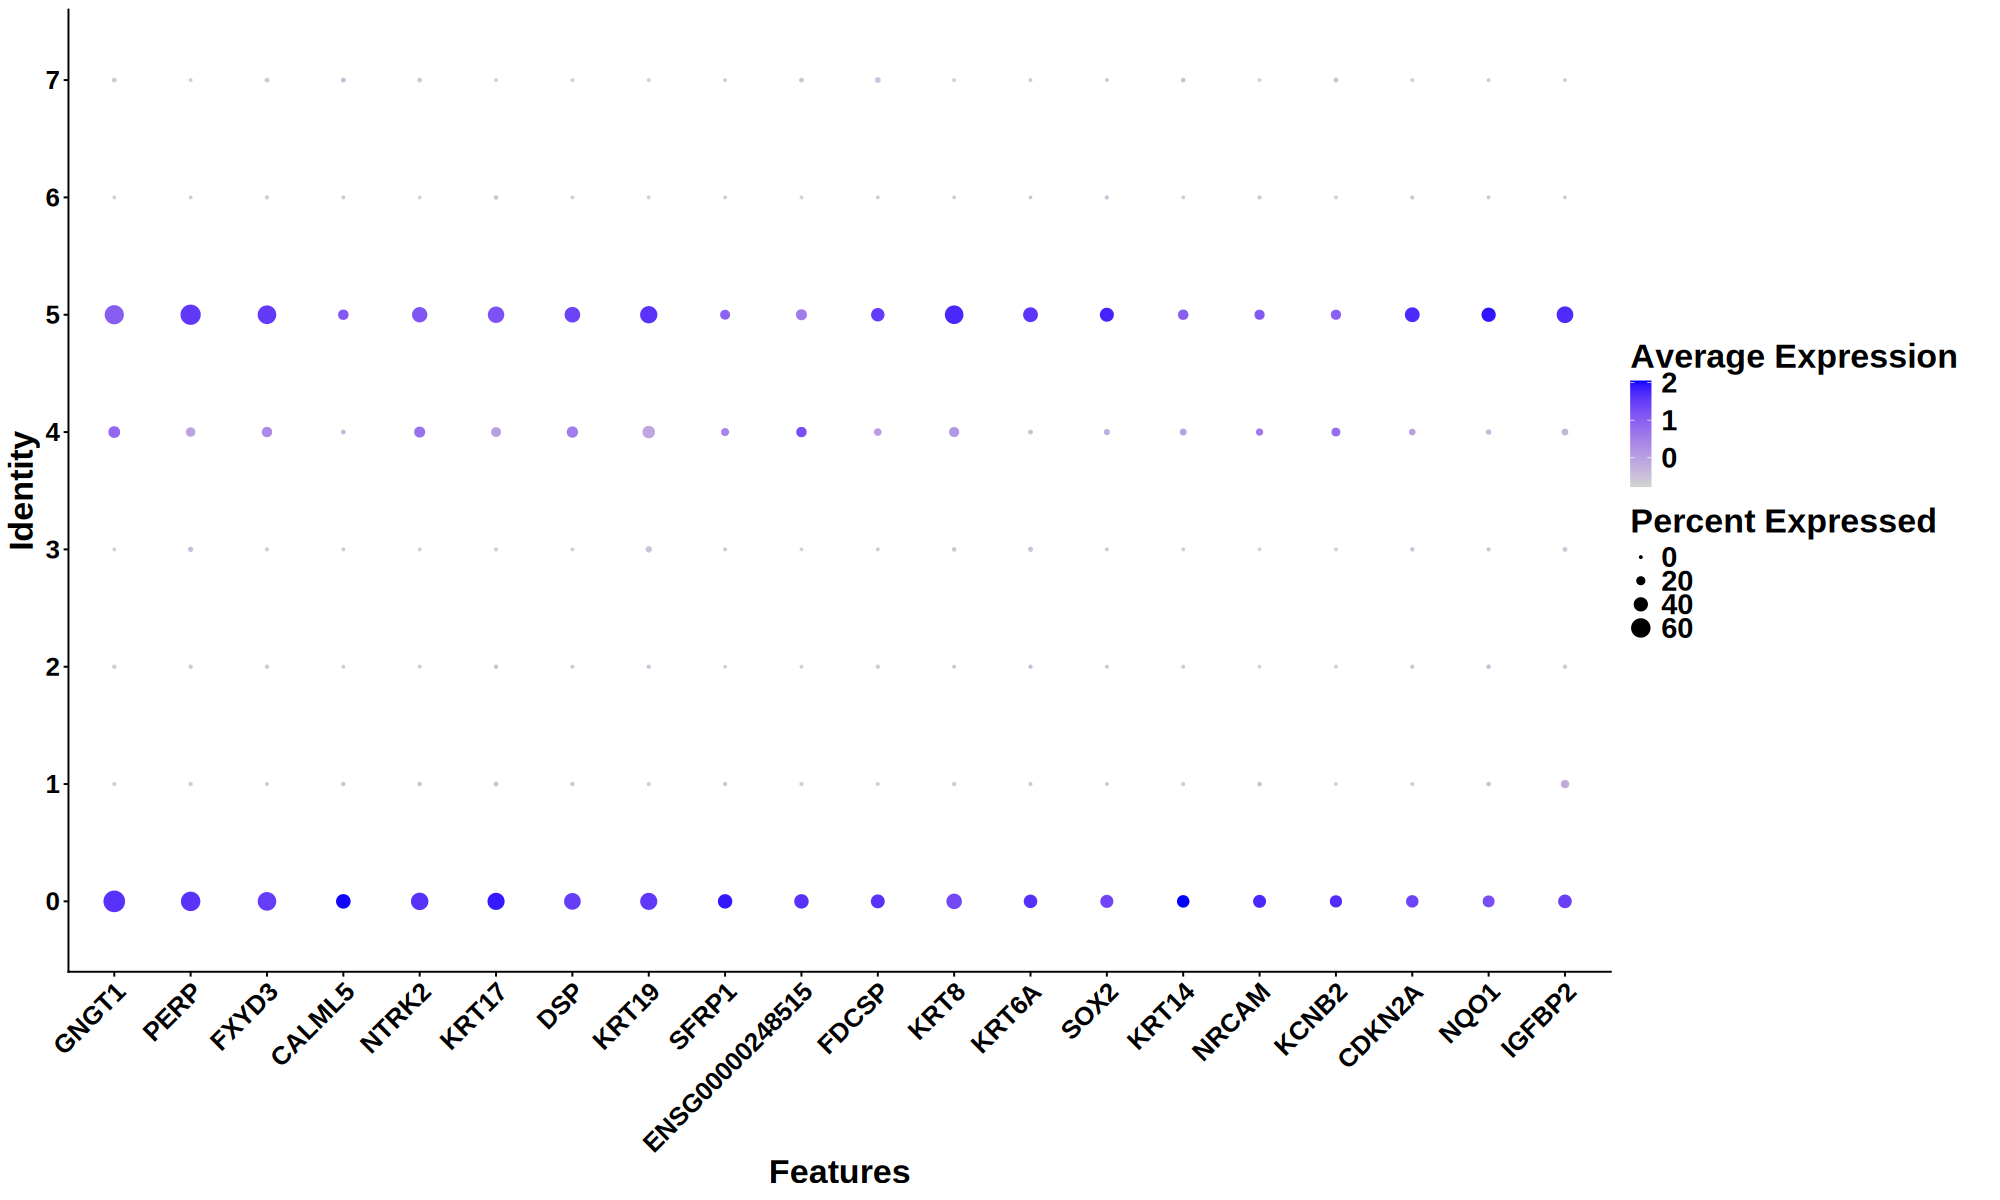

In [9]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_0
obj40.cluster0.markers$gene %>% write.table("obj40.cluster0.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster0.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PRSS23, PCOLCE, MMP2”


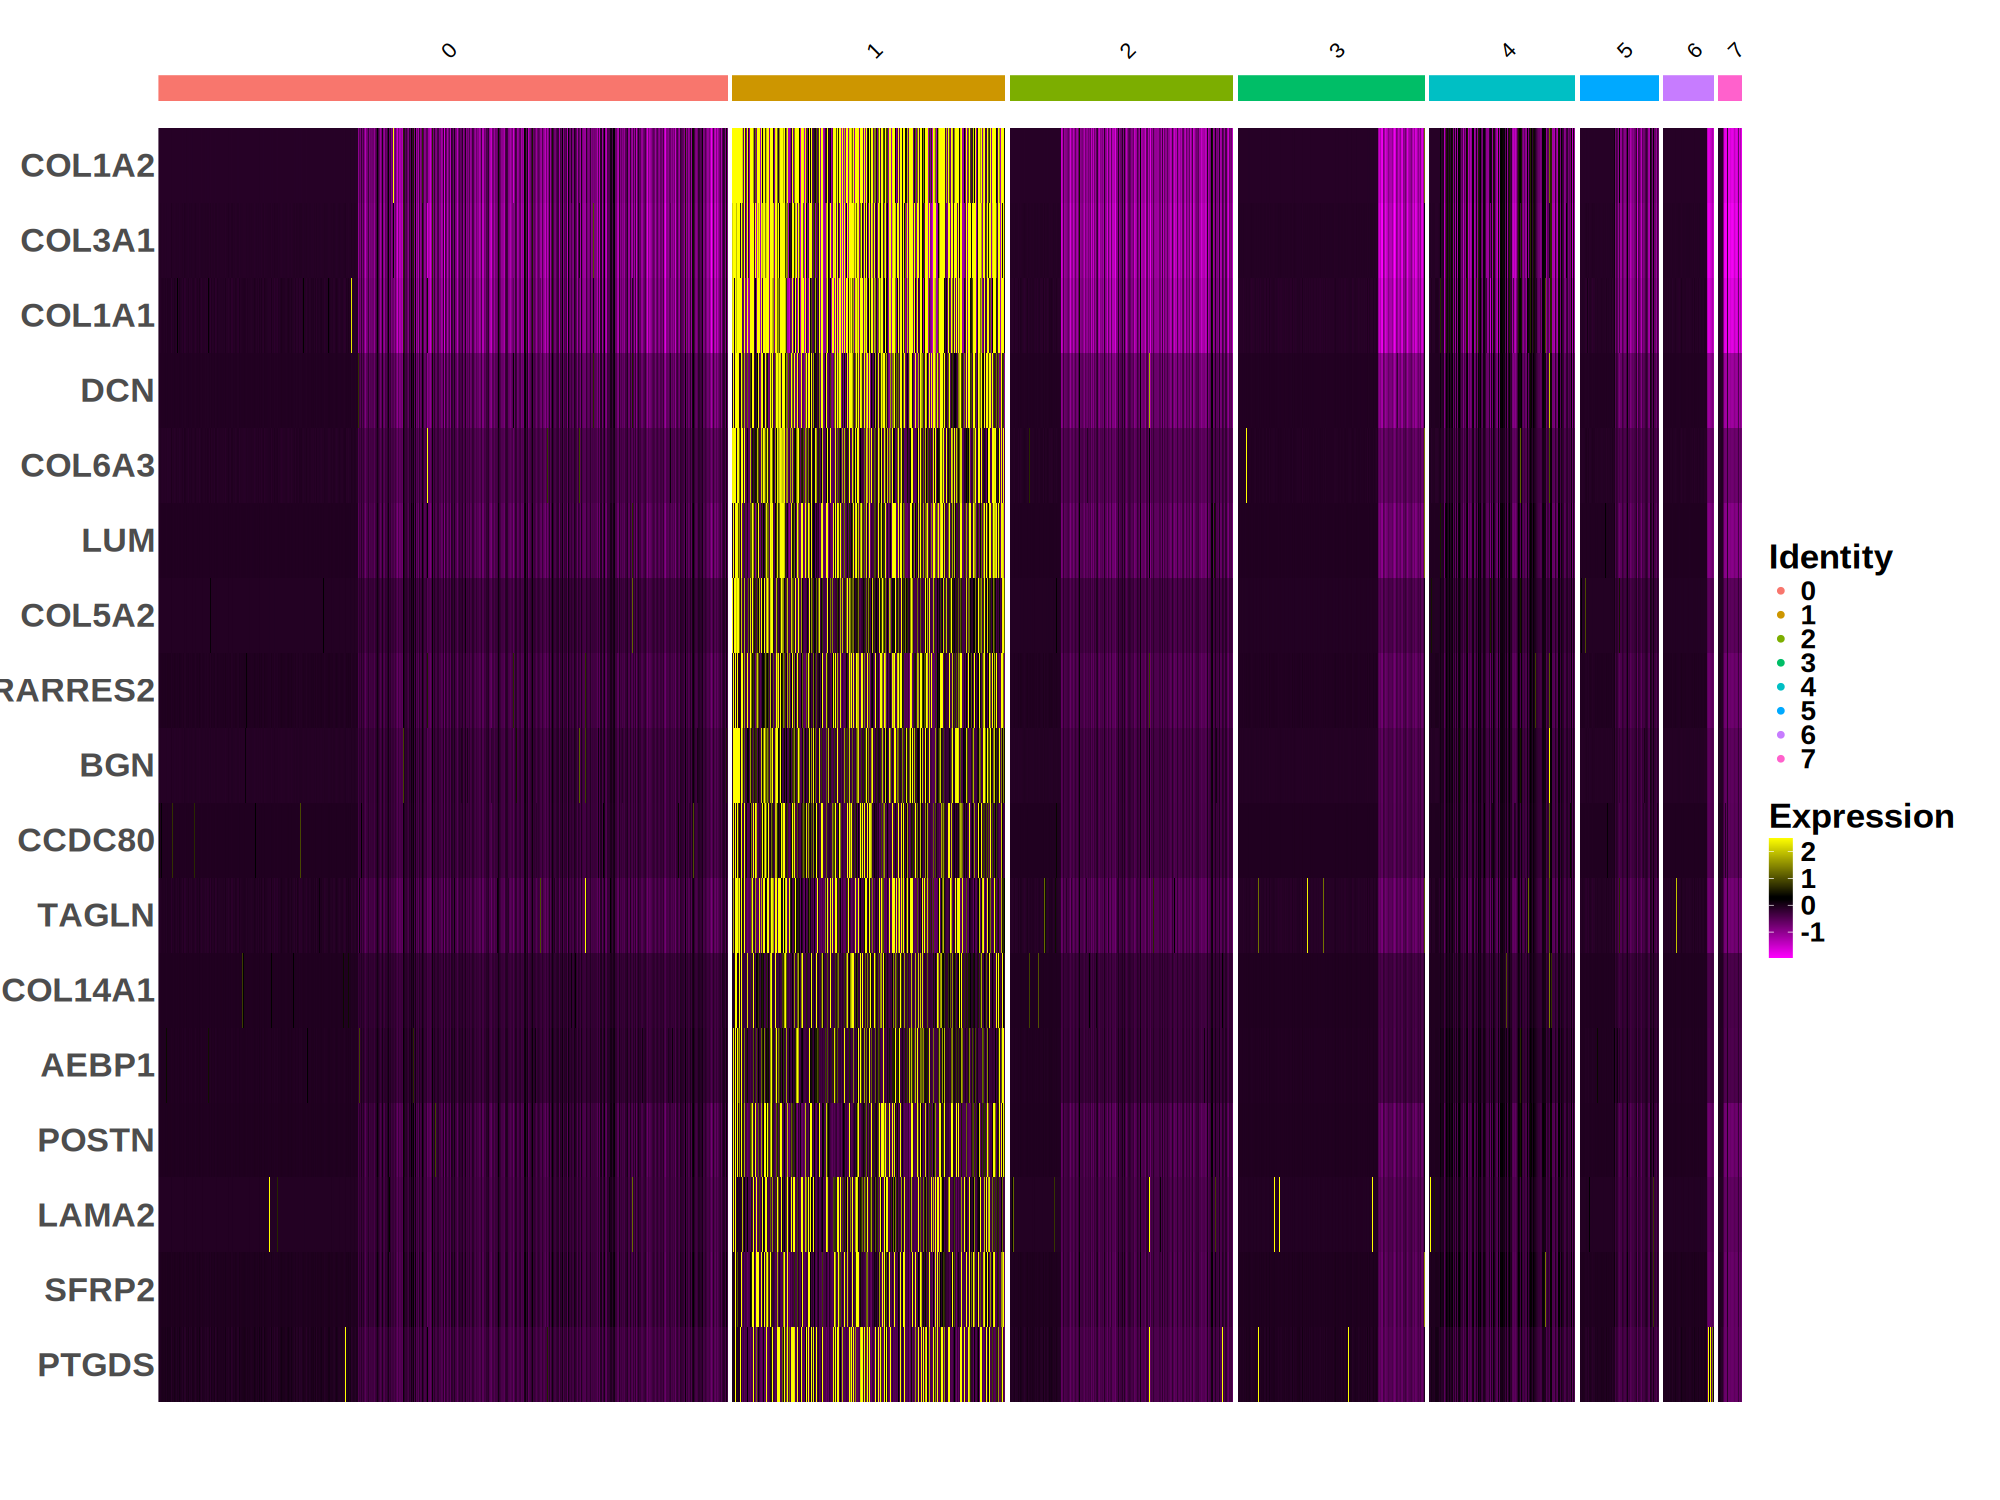

In [10]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_1.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster1.markers <- obj40.markers %>% filter(cluster==1) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), slot = "scale.data") & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))


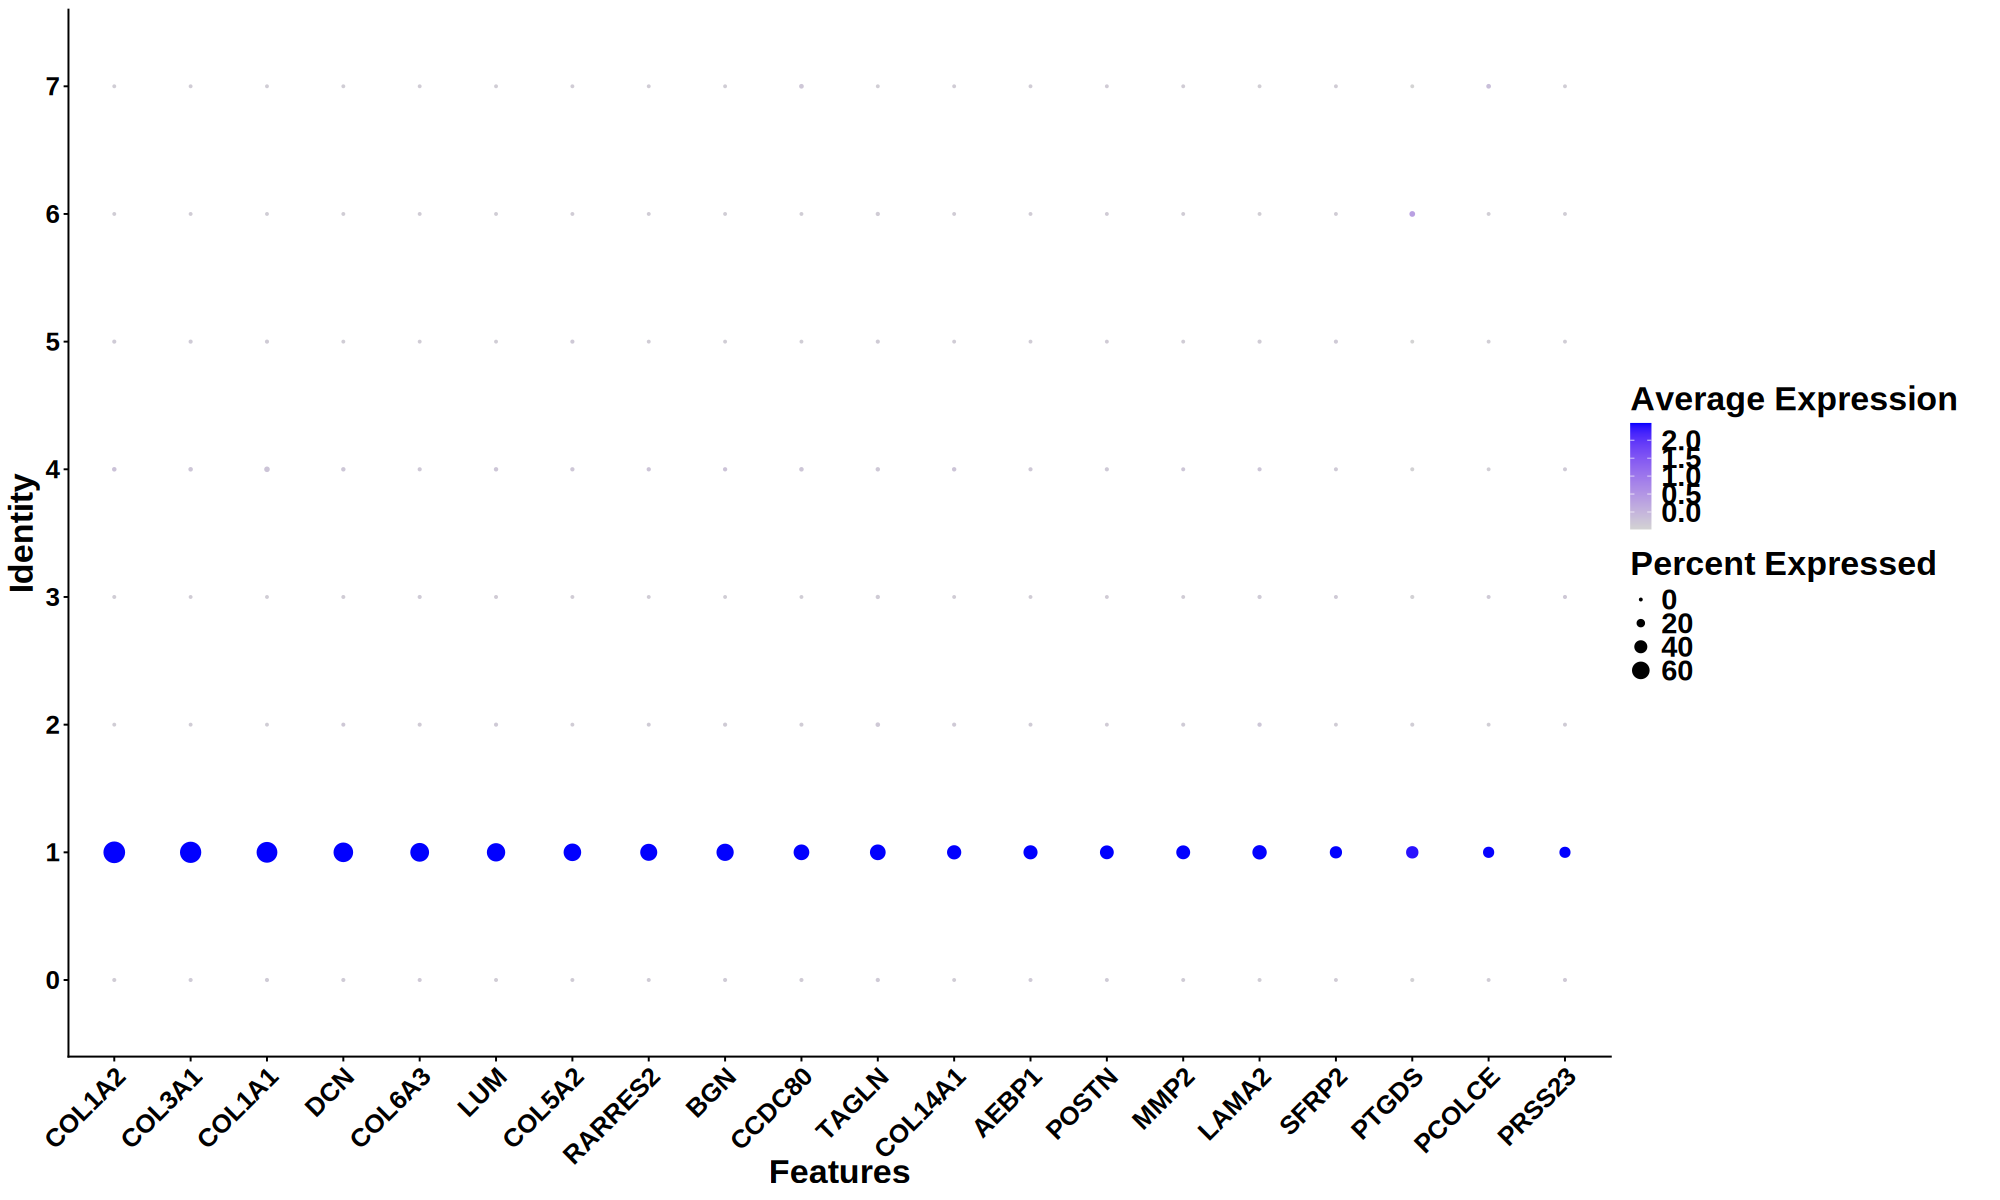

In [11]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_1
obj40.cluster1.markers$gene %>% write.table("obj40.cluster1.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster1.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: SPI1, MS4A4A, FCGR2A, CLEC7A, CD68”


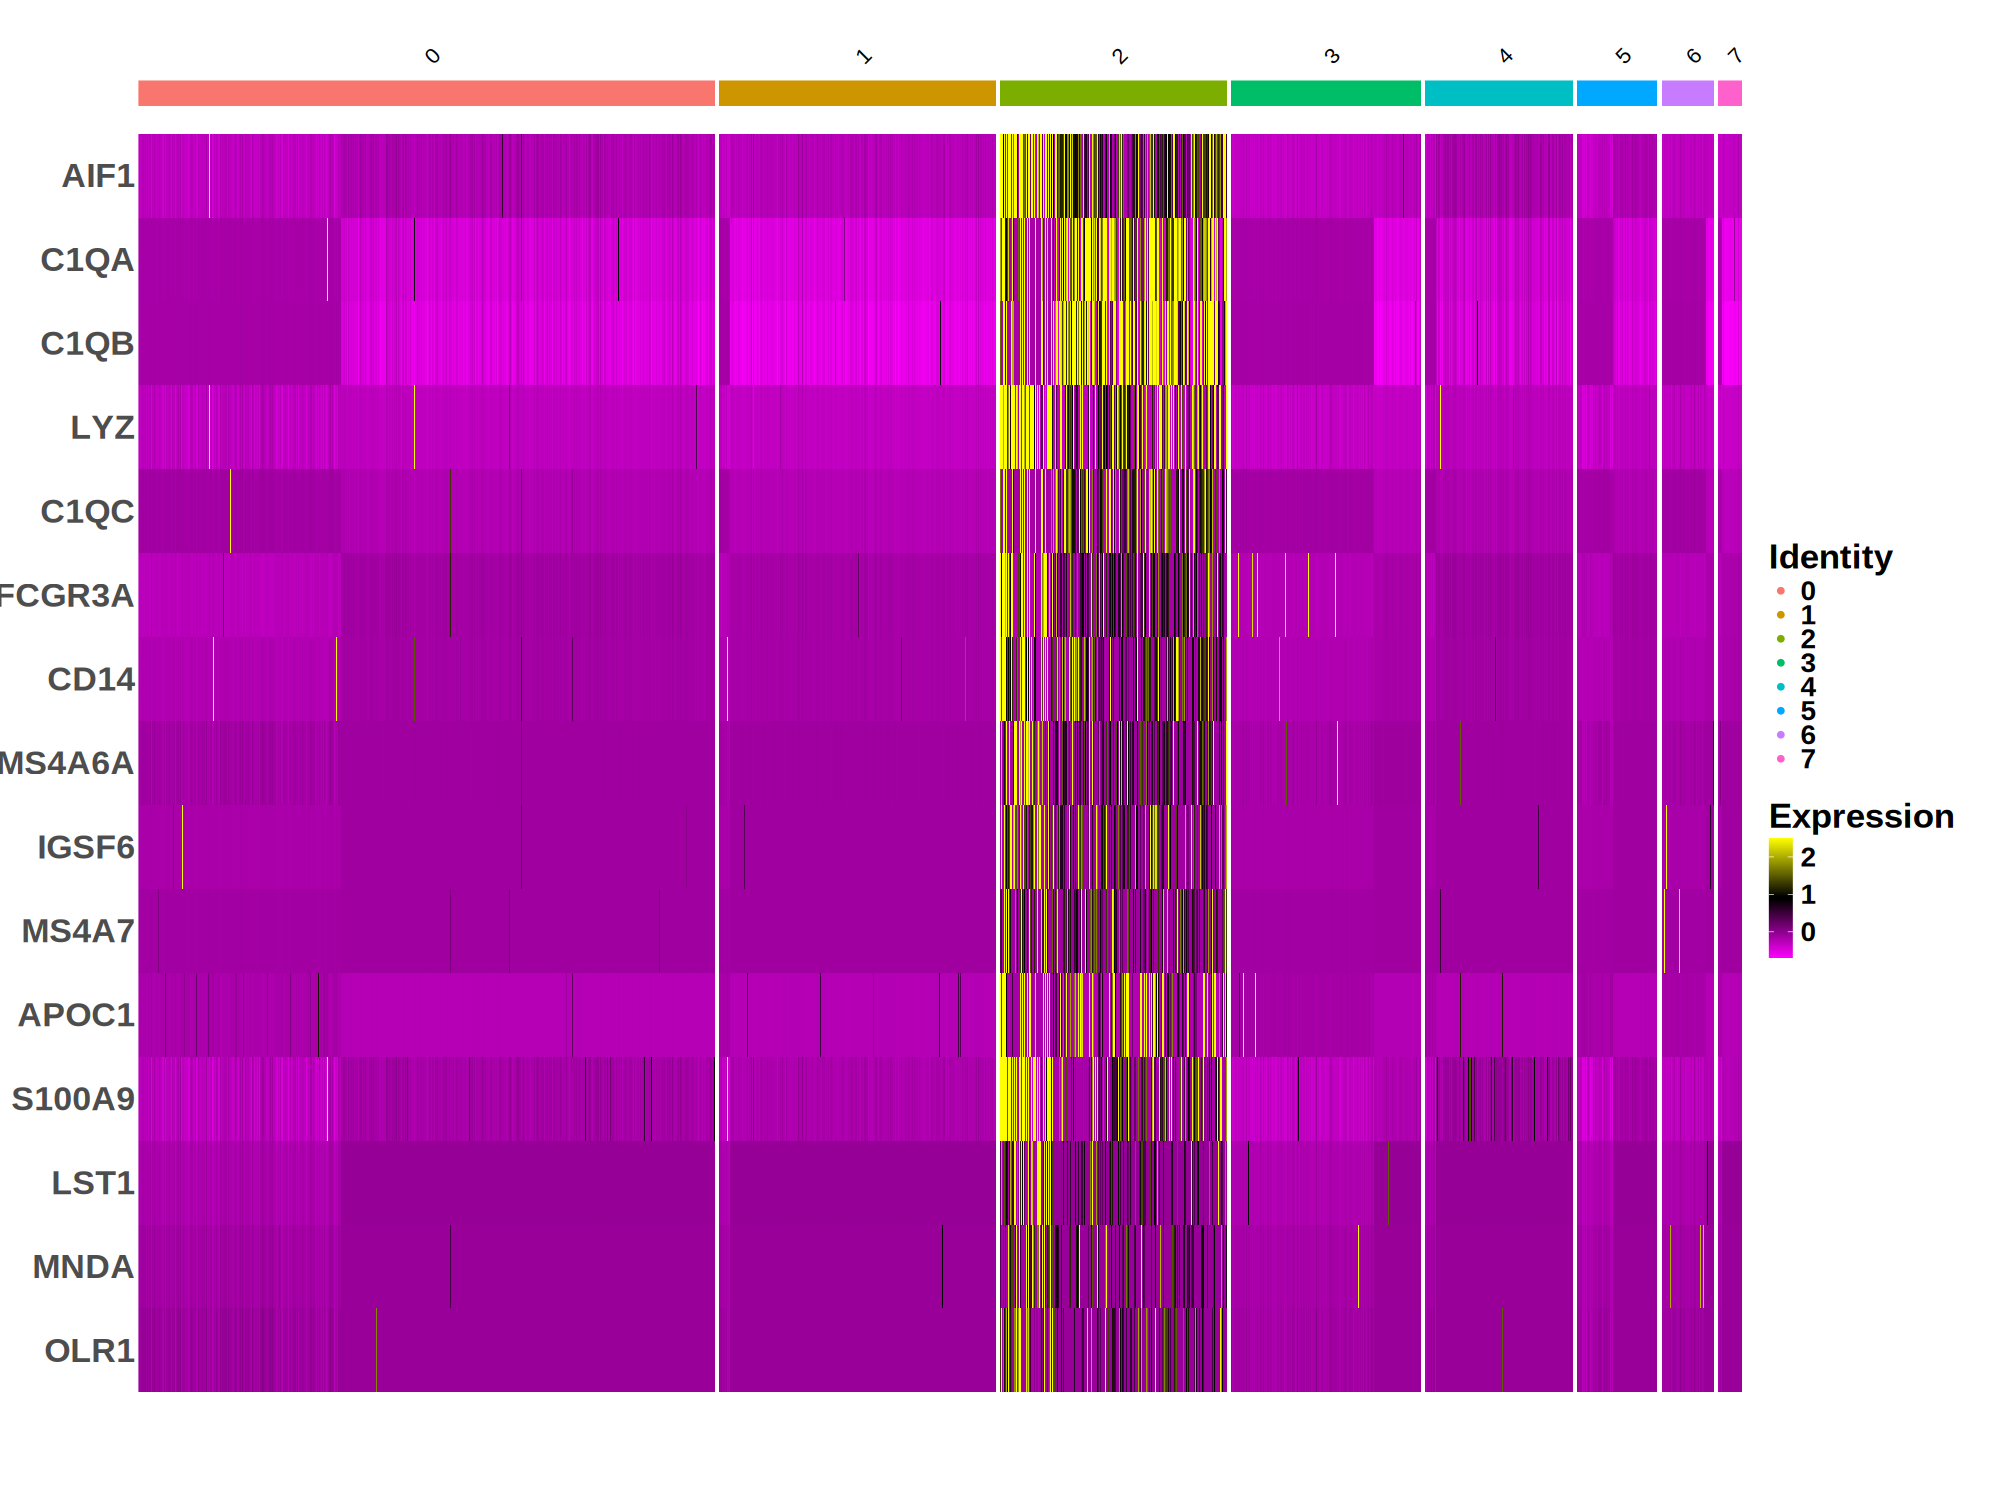

In [12]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_2.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster2.markers <- obj40.markers %>% filter(cluster==2) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), slot = "scale.data") & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

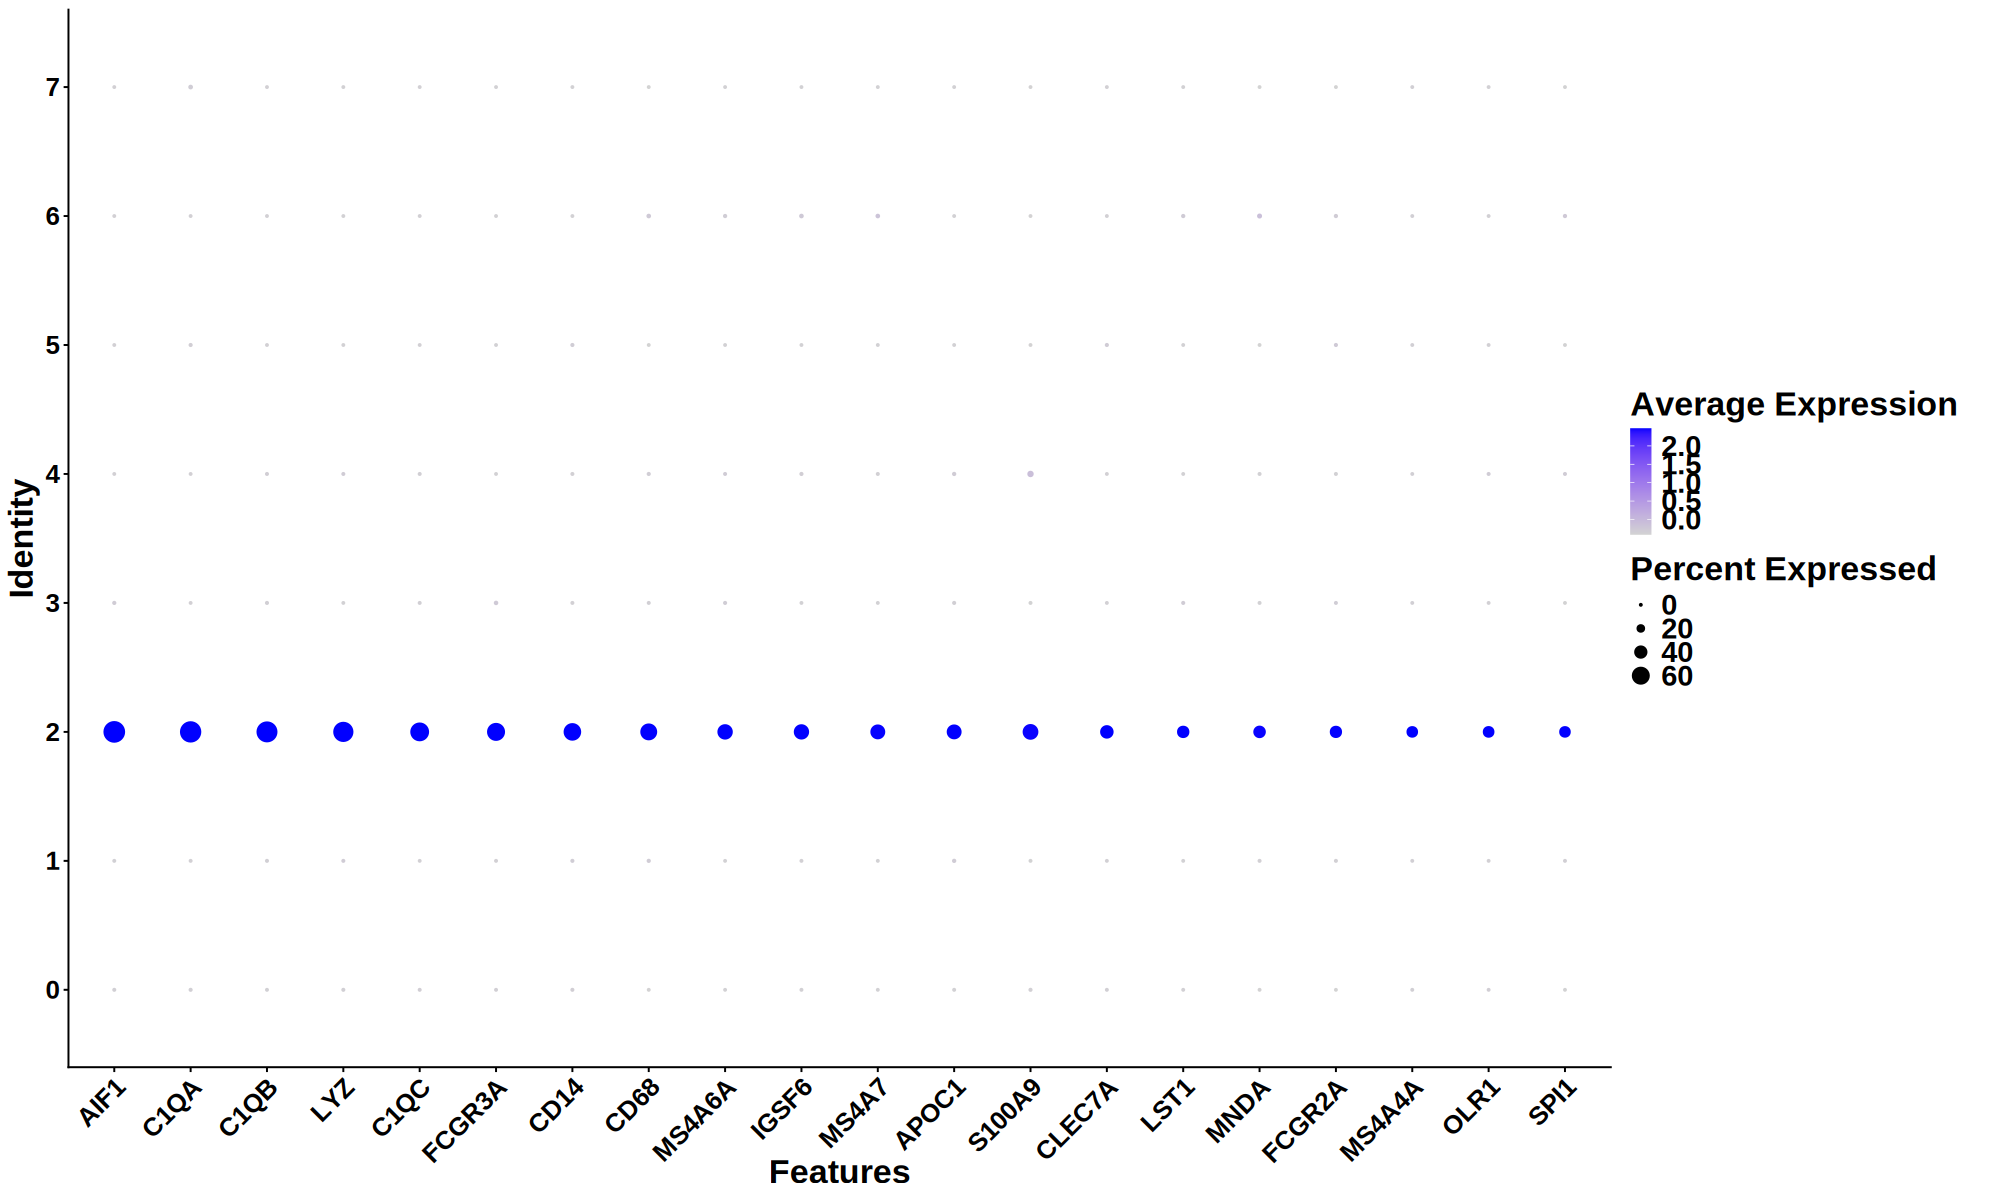

In [13]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_2
obj40.cluster2.markers$gene %>% write.table("obj40.cluster2.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster2.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

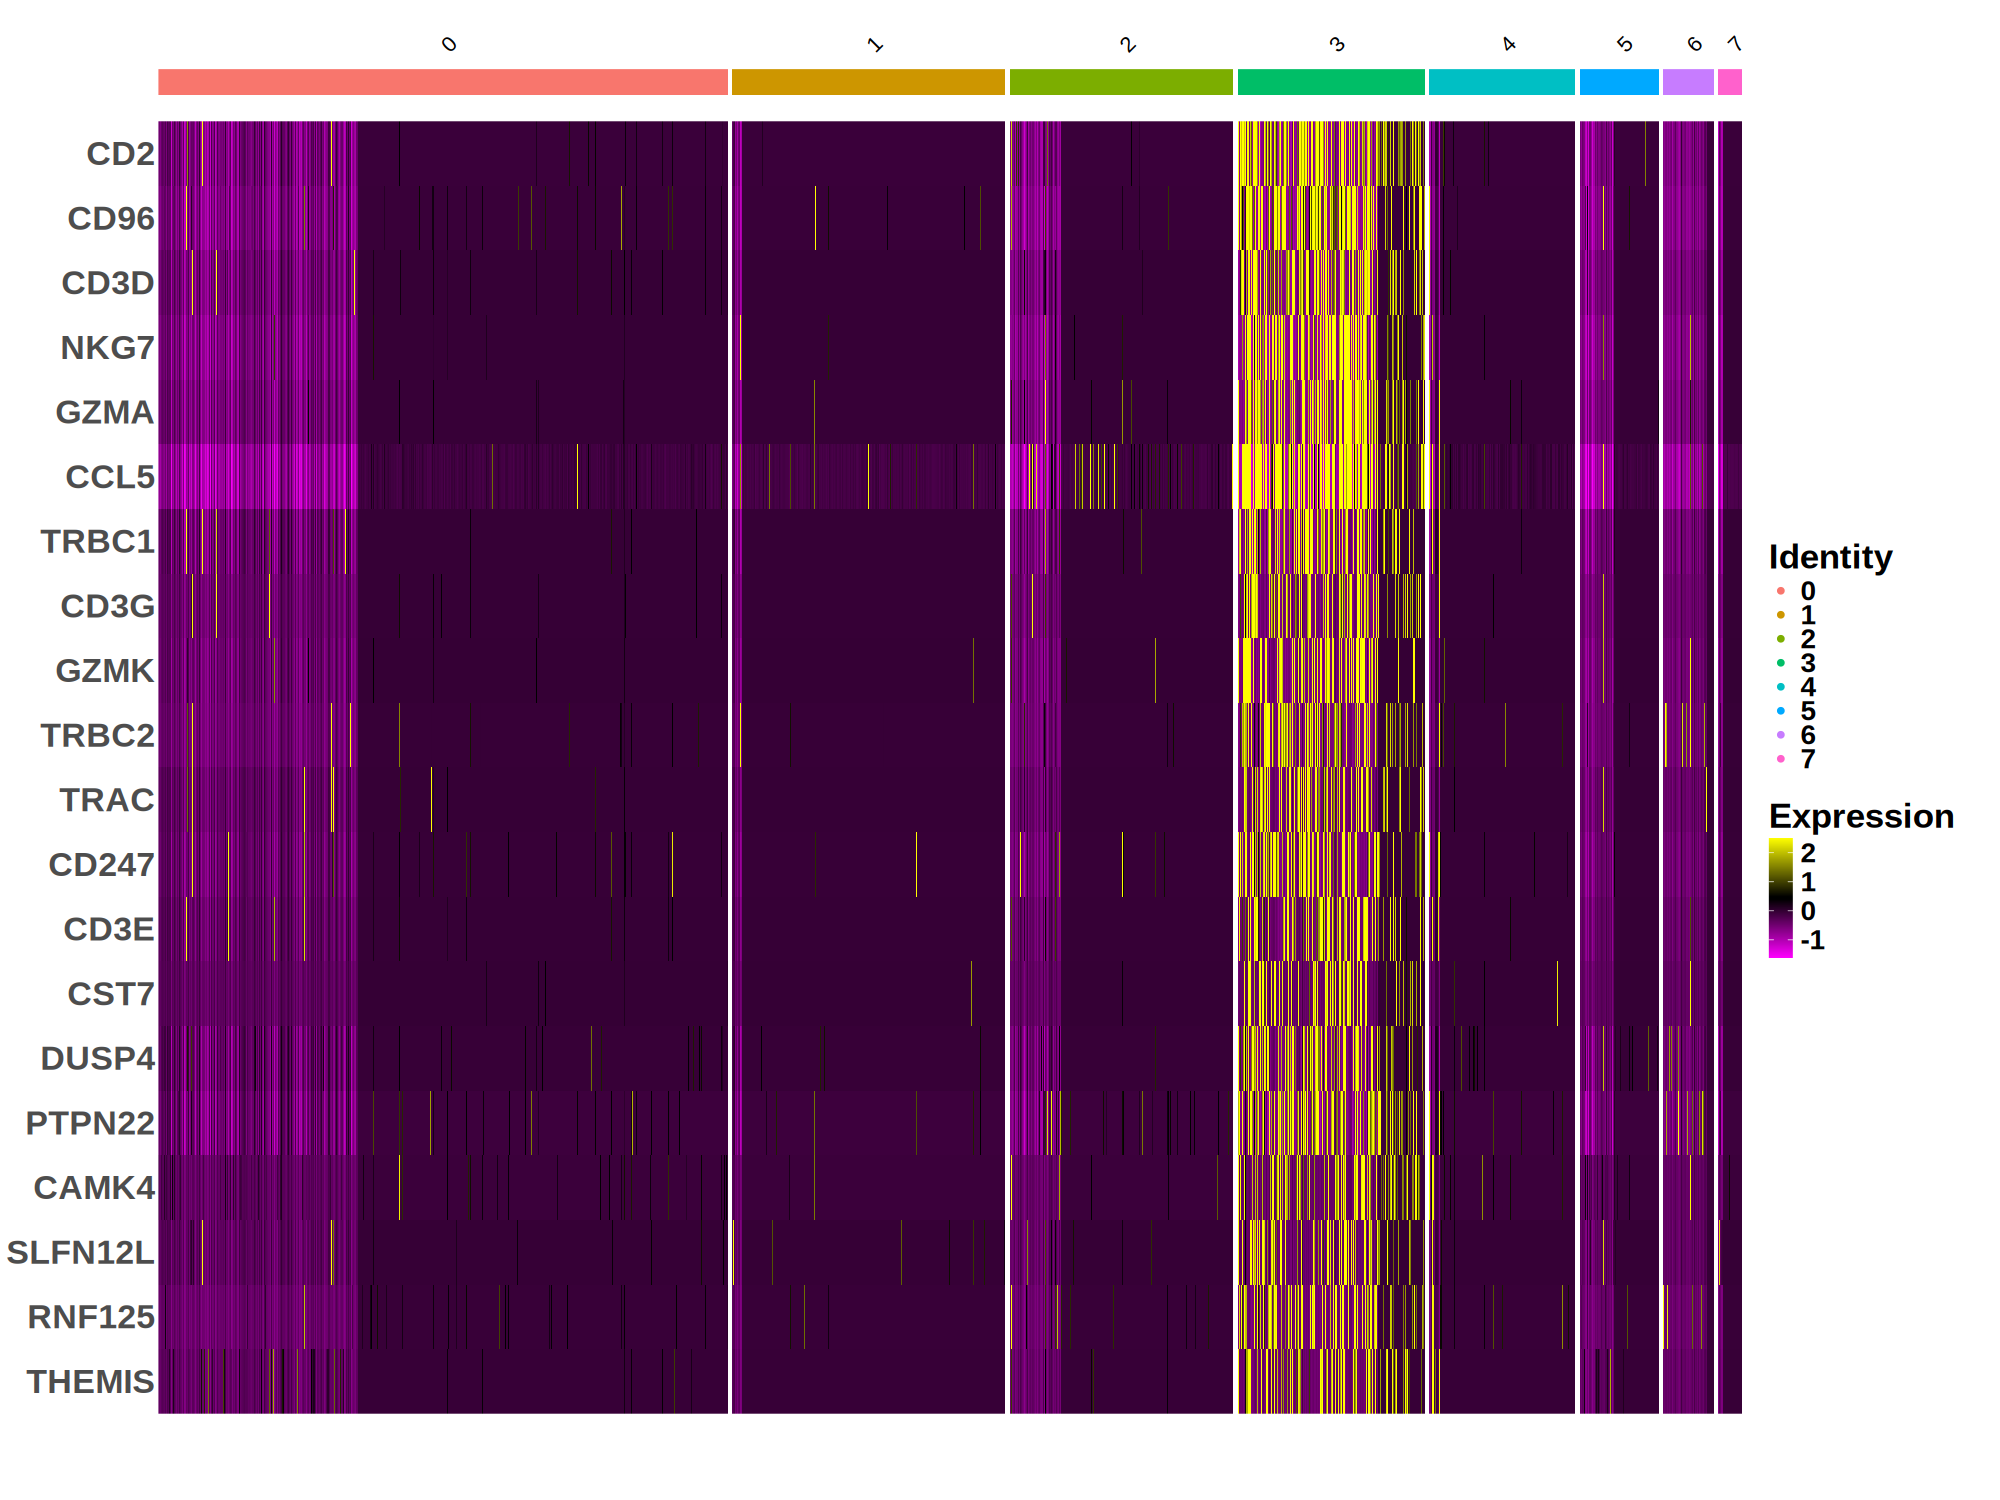

In [14]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_3.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster3.markers <- obj40.markers %>% filter(cluster==3) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster3.markers$gene)), slot = "scale.data")  & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

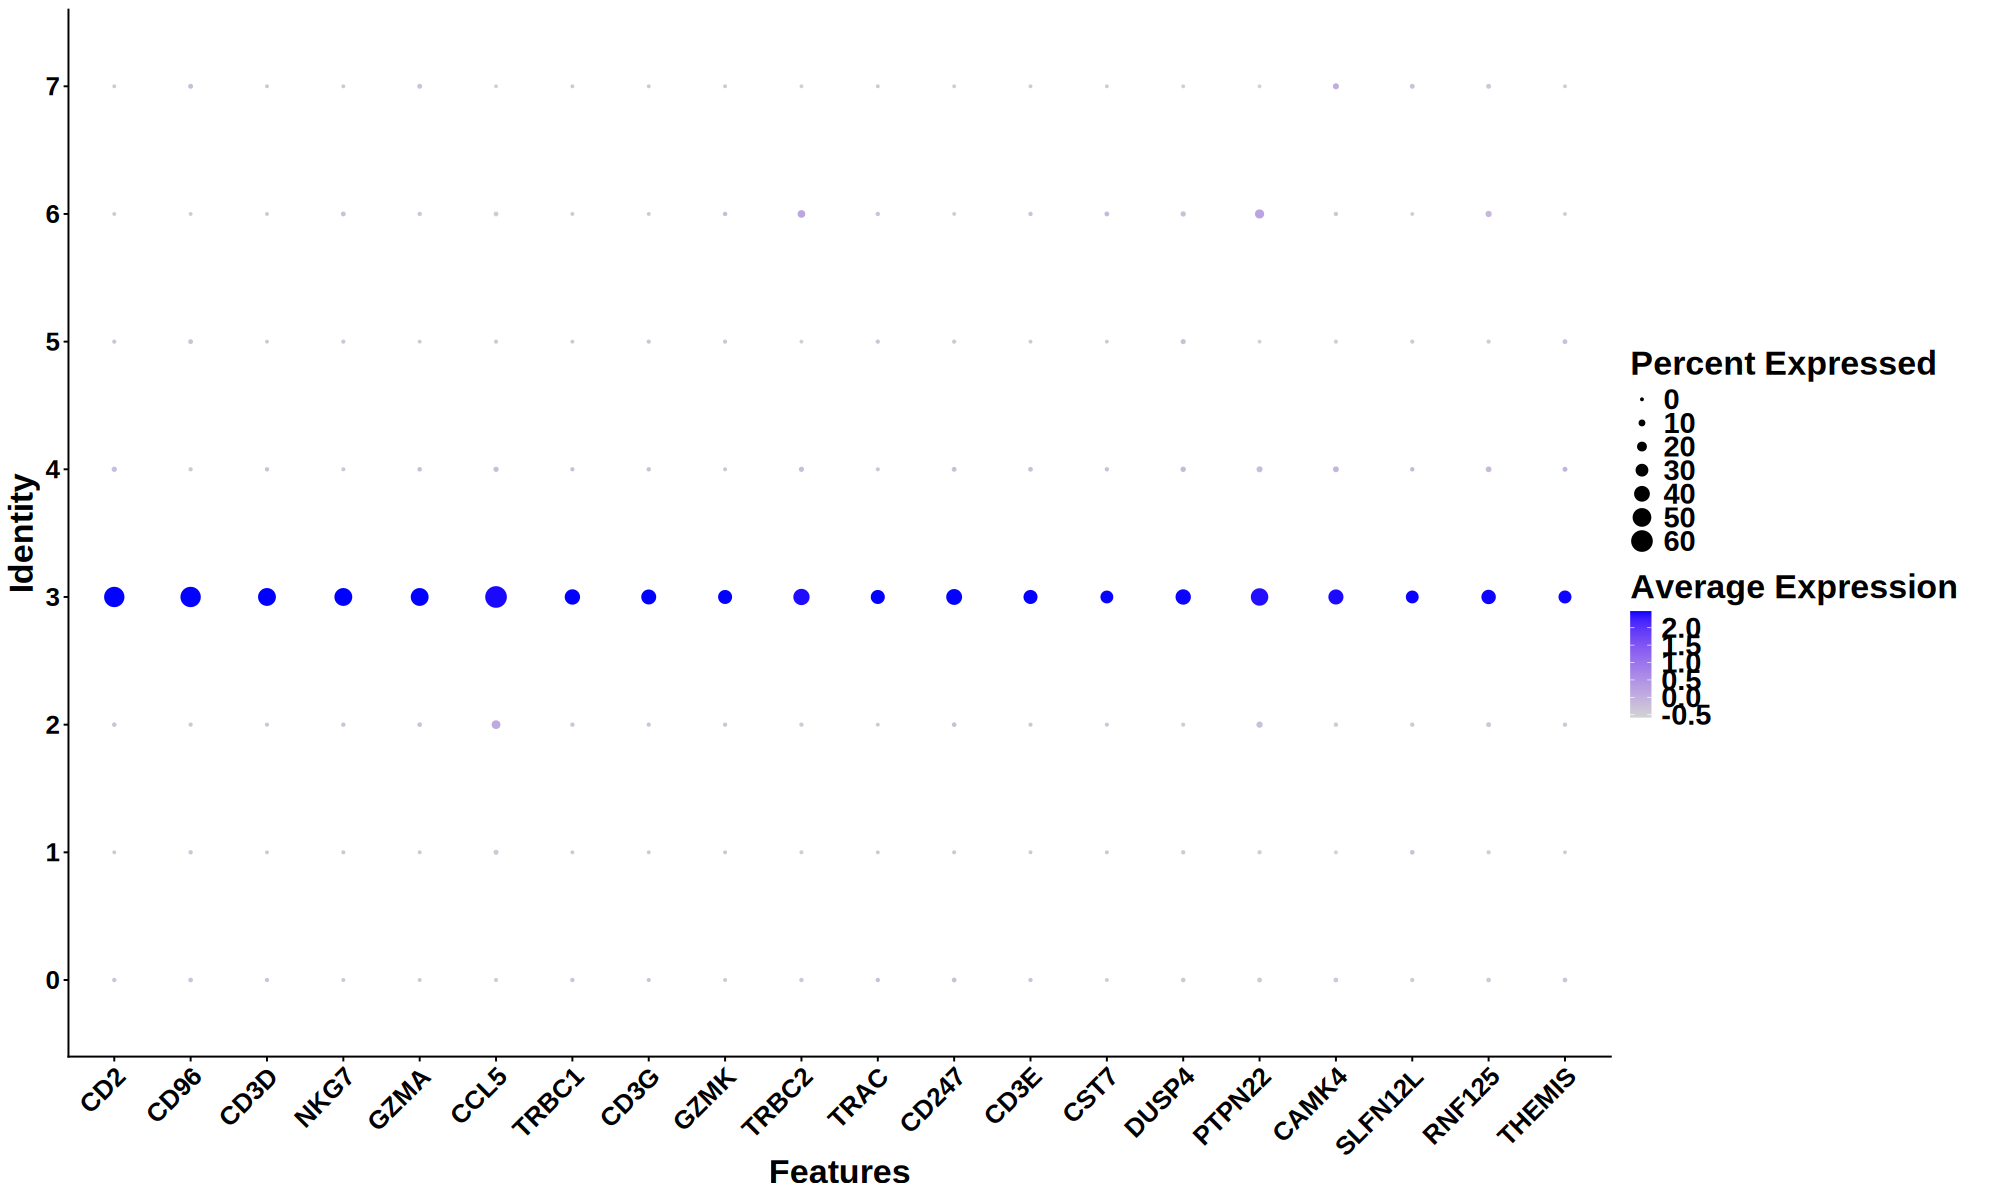

In [15]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_3
obj40.cluster3.markers$gene %>% write.table("obj40.cluster3.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster3.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PTPN13, TDRP, CYB5A, NFIA, PPP1R13B, ERRFI1, EPB41L5, GCNT2, CDH1, MYO6, MAGI3, MECOM, LMO7, NEDD4L, SFTPB”


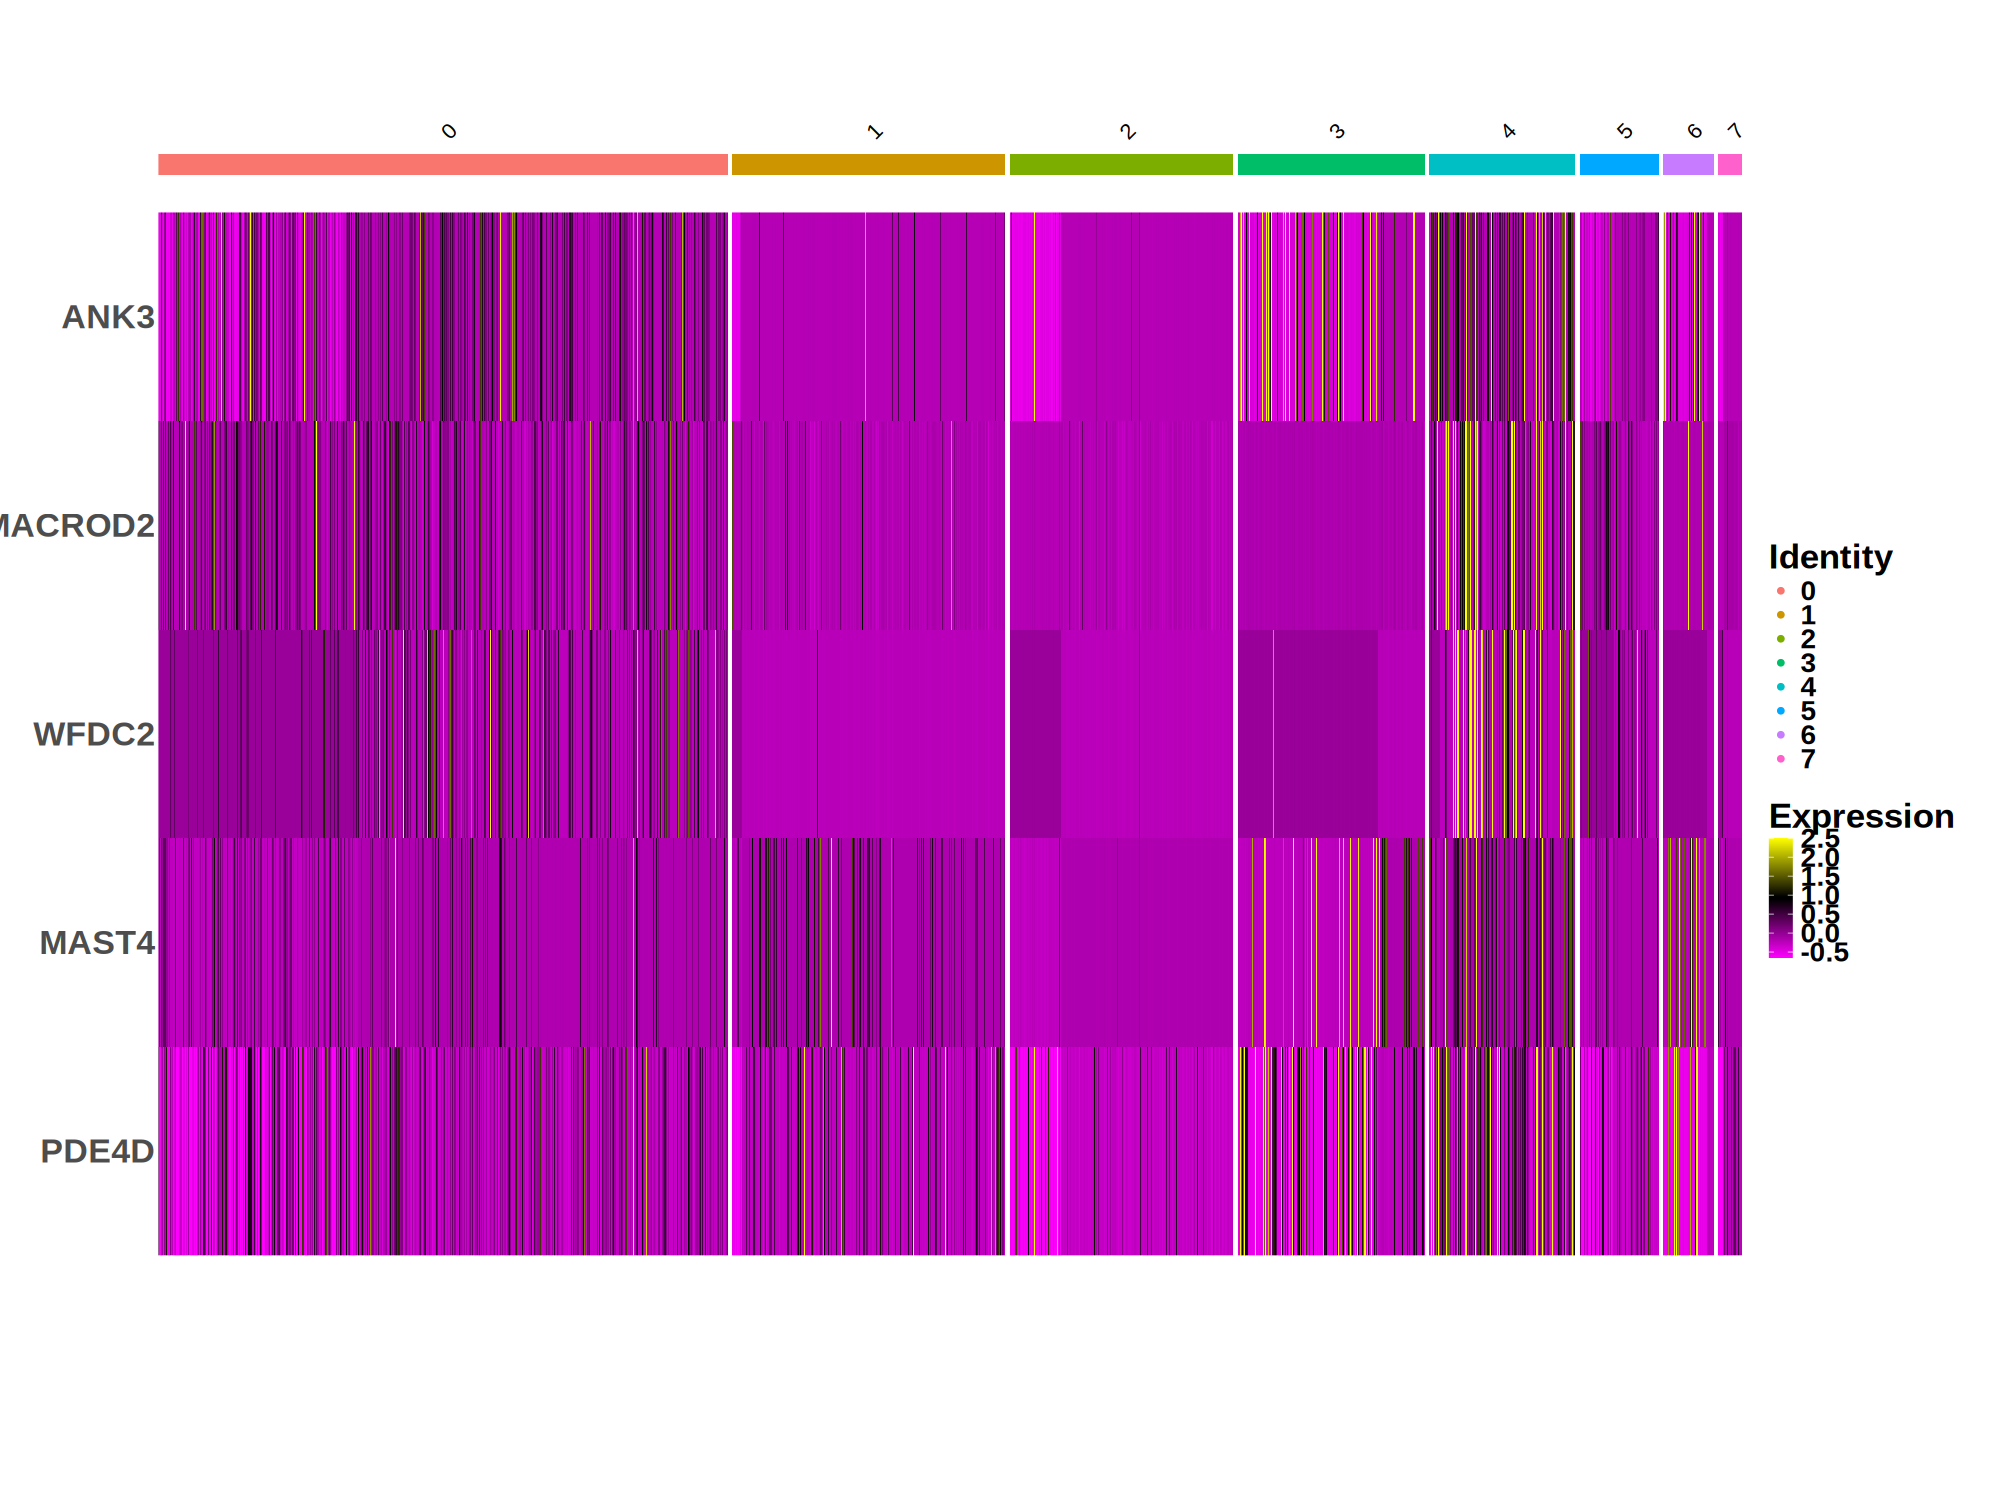

In [16]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_4.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster4.markers <- obj40.markers %>% filter(cluster==4) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), slot = "scale.data")  & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

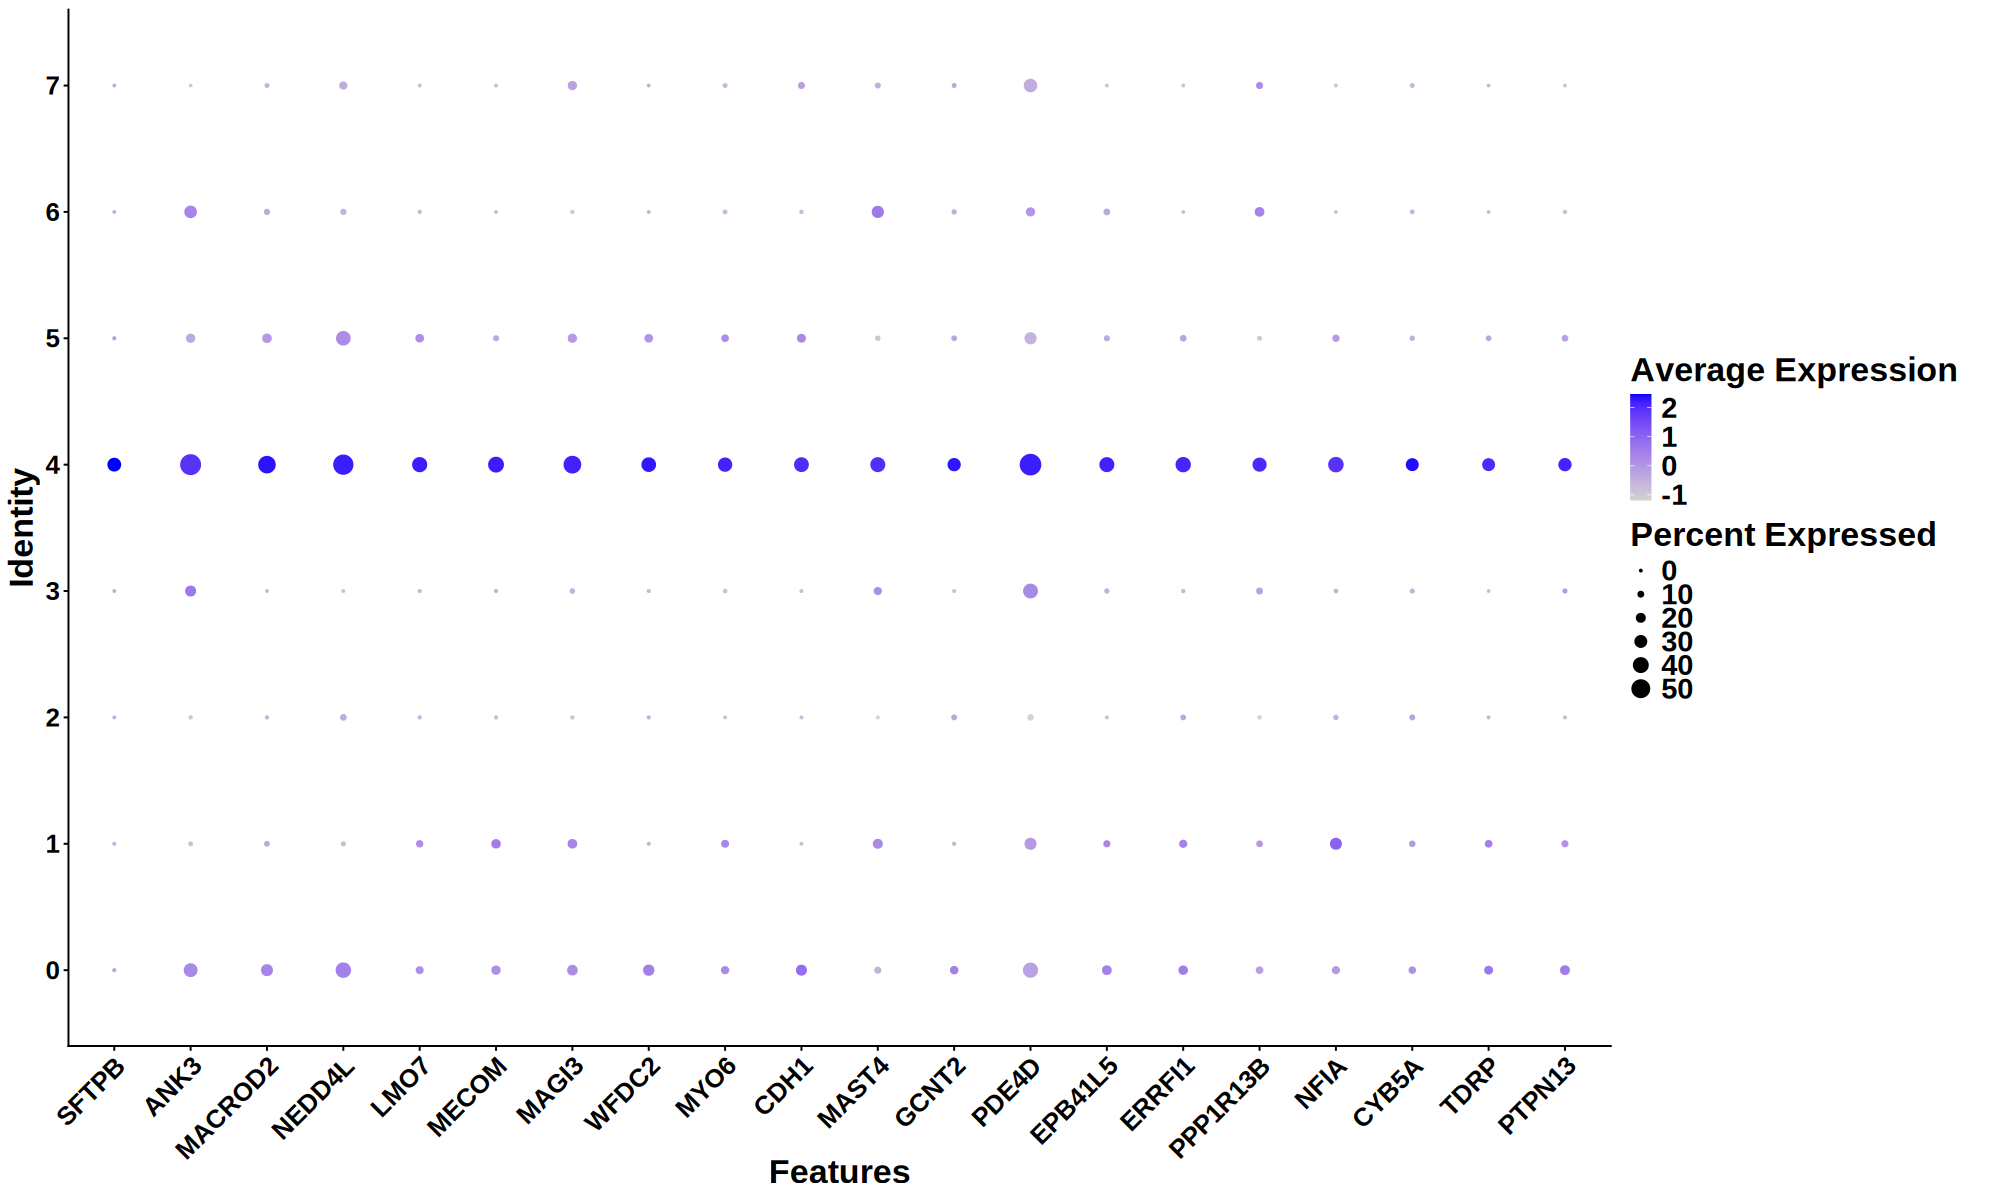

In [17]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_4
obj40.cluster4.markers$gene %>% write.table("obj40.cluster4.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster4.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: H1-1, TMEM106C, ECT2, CCNB1, PTTG1, CENPE, MAD2L1, NUSAP1, CKS1B, ASPM, GTSE1, MKI67, UBE2C, TPX2”


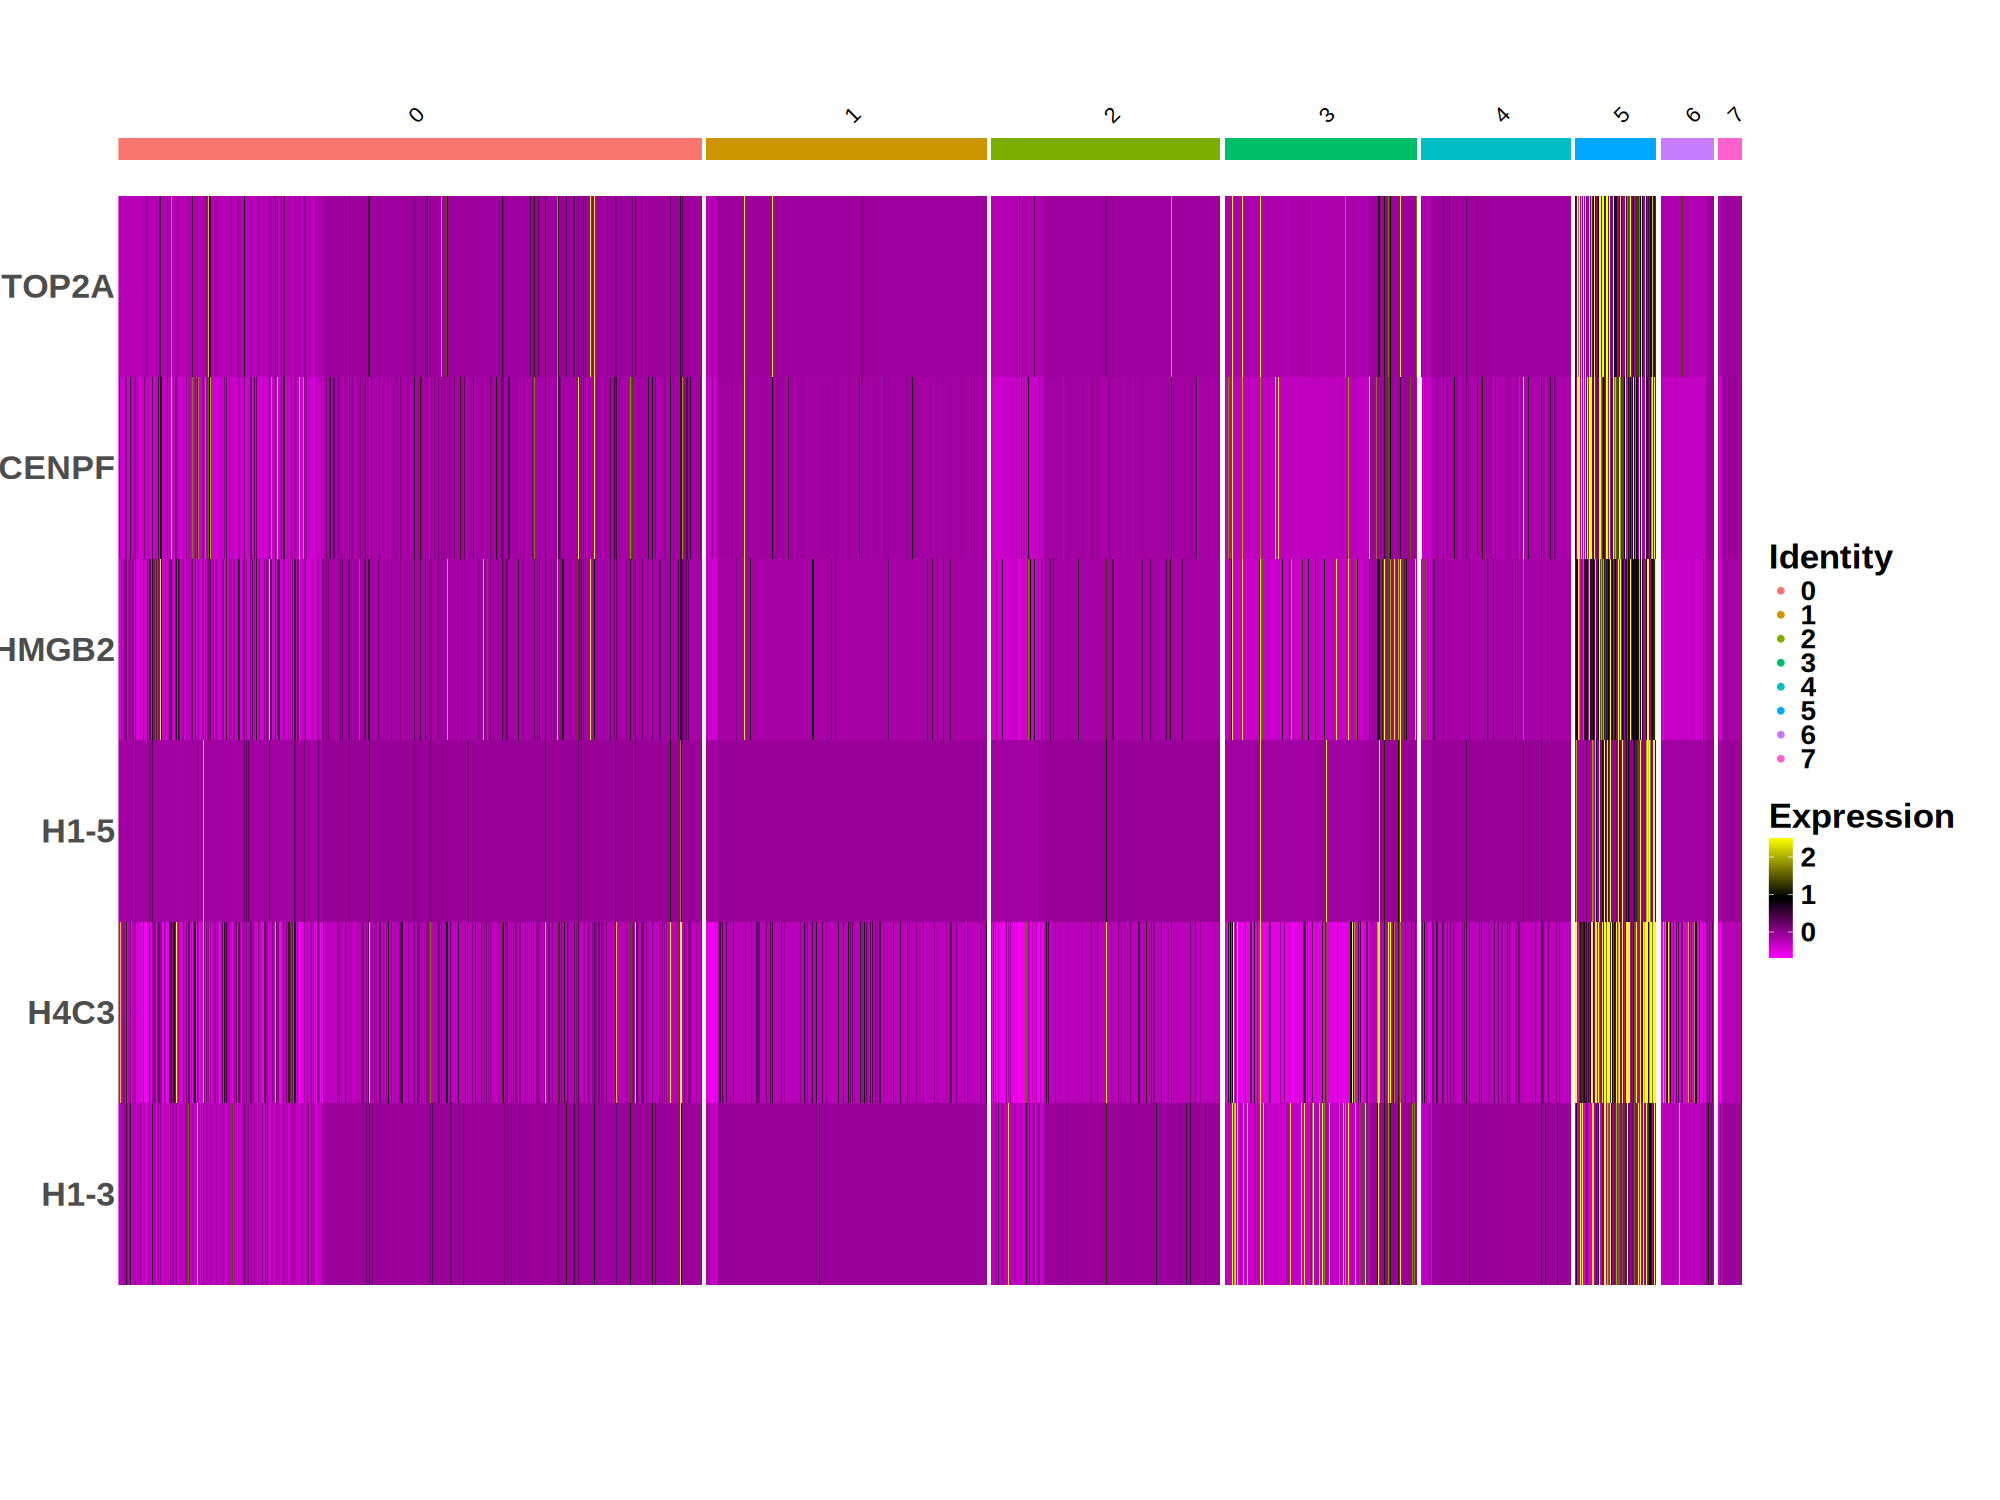

In [18]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_5.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster5.markers <- obj40.markers %>% filter(cluster==5) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), slot = "scale.data")  & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

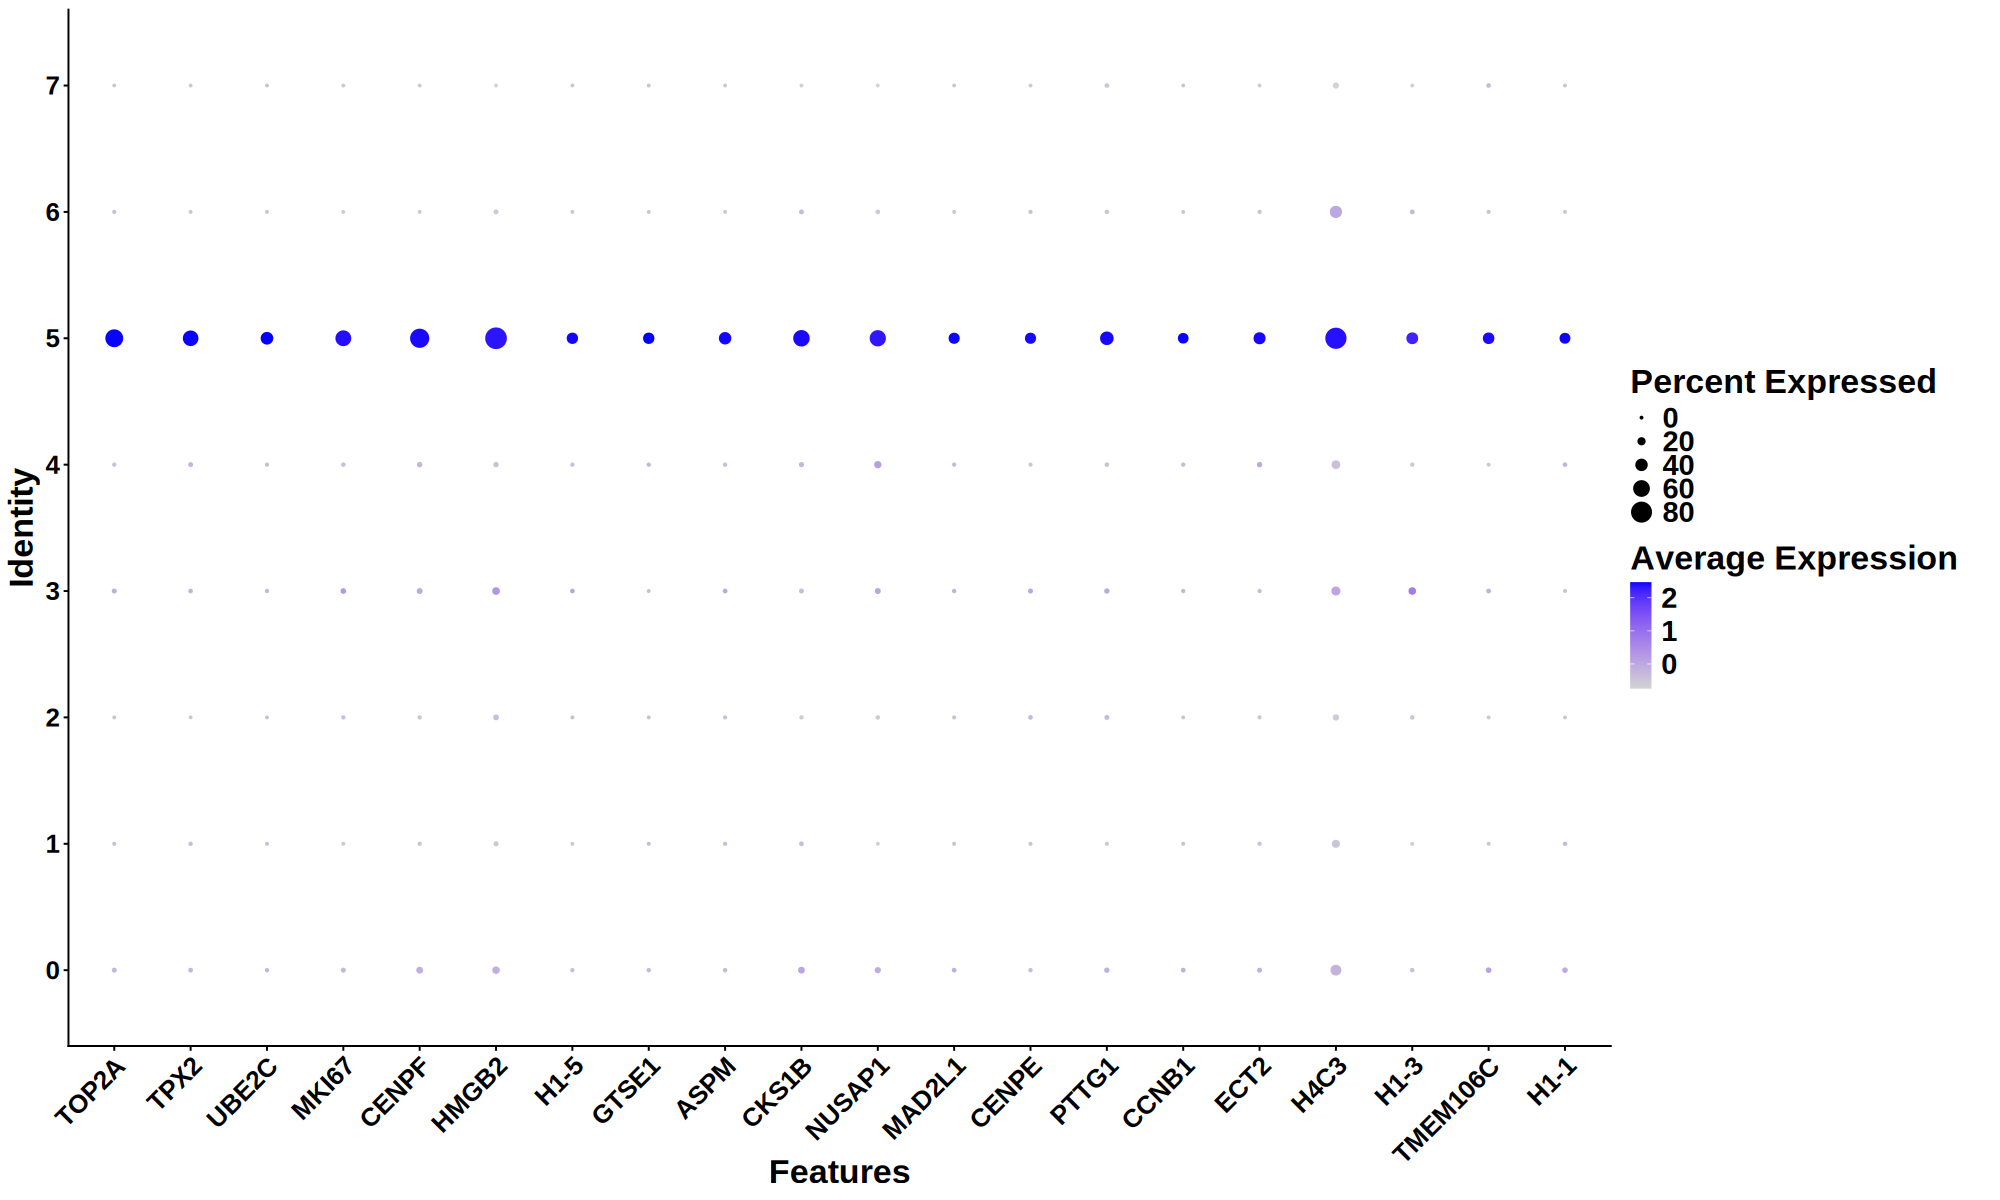

In [19]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_5
obj40.cluster5.markers$gene %>% write.table("obj40.cluster5.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster5.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TNFRSF13C, CD79B, PAX5, MS4A1”


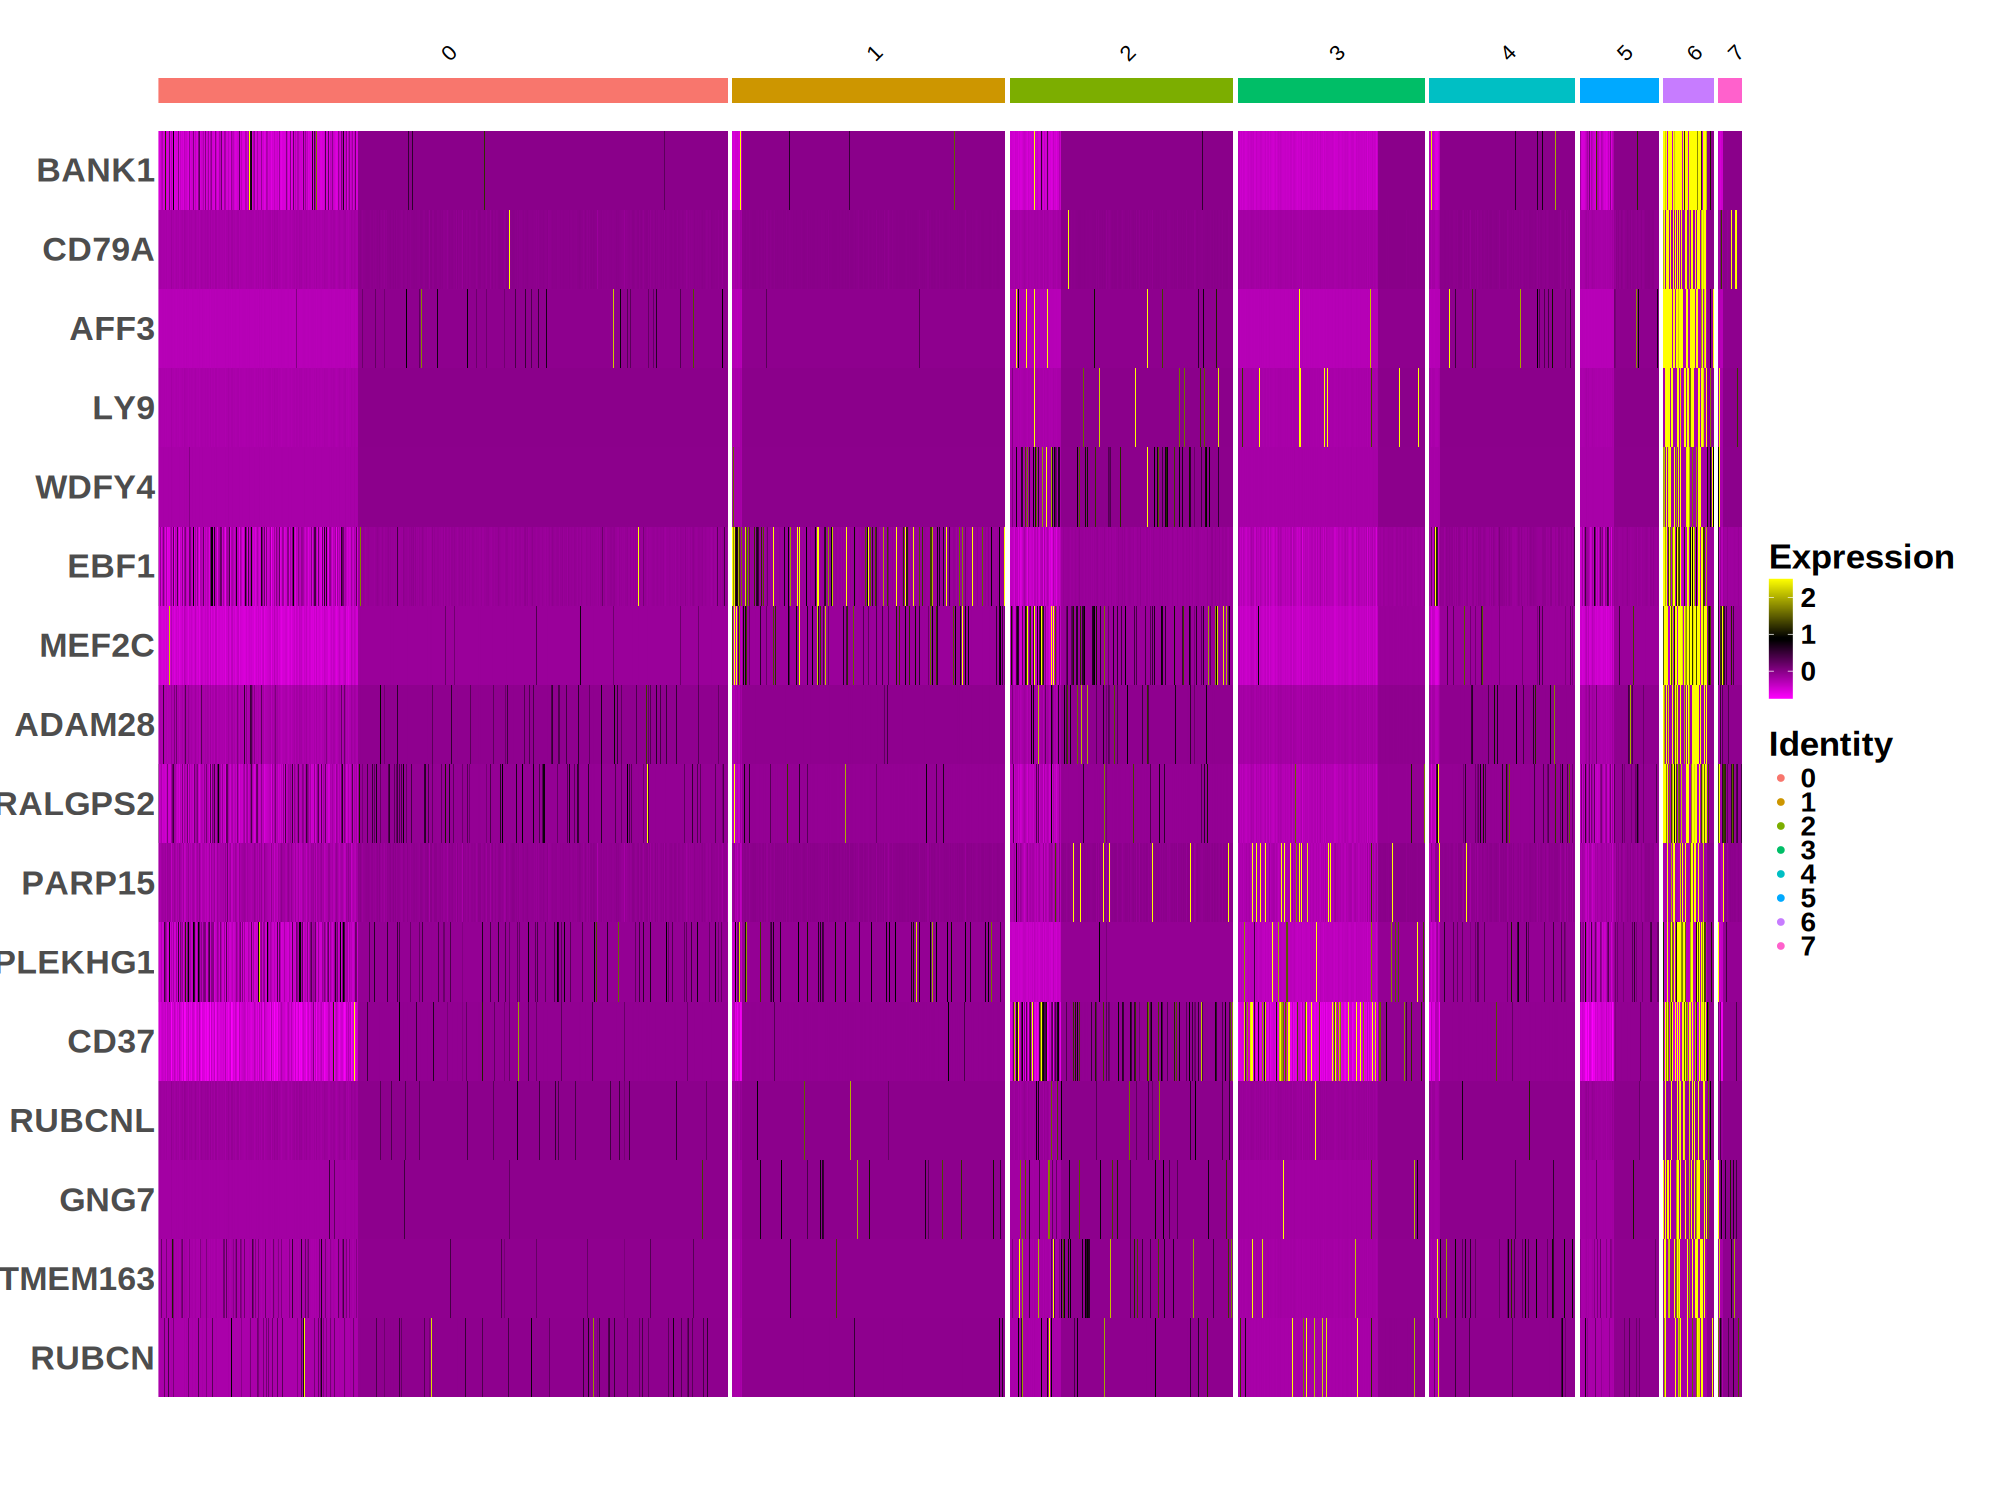

In [20]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_6.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster6.markers <- obj40.markers %>% filter(cluster==6) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), slot = "scale.data")  & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

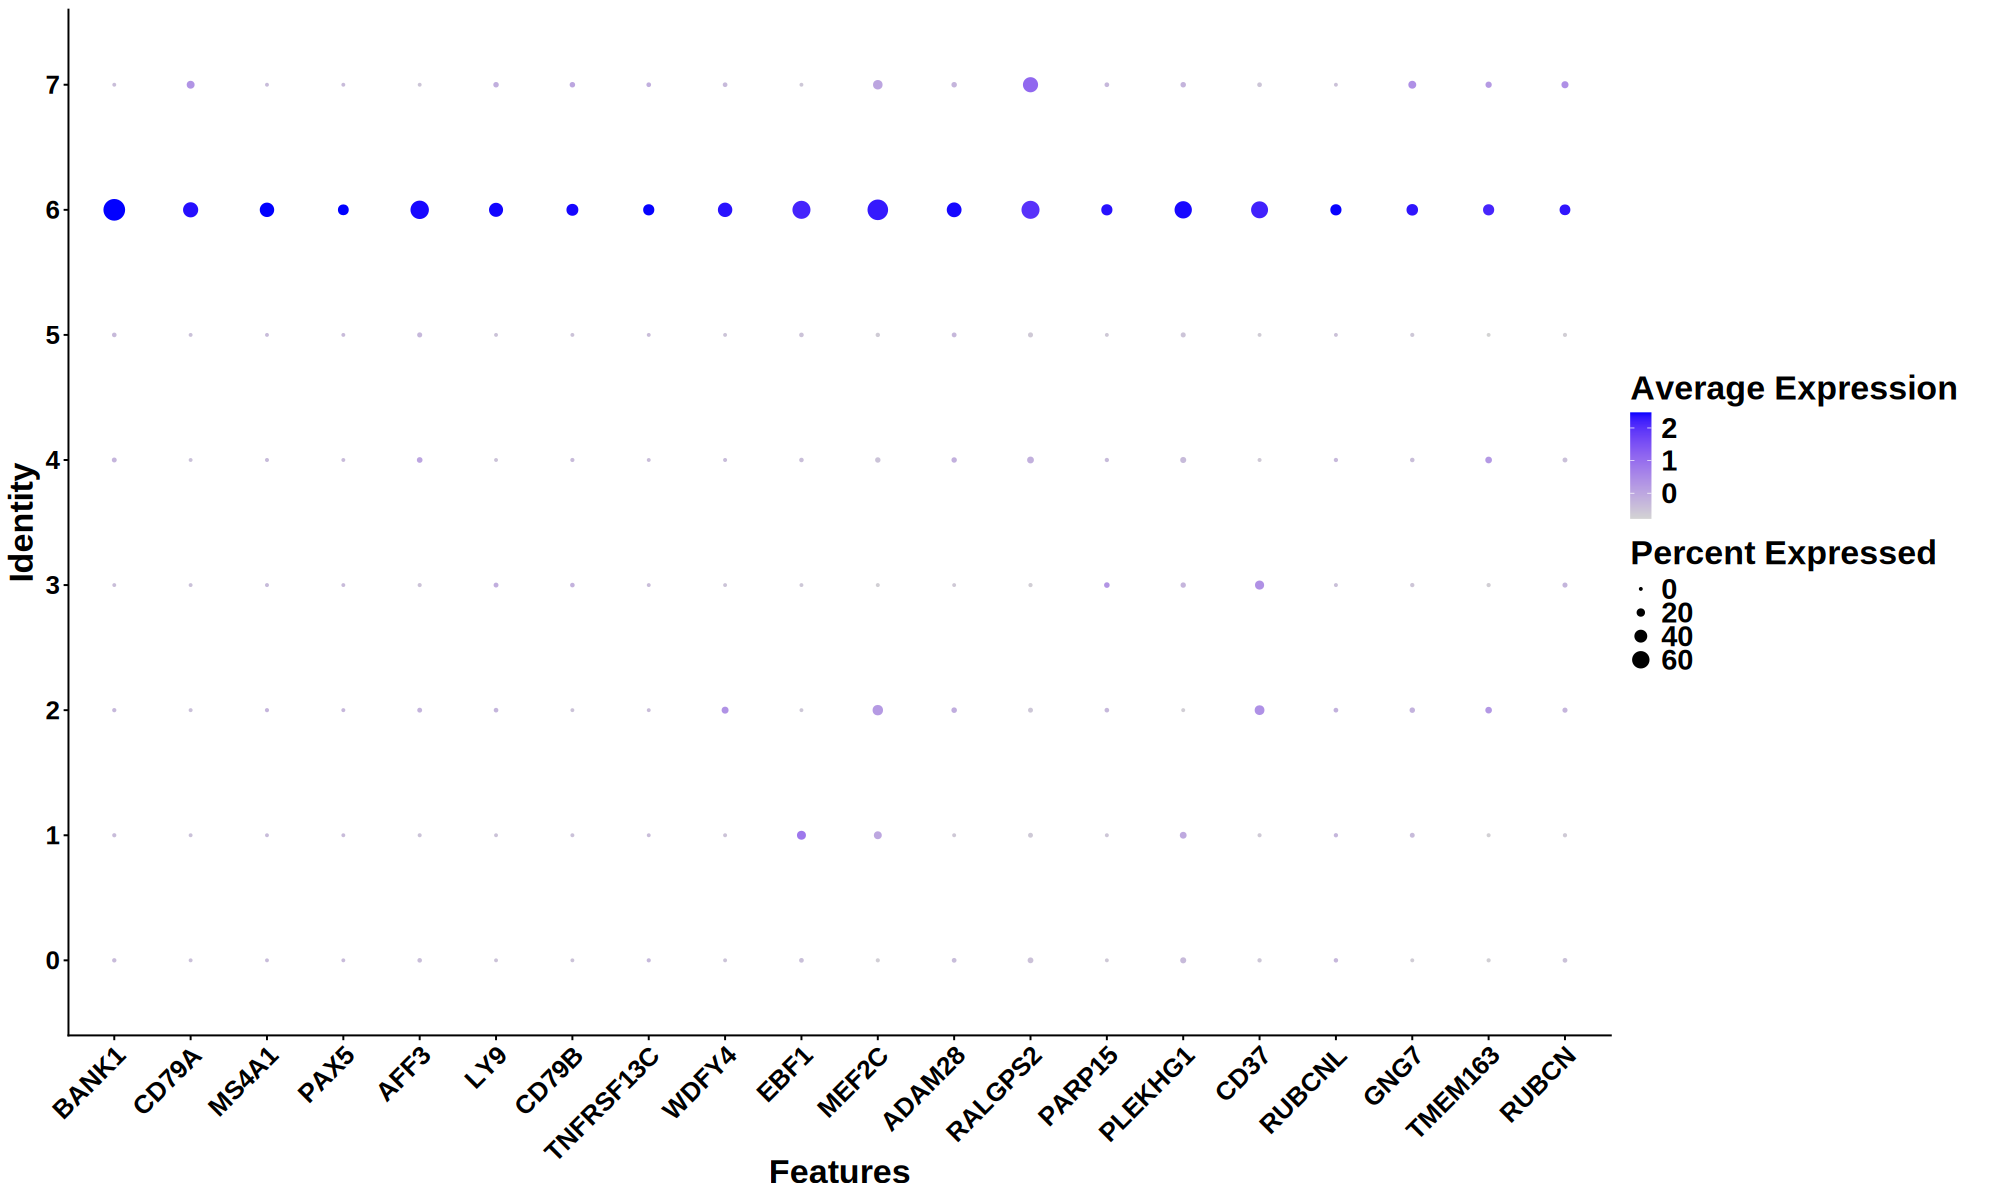

In [21]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_6
obj40.cluster6.markers$gene %>% write.table("obj40.cluster6.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster6.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TMEM107, BCAR3, SEC11C, TXNDC5, FKBP11, ANKRD36BP2, FCRL5, IGHG2, IGHG3, IGHG4”


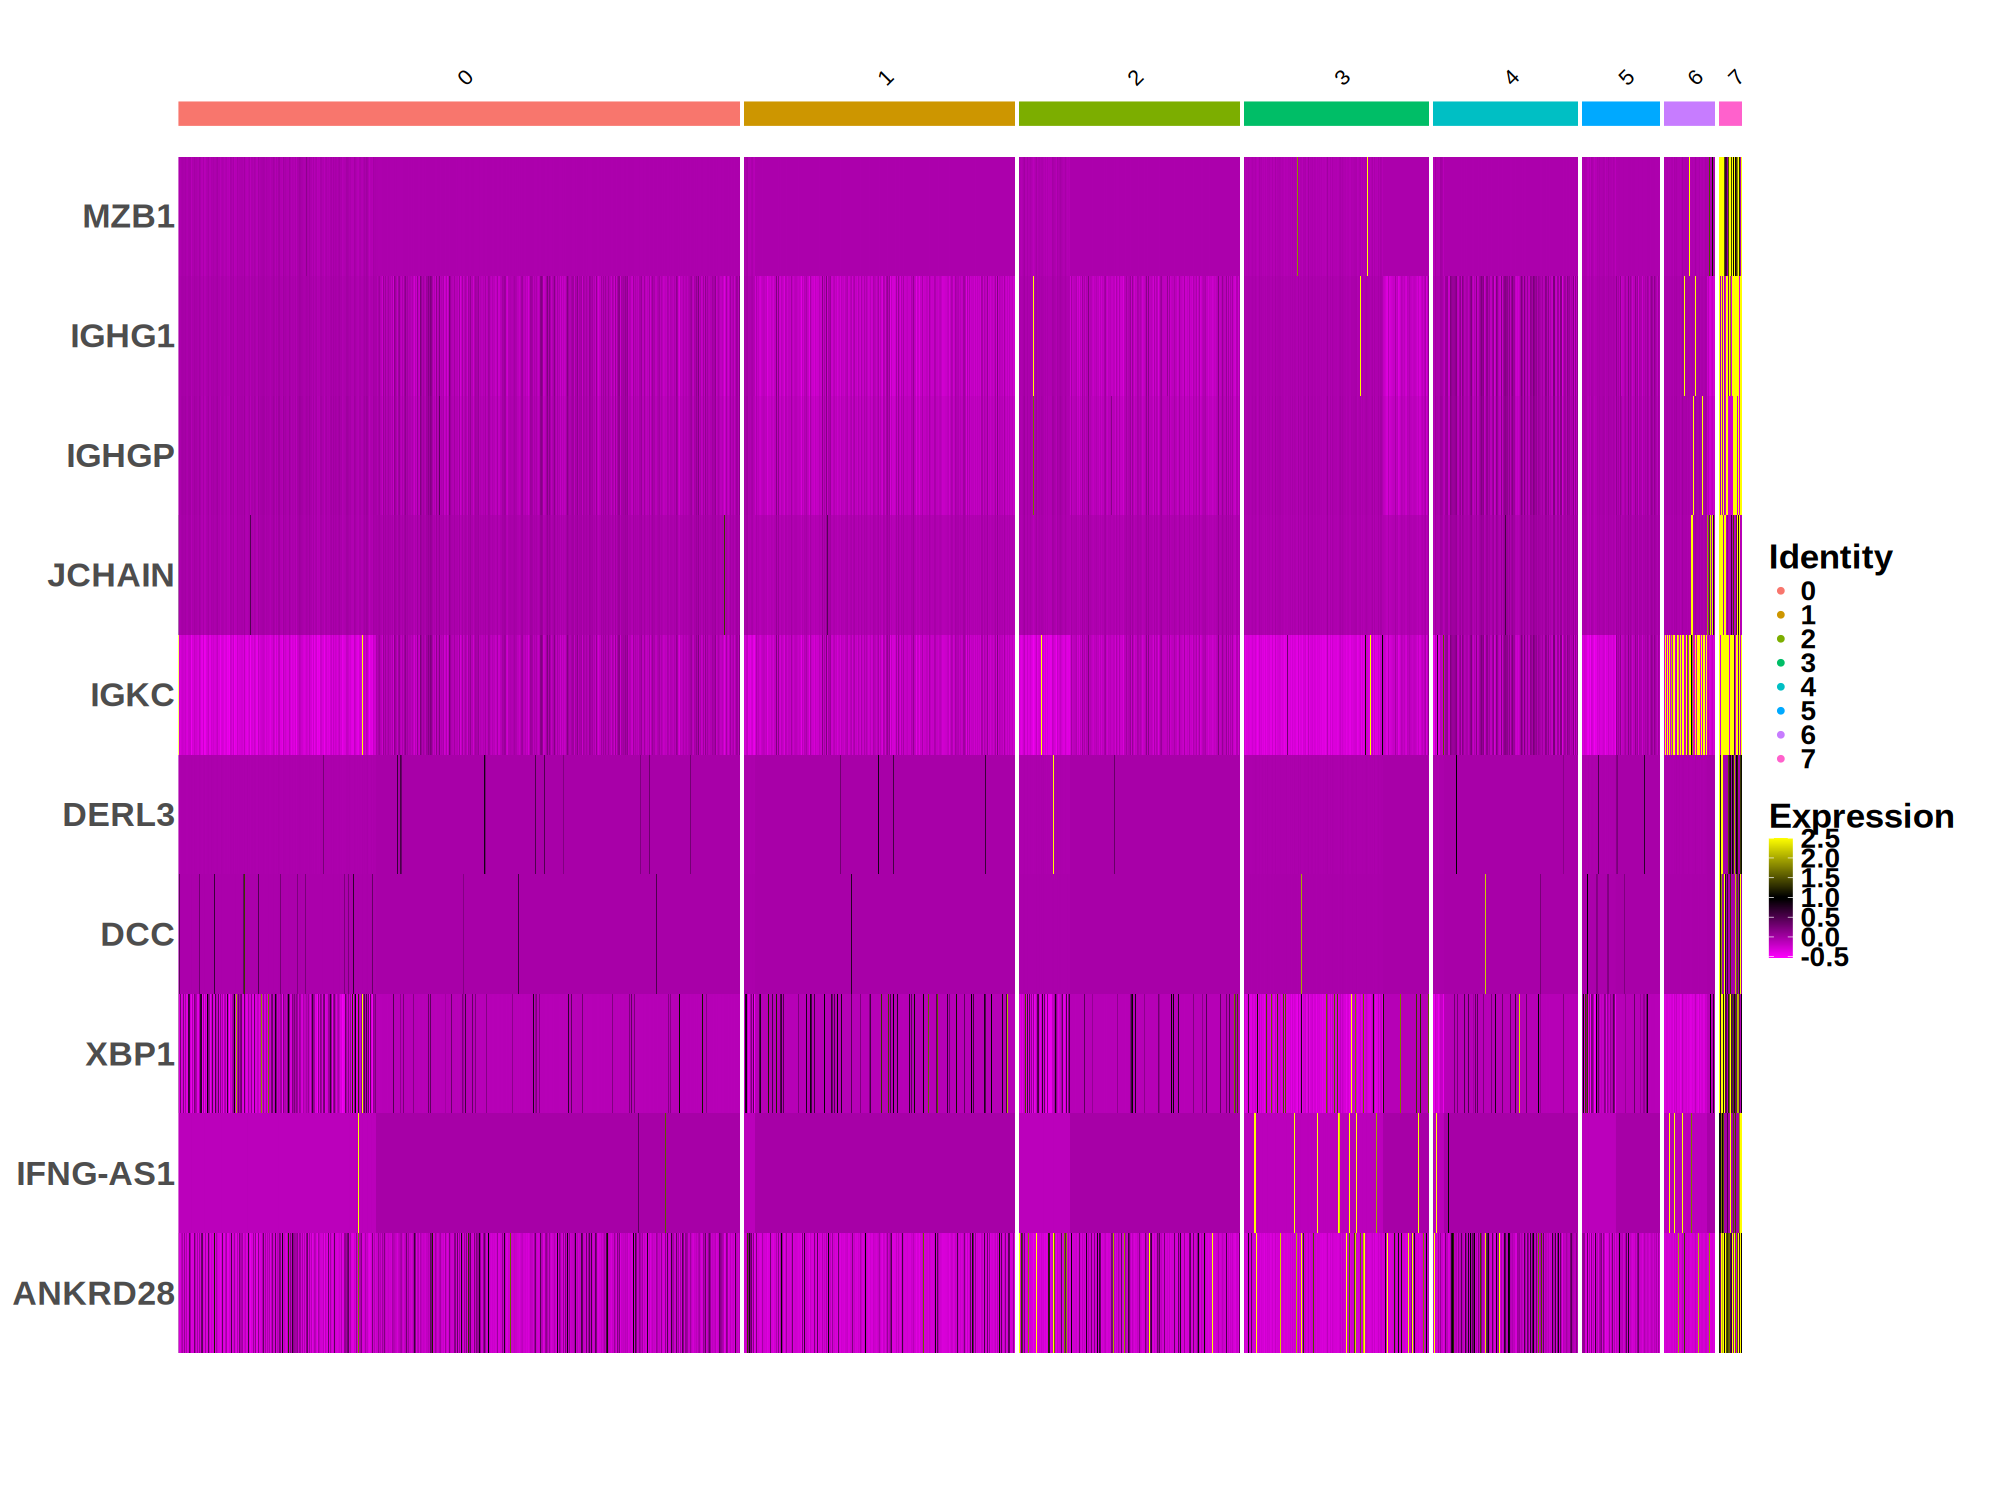

In [22]:
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 100)
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_7.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster7.markers <- obj40.markers %>% filter(cluster==7) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), slot = "scale.data")  & theme(axis.text.y = element_text(size = 24, face="bold"))  + theme(text=element_text(size=25, face="bold"))

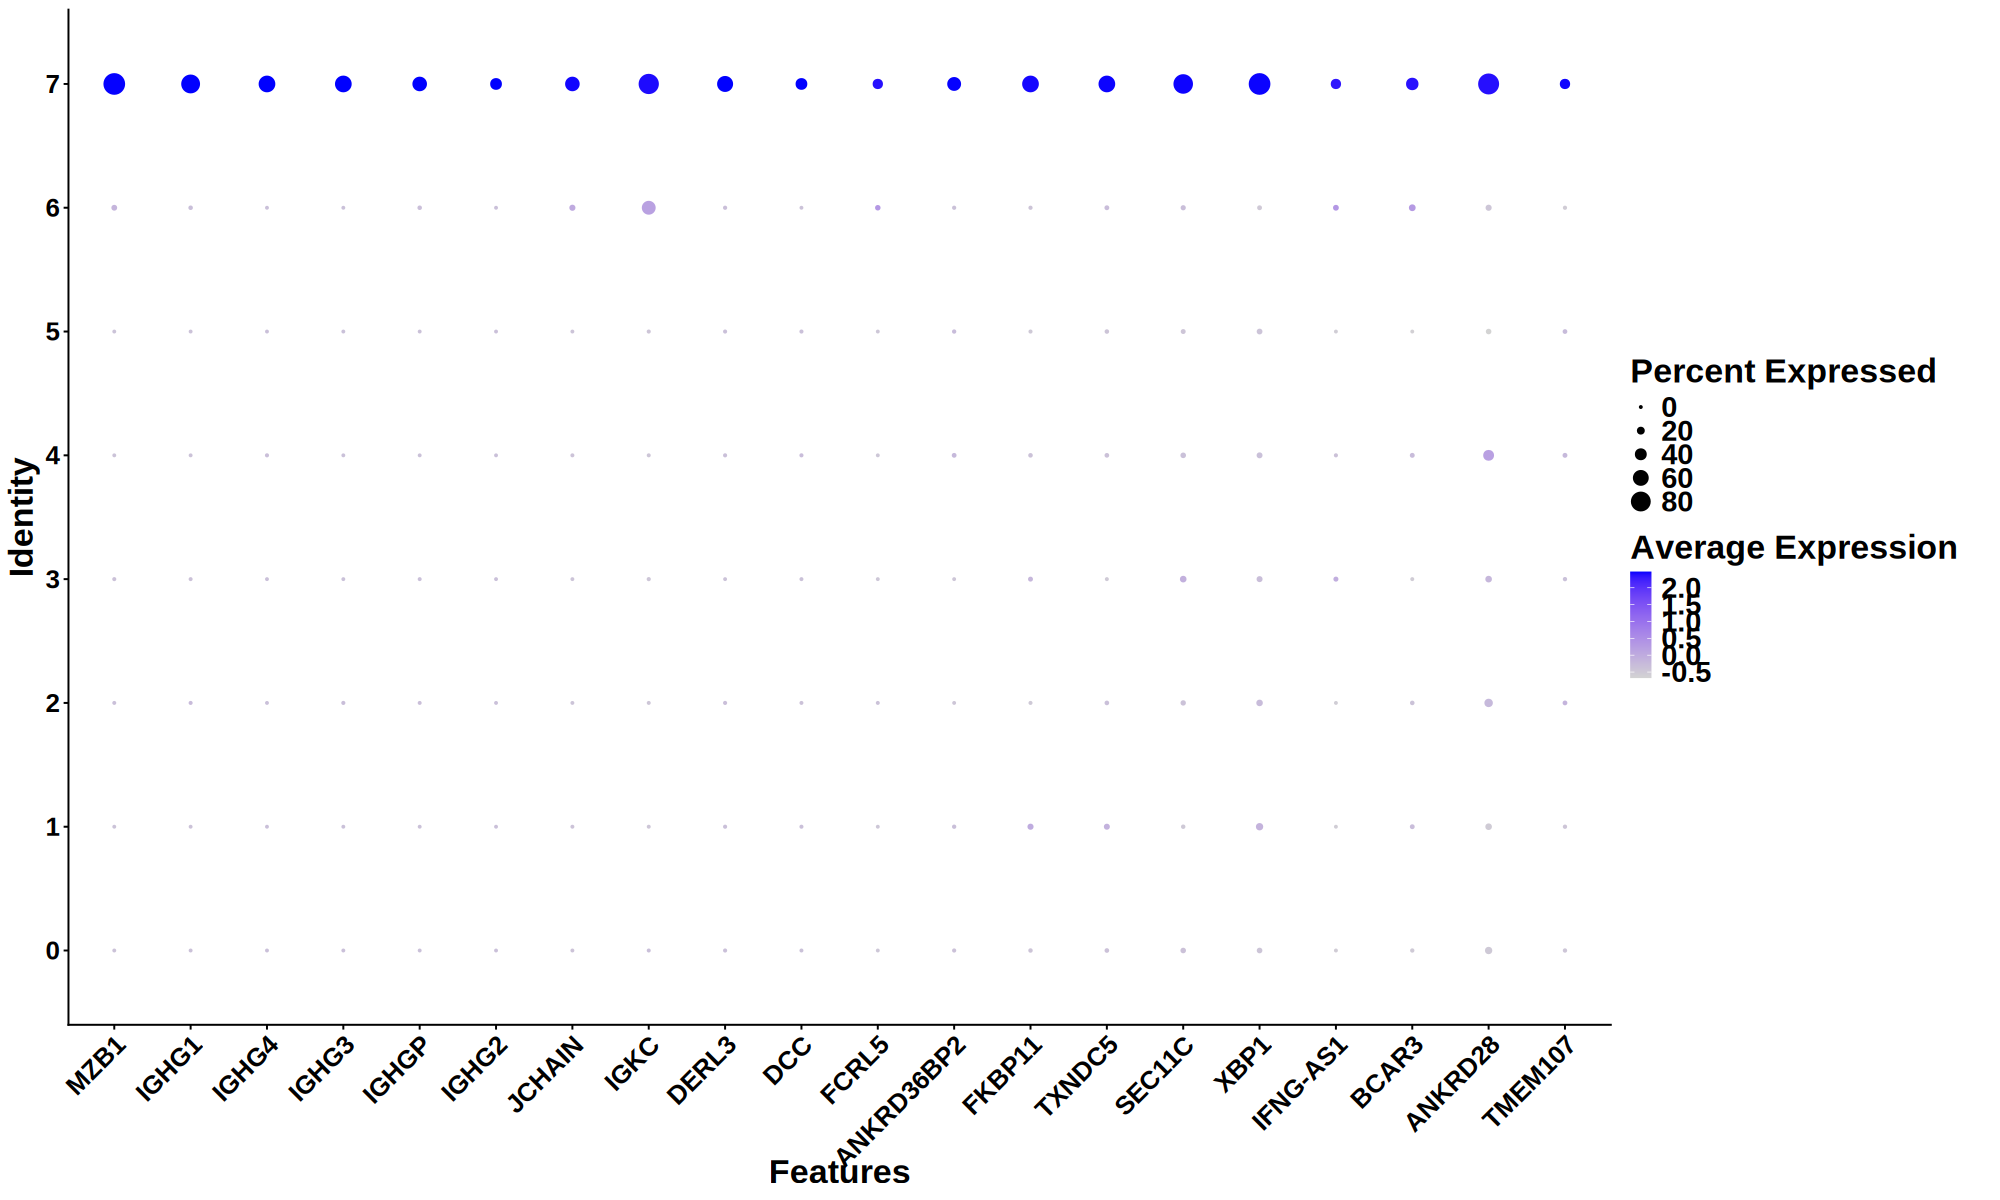

In [23]:
options(repr.plot.width = 20, repr.plot.height = 12, repr.plot.res = 100)
## Dotplot for Cluster_7
obj40.cluster7.markers$gene %>% write.table("obj40.cluster7.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster7.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))


## Aggregated average gene expression across clusters for the top 3 marker genes together plotted as heatmap

In [24]:
DefaultAssay(obj40) <- "RNA"
obj40 <- NormalizeData(obj40)
obj40.averages <- Seurat::AverageExpression(obj40, return.seurat=TRUE, assays = "RNA", layer = "data")

Normalizing layer: counts

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `ident` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
Centering and scaling data matrix



In [25]:
top_3_genes <- obj40.markers %>% group_by(cluster) %>% top_n(n = 3, wt = avg_log2FC)
top_3_genes

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2.367072e-98,3.935531,0.411,0.030,4.643722e-94,0,CALML5
1.127403e-70,3.424133,0.371,0.053,2.211740e-66,0,KRT6A
4.218057e-66,3.801264,0.332,0.041,8.274984e-62,0,KRT14
1.045085e-279,8.995782,0.760,0.008,2.050249e-275,1,COL3A1
9.401689e-154,9.125191,0.435,0.003,1.844423e-149,1,POSTN
6.465251e-127,8.992126,0.365,0.003,1.268353e-122,1,SFRP2
3.058850e-277,8.854426,0.743,0.006,6.000851e-273,2,C1QA
1.086070e-273,9.380992,0.729,0.004,2.130651e-269,2,C1QB
1.362662e-119,8.741417,0.327,0.001,2.673269e-115,2,MS4A4A


Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`).”


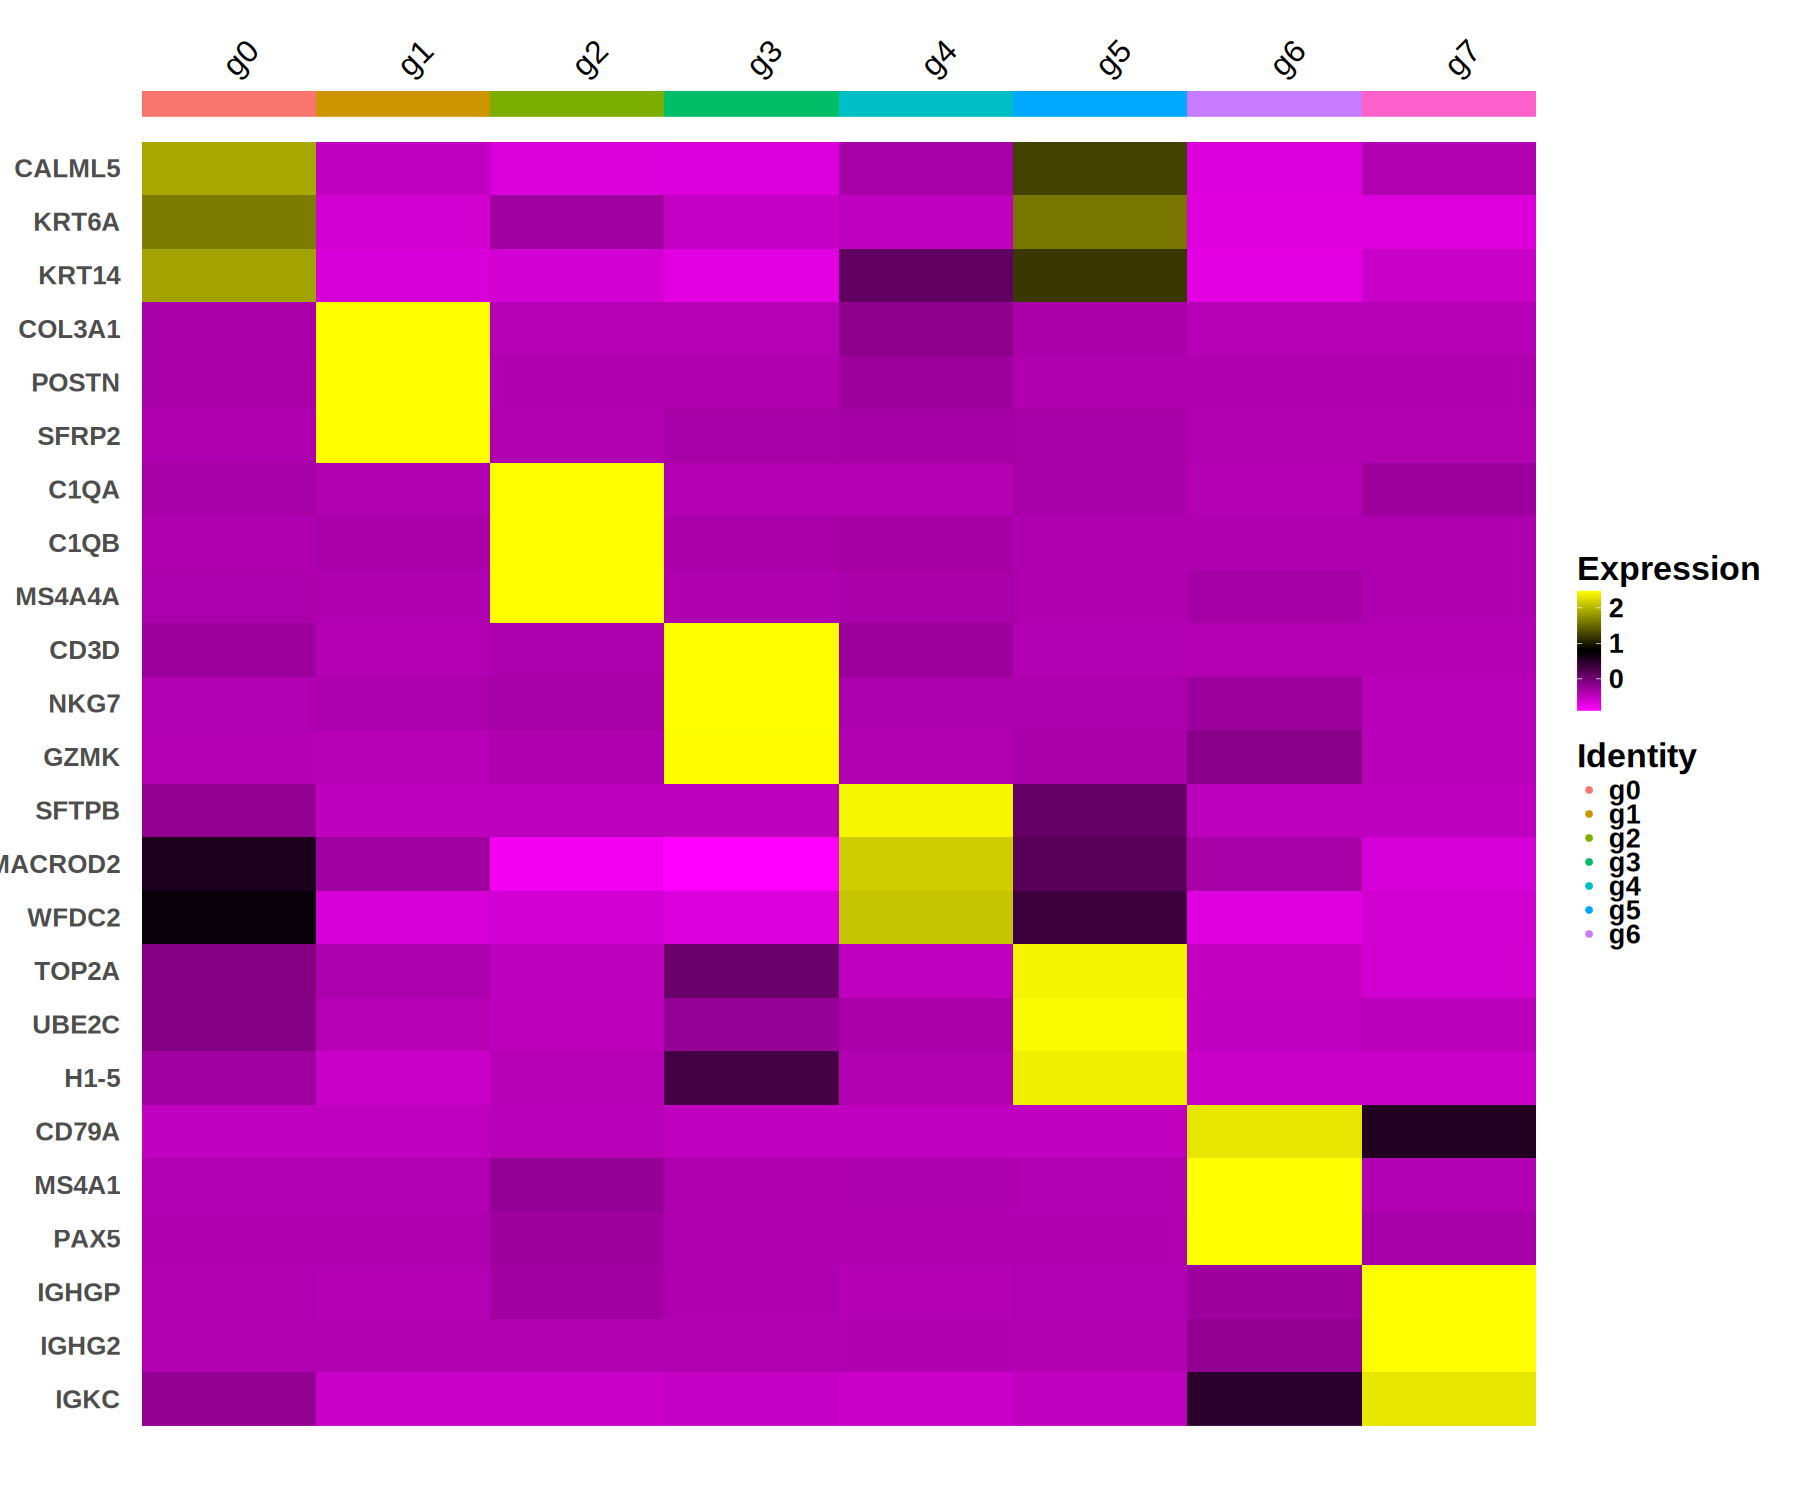

In [26]:
options(repr.plot.width = 18, repr.plot.height = 15, repr.plot.res = 100)
DoHeatmap(obj40.averages, features = as.character(c(top_3_genes$gene)), slot = "scale.data", draw.lines = FALSE, size = 8) &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

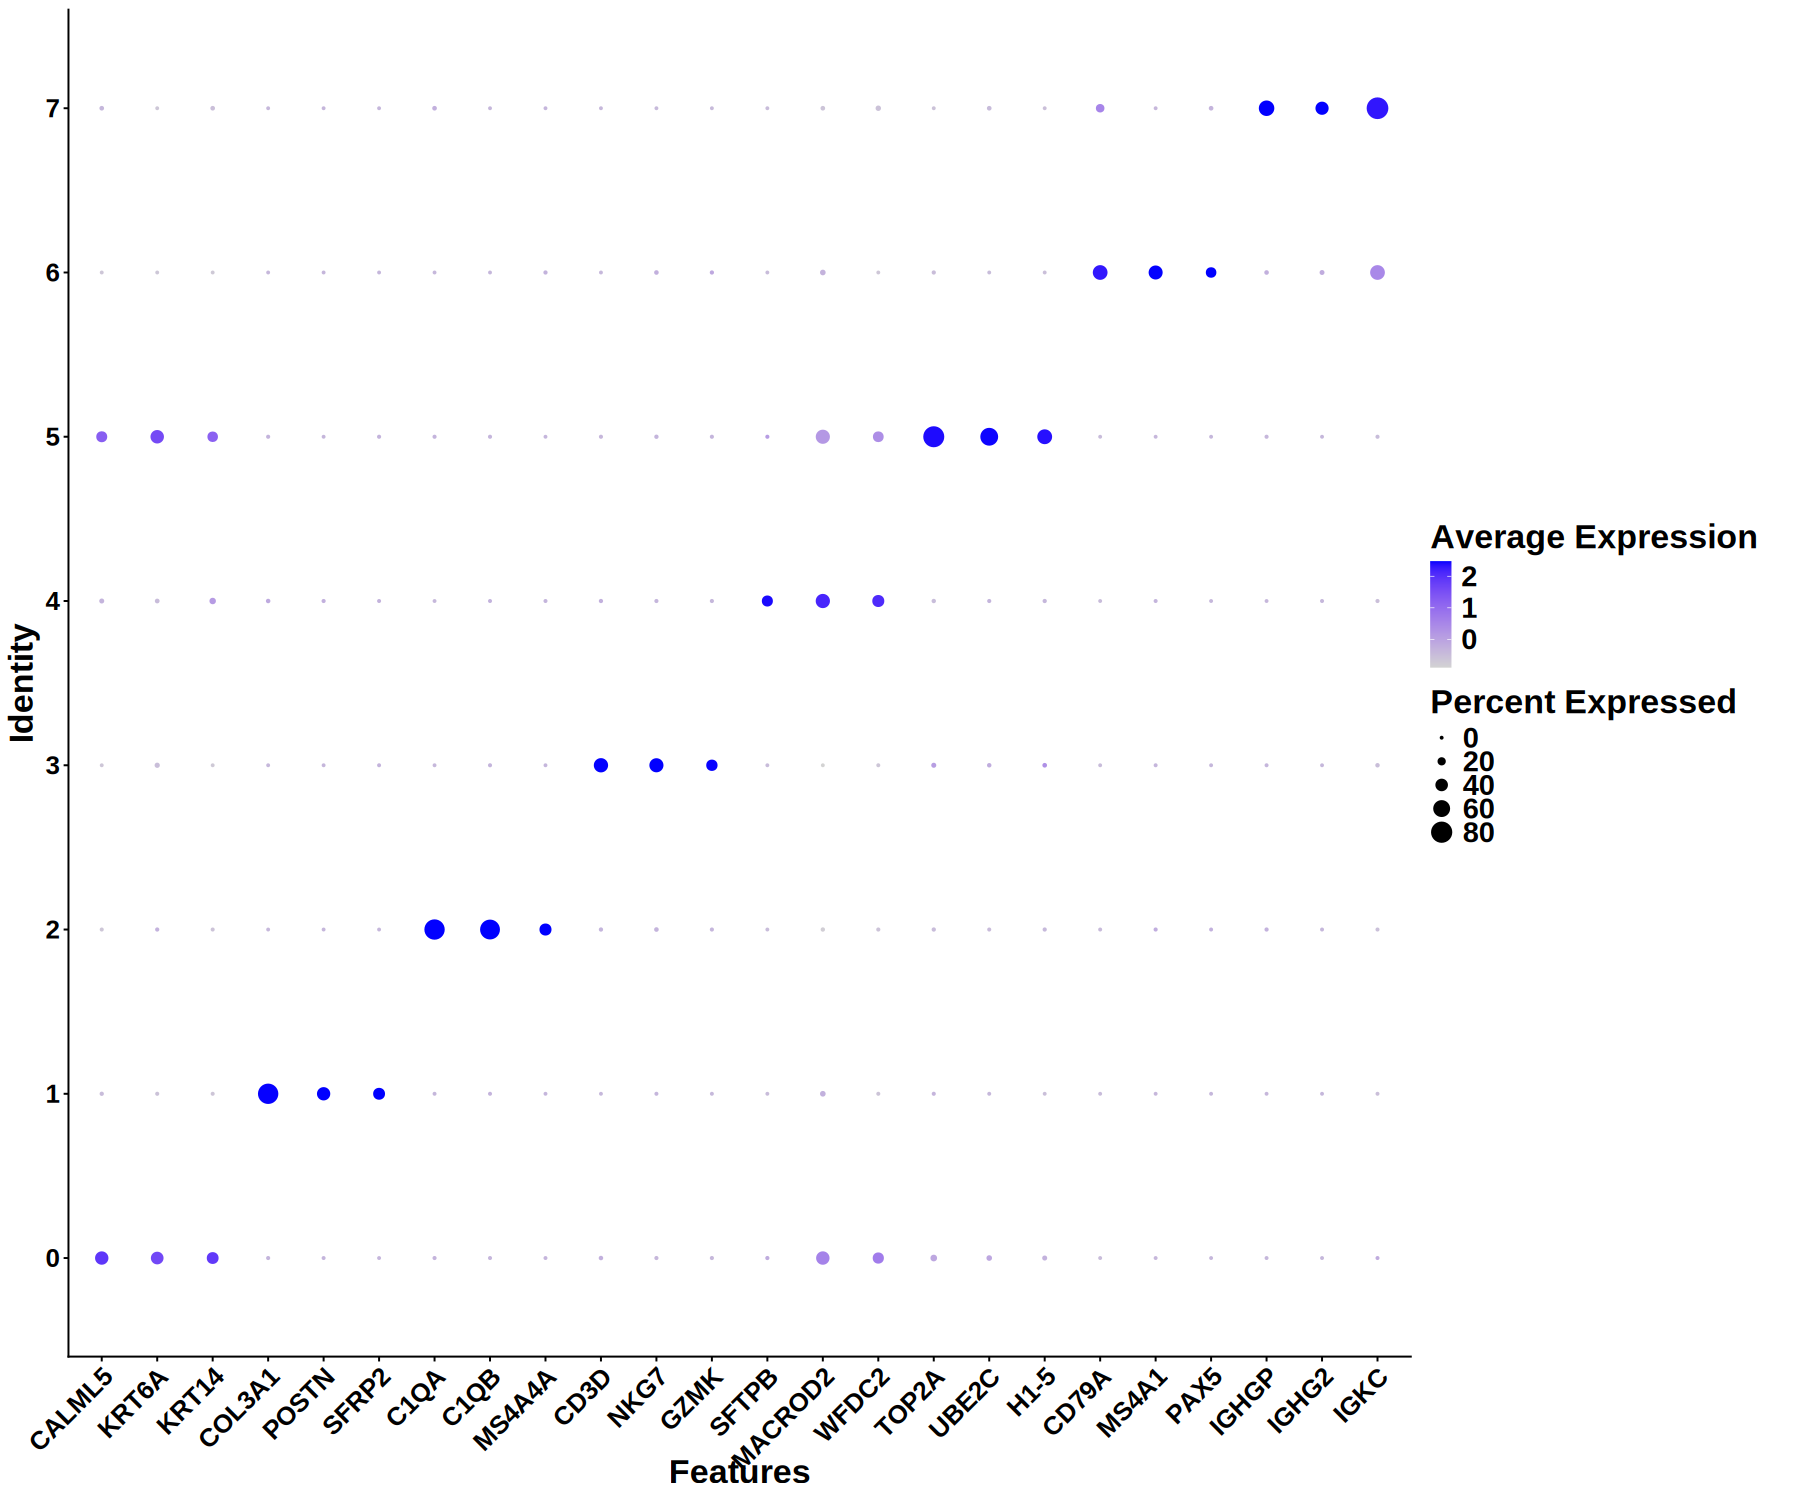

In [27]:
options(repr.plot.width = 18, repr.plot.height = 15, repr.plot.res = 100)
DotPlot(obj40, features = c(top_3_genes$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold")) &  theme(text = element_text(size = 24, face="bold")) + theme(axis.text=element_text(size=18))

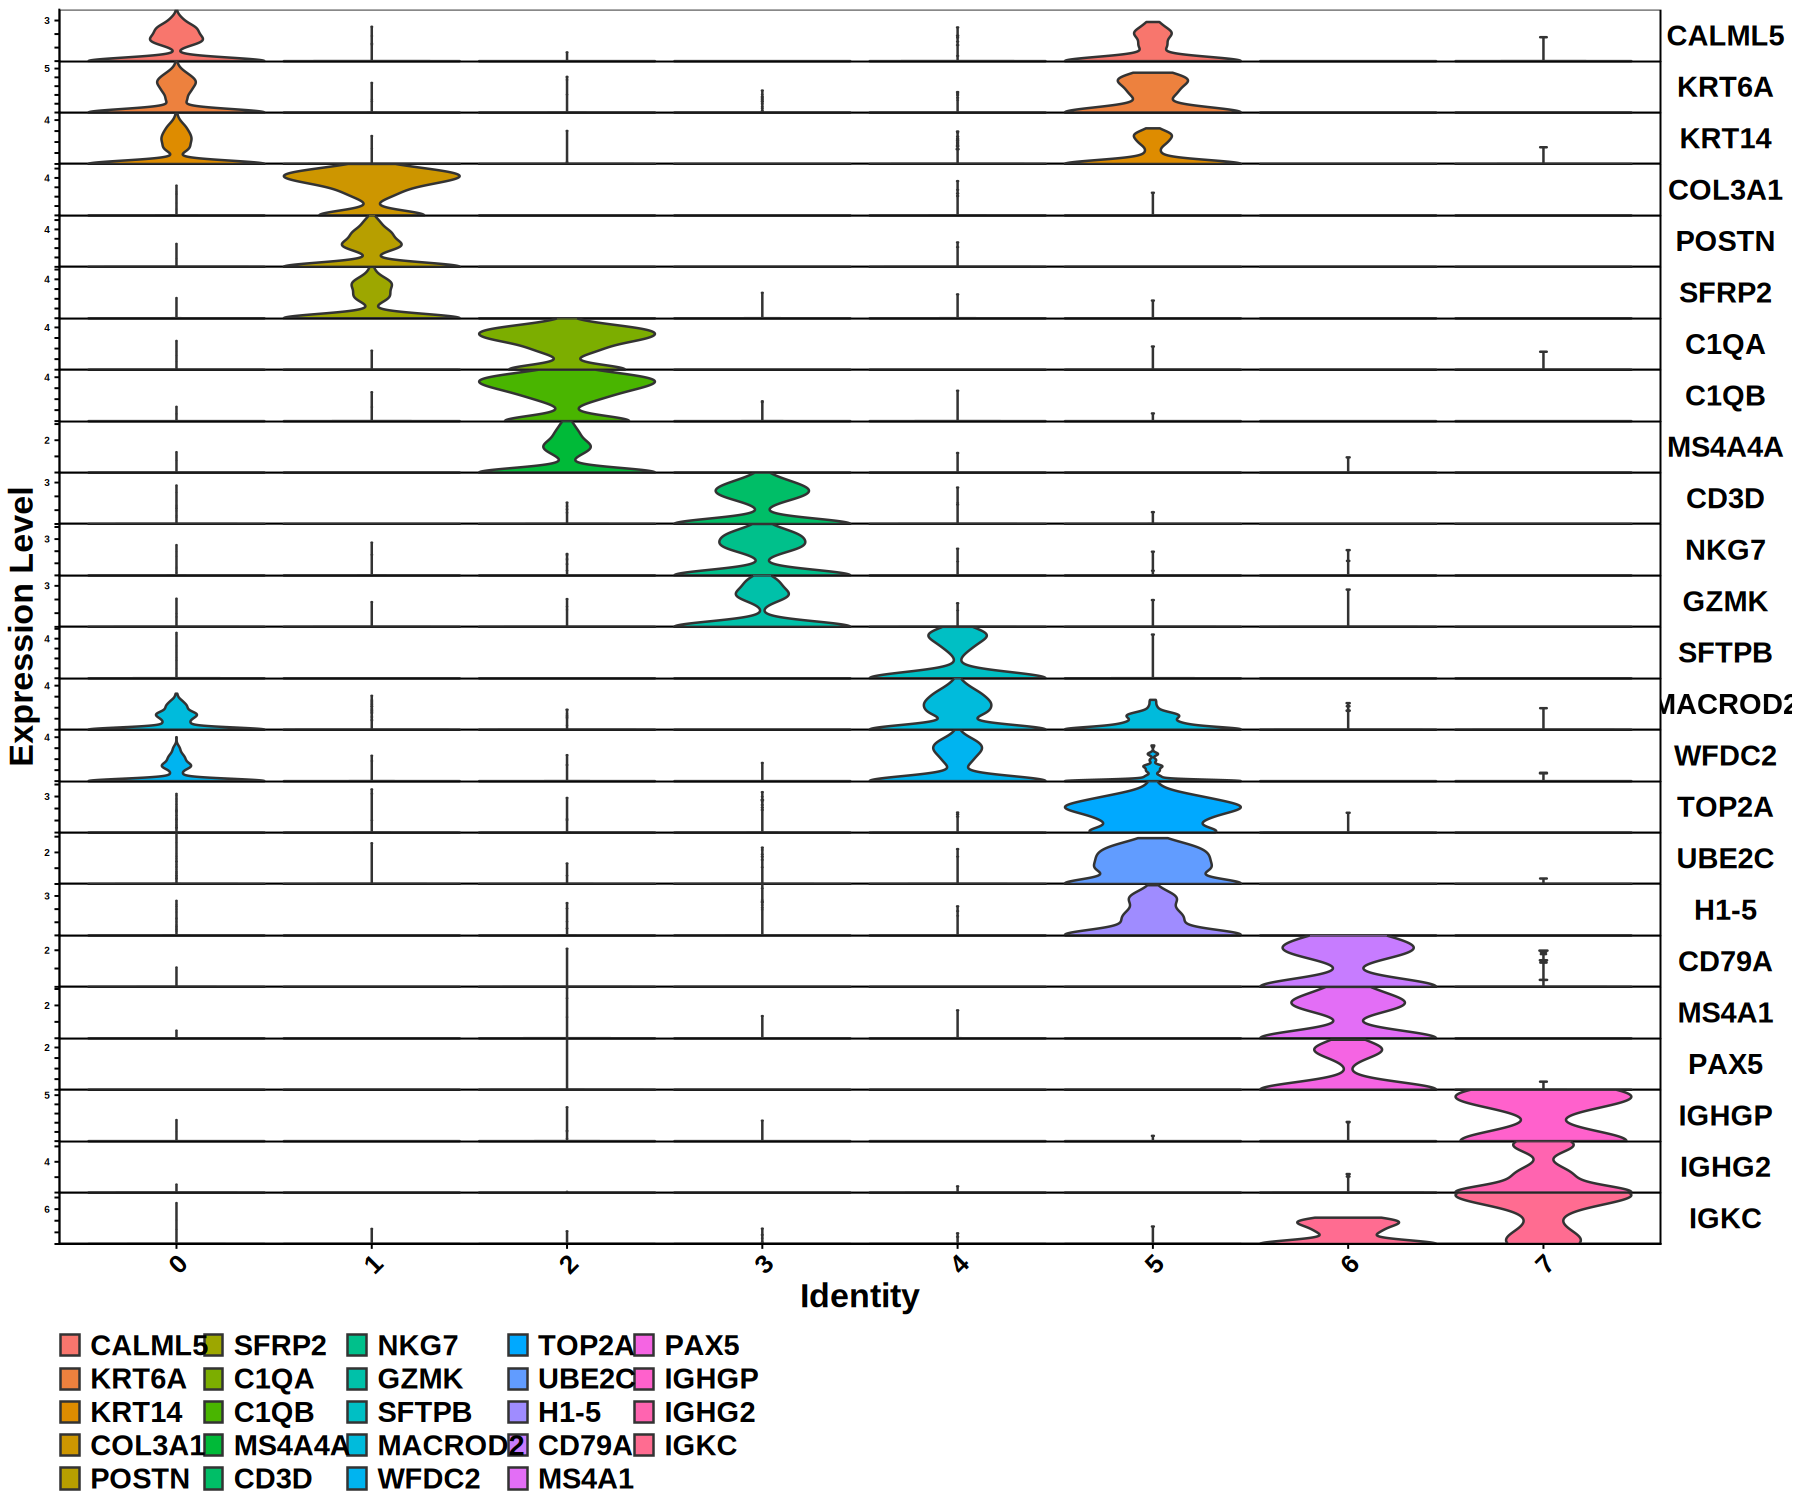

In [28]:
options(repr.plot.width = 18, repr.plot.height = 15, repr.plot.res = 100)
VlnPlot(obj40, features = c(top_3_genes$gene), layer = 'data', group.by = "seurat_clusters", pt.size = 0, stack = TRUE, flip = TRUE) + theme(legend.position = 'bottom') &  theme(text = element_text(size = 24, face="bold")) +
  theme(axis.text=element_text(size=18))

# Cell Type Annotation

In [29]:
library(AzimuthAPI)

In [30]:
obj40 <- CloudAzimuth(obj40)



── Running Pan-human Azimuth on the cloud ──────────────────────────────────────

ℹ Uploading dataset...

ℹ Uploading file and listening for updates...

✔ File successfully uploaded.

Activating environment 'CloudAnnotate'...

Environment 'CloudAnnotate' is now active.



── panhumanpy version: 1.0.0 ──



Parsing command line arguments...

Formatting arguments for ANNotate function...

Cloud_ANNotate_R is being executed from the command line...

Reading Seurat object from
/tmp/cloudazimuth/86a8c8ad-b537-43f3-bc2b-f3de9e003688/file5ef251fa0c5.rds

Running ANNotate function...



Running Pan-human Azimuth:



── Reference model and parameters: ──



Model version: v1

Model name: M0.2

Evaluation batch size: 8192

Extract embeddings: True

Run umap: False

Refine labels in postprocessing: True

Map to Cell Ontology columns: None

Include CL ID: False

Integer counts detected by panhumanpy.ANNotate : False

Log-normalization performed by panhumanpy.ANNotate: False

Query object:

Total

In [31]:
obj40@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,nCount_SCT,nFeature_SCT,sample,integrated_snn_res.0.4,seurat_clusters,silhouette_score,full_hierarchical_labels,final_level_labels,final_level_confidence,full_consistent_hierarchy,azimuth_broad,azimuth_medium,azimuth_fine,azimuth_label
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<chr>
AAACCCAAGTACAACA-1,1,21368.5062,5563,5.2828563,15.695680,3466,1633,preT,0,0,0.092996424,Immune cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.2939181,FALSE,False,False,False,Airway basal cell
AAACCCACATCCGGCA-1,1,2185.0301,1247,4.4332051,15.481174,4023,1233,preT,6,6,0.276890213,Immune cell|Lymphoid cell|B cell,B cell,0.9989366,TRUE,Immune cell,B cell,Memory B cell,B cell
AAACGAACAGGTGTGA-1,1,908.4158,597,5.4038361,22.289339,3441,660,preT,3,3,0.469265422,Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell|Memory CD8 T cell|GZMK CD8 T cell,GZMK CD8 T cell,0.5162206,TRUE,Immune cell,T cell,GZMK CD8 T cell,GZMK CD8 T cell
AAACGAAGTTCGTTCC-1,1,1209.6016,803,1.7431788,16.287654,3658,830,preT,3,3,0.297718122,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Memory CD4 T cell,Memory CD4 T cell,0.6011285,TRUE,Immune cell,T cell,Memory CD4 T cell,Memory CD4 T cell
AAAGAACTCCCATGGG-1,1,11959.1598,4019,5.6813659,16.286612,3585,1671,preT,0,0,-0.088038628,Immune cell|Hematopoietic precursor cell|MPP,MPP,0.1740963,TRUE,Immune cell,Hematopoietic precursor cell,MPP,MPP
AAAGAACTCGGTGTAT-1,1,1406.5290,790,3.5262480,28.195370,3654,790,preT,3,3,0.289982962,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Naive CD4 T cell,Naive CD4 T cell,0.3833716,FALSE,False,False,False,Naive CD4 T cell
AAAGGATCAAGTGGTG-1,1,10456.9103,3467,4.5589630,22.770045,3502,1418,preT,0,0,0.022799112,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.5835928,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGGCAGTGCAACG-1,1,22611.9056,5912,6.2437669,16.037617,3543,1765,preT,0,0,0.054652965,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.3796144,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGTAAGTTGCGCC-1,1,15341.5871,4030,6.9310925,25.275847,3883,1665,preT,0,0,0.095814736,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.4597166,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell


In [32]:
# remove cells with low scores
obj40_qc <- subset(obj40, final_level_confidence > 0.5)

In [33]:
# Use azimuth_embed as input Output a UMAP stored in azimuth_umap
obj40_qc <- RunUMAP(obj40_qc, dims = 1:128, reduction = "azimuth_embed", reduction.name = "azimuth_umap")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
00:44:04 UMAP embedding parameters a = 0.9922 b = 1.112

00:44:04 Read 1132 rows and found 128 numeric columns

00:44:05 Using Annoy for neighbor search, n_neighbors = 30

00:44:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:44:05 Writing NN index file to temp file /tmp/RtmpMzUGi2/file5ef3cda2f66

00:44:05 Searching Annoy index using 1 thread, search_k = 3000

00:44:05 Annoy recall = 100%

00:44:06 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

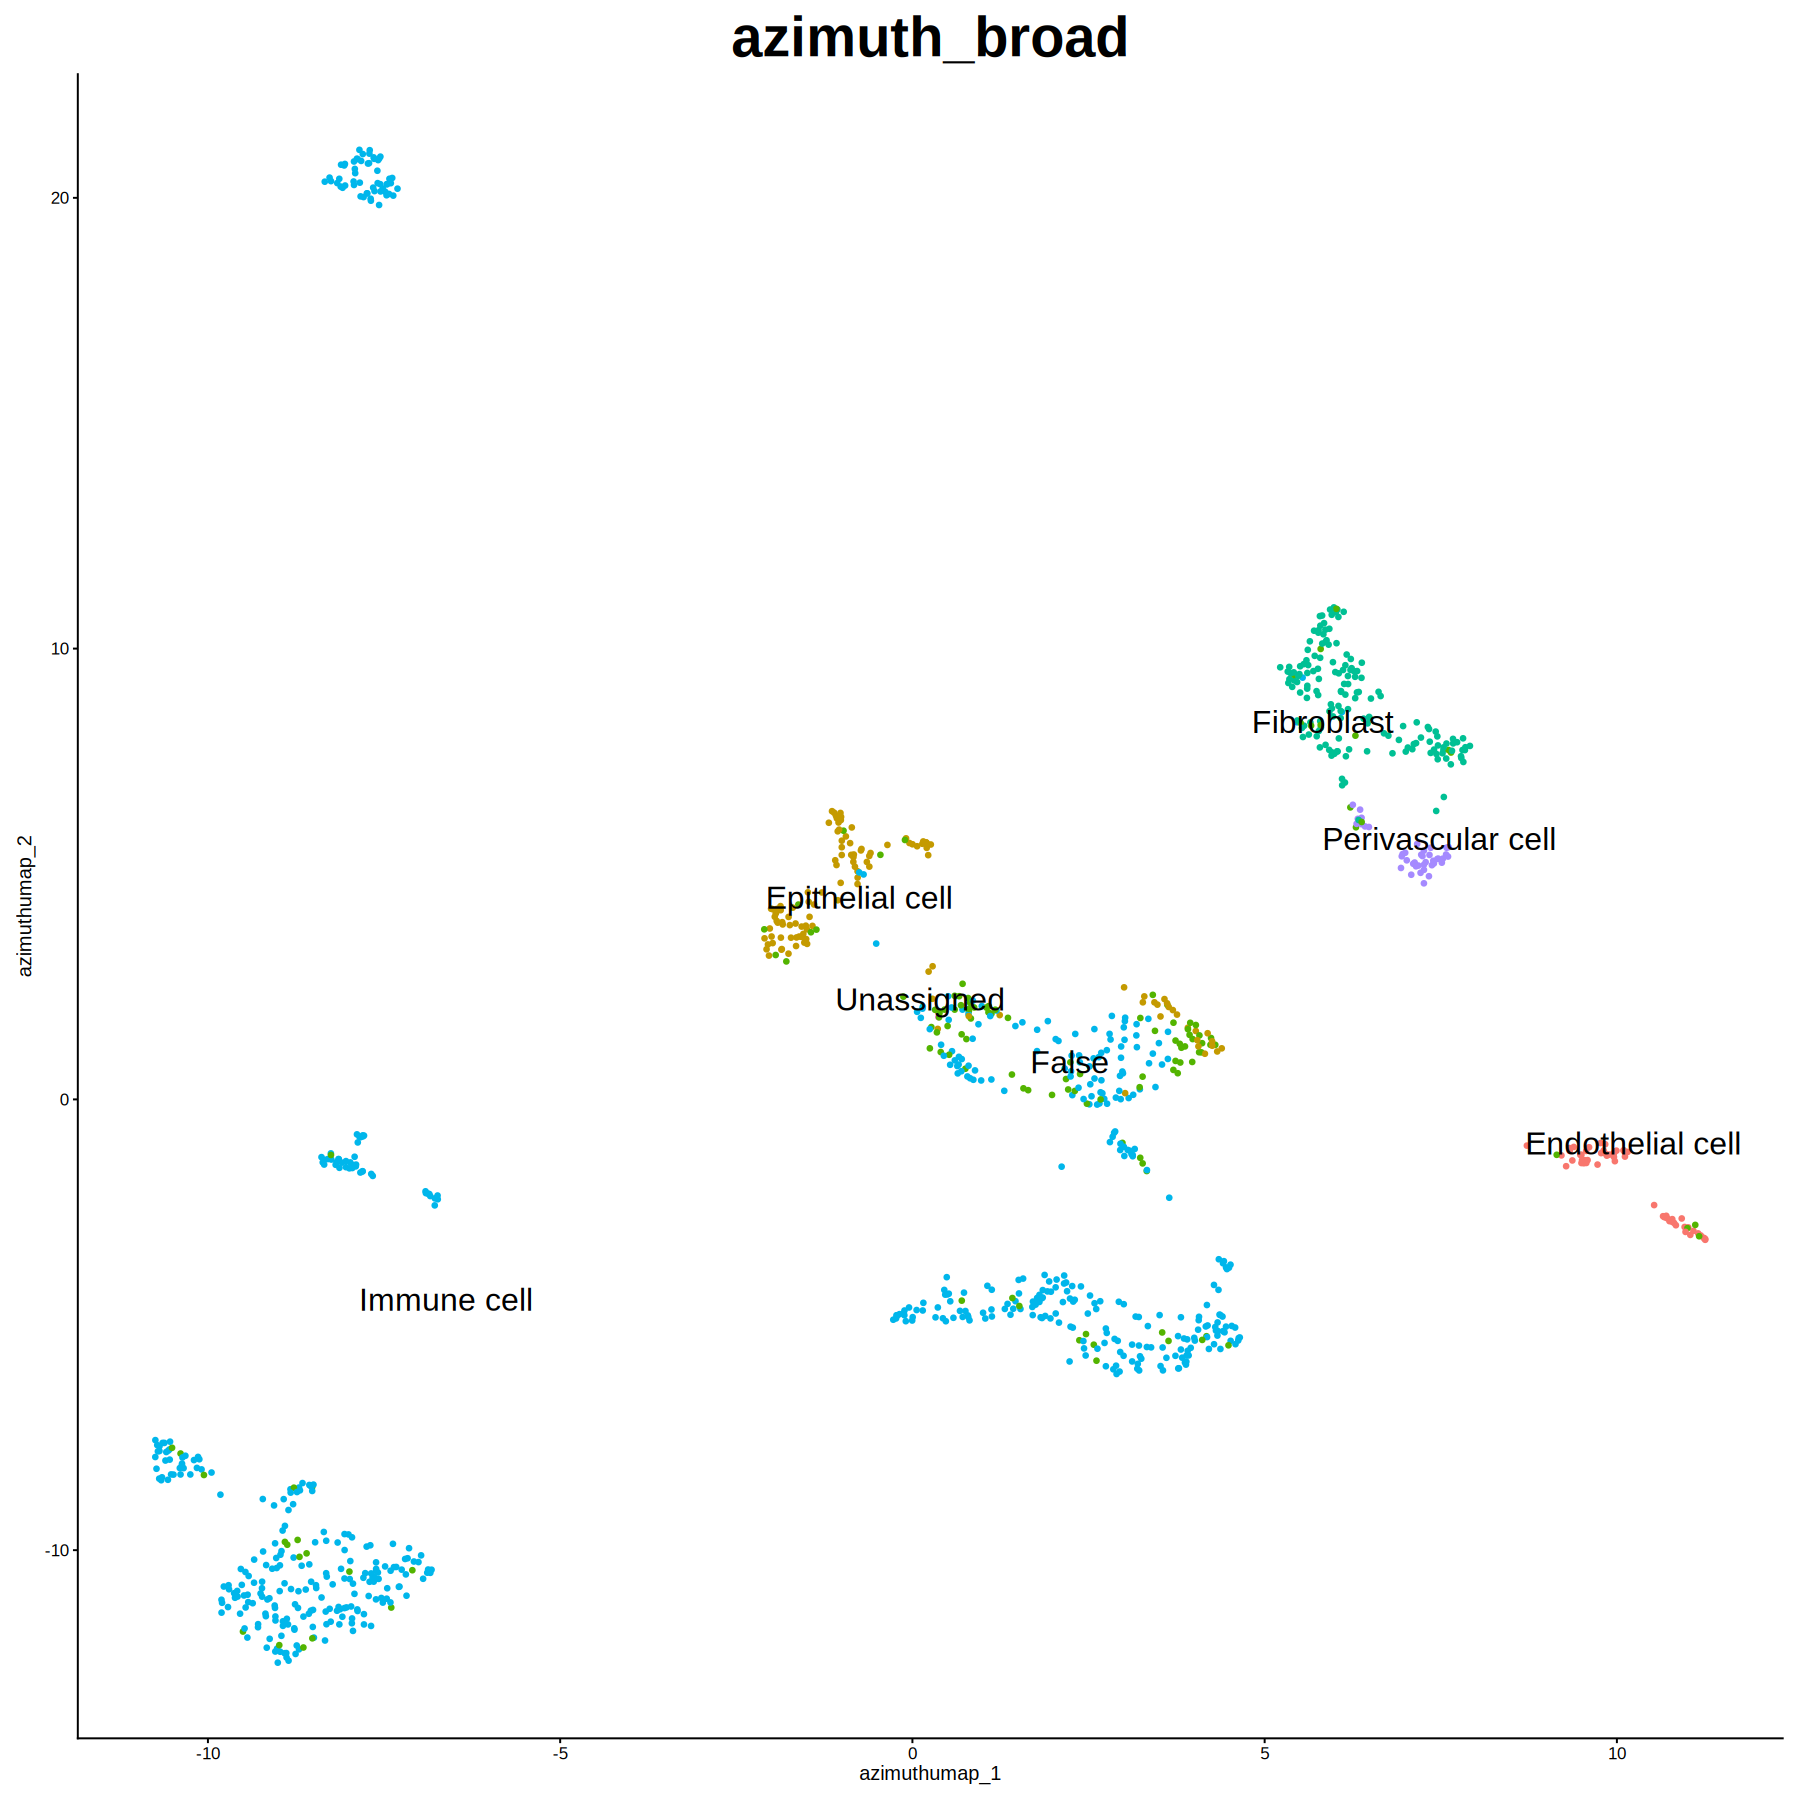

In [34]:
options(repr.plot.width = 18, repr.plot.height = 18, repr.plot.res = 100)
p_az_brd <- DimPlot(obj40_qc, group.by = "azimuth_broad", label.size = 8, label = T, reduction = "azimuth_umap", repel = TRUE) + NoLegend() & theme(plot.title = element_text(size = 40))
p_az_brd

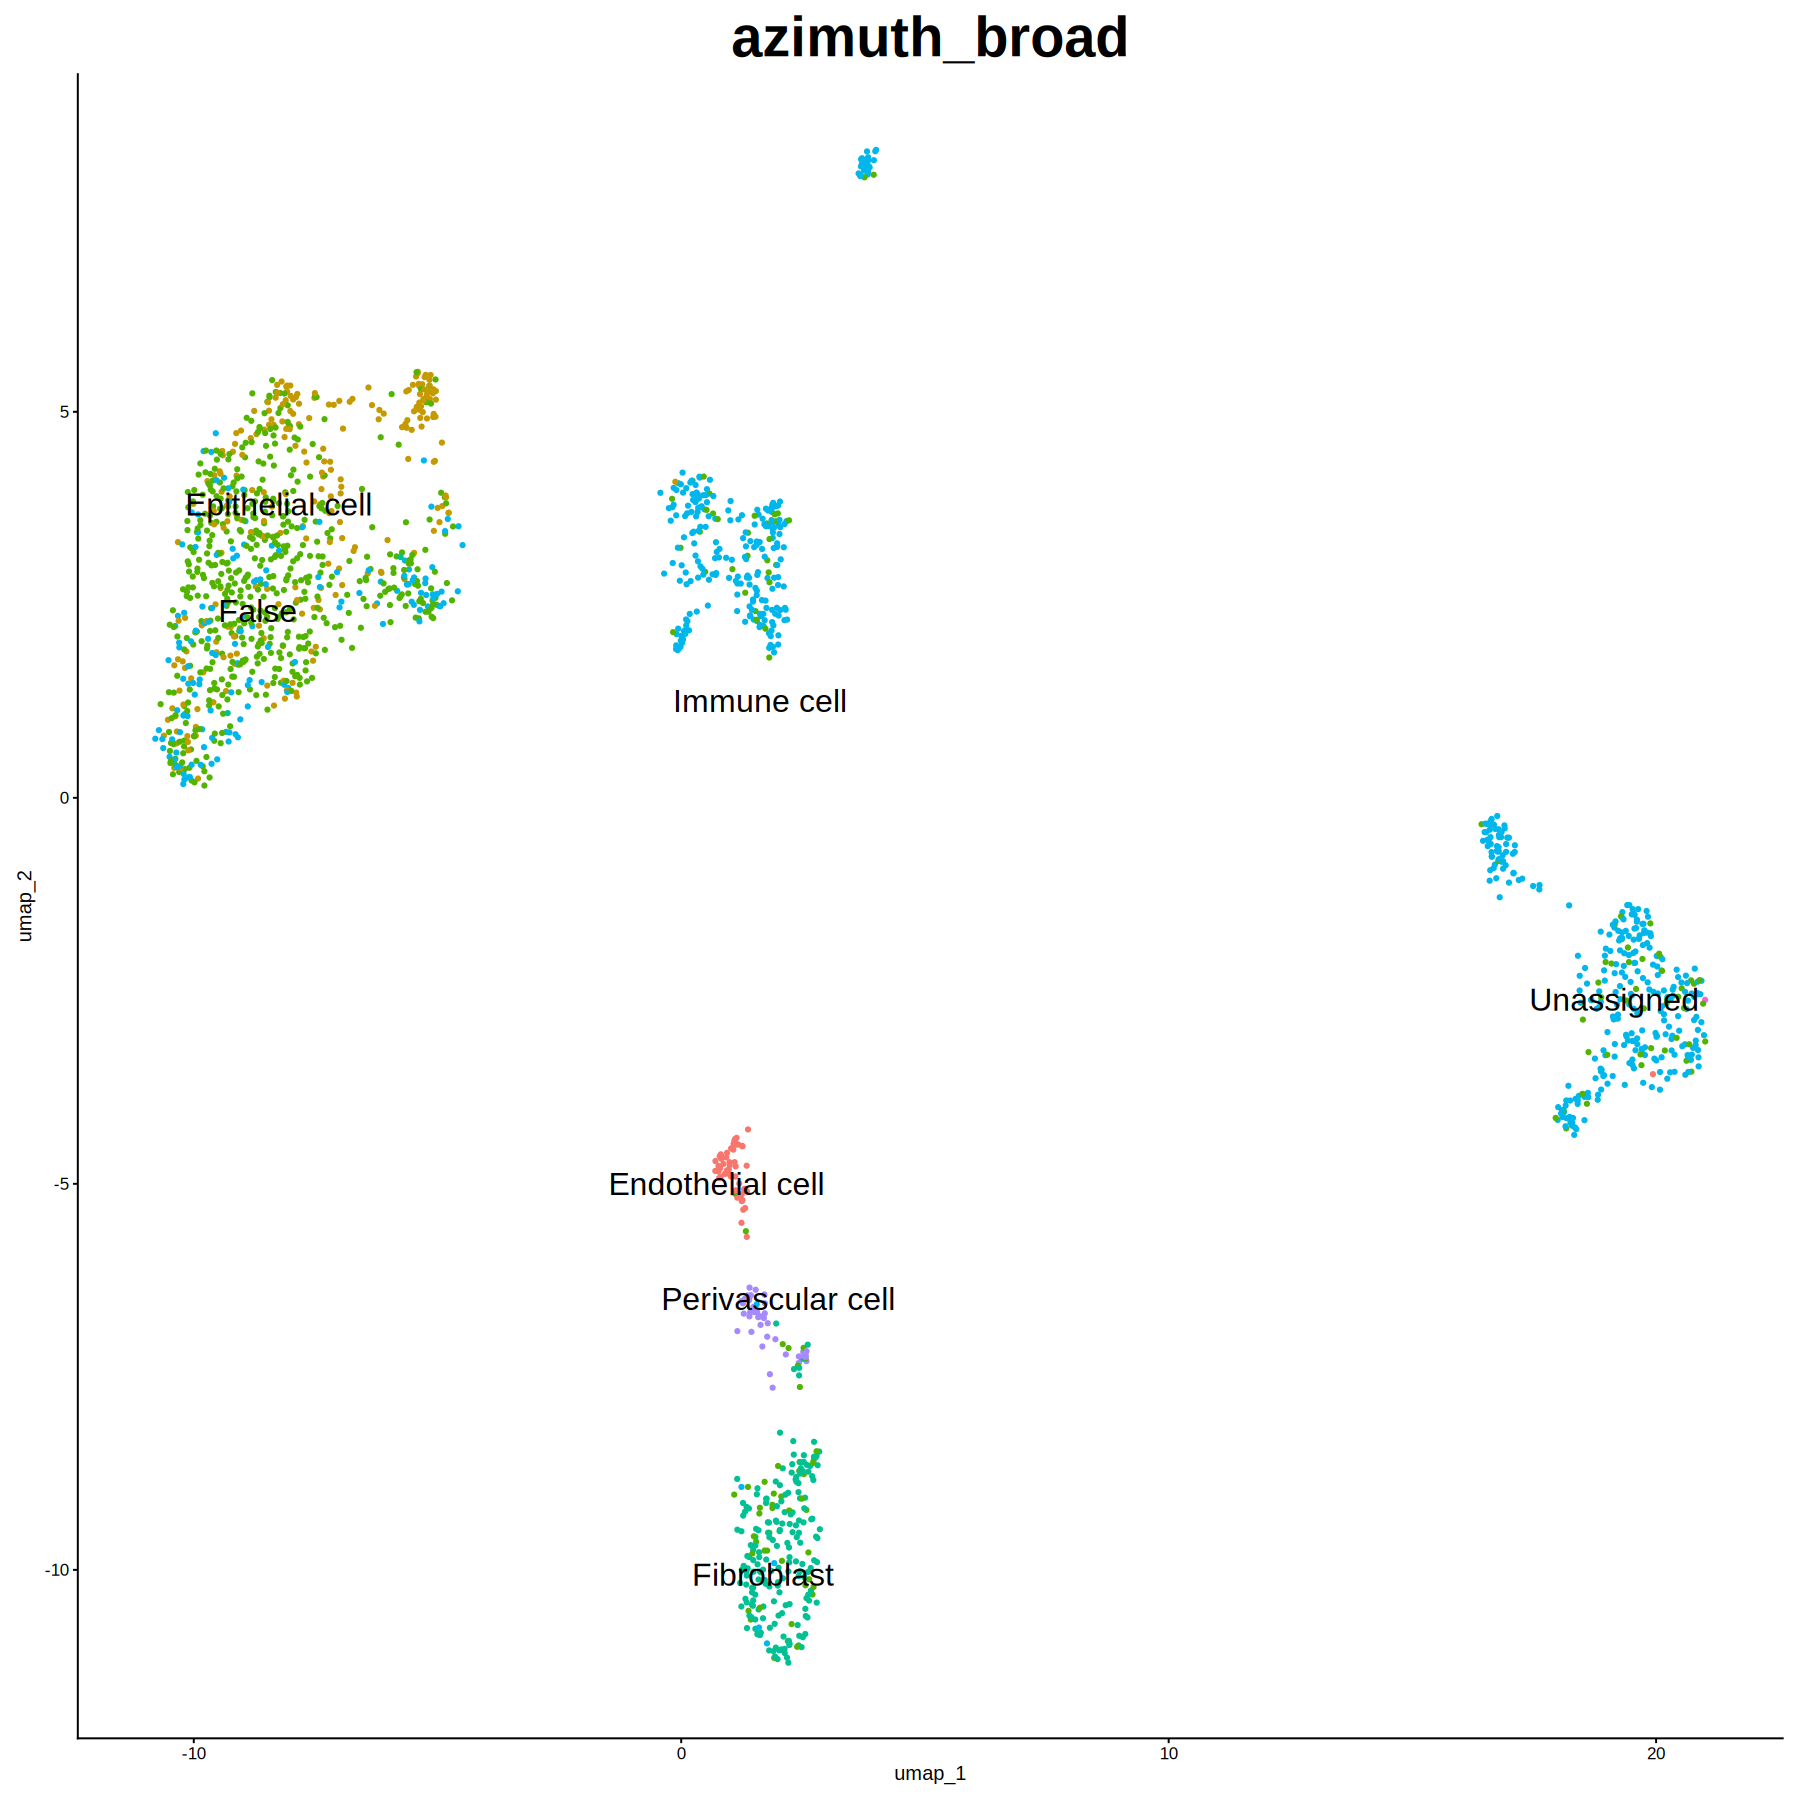

In [35]:
options(repr.plot.width = 18, repr.plot.height = 18, repr.plot.res = 100)
p_az_brd <- DimPlot(obj40, group.by = "azimuth_broad", label.size = 8, label = T, reduction = "umap",
    repel = TRUE) + NoLegend() & theme(plot.title = element_text(size = 40))
p_az_brd

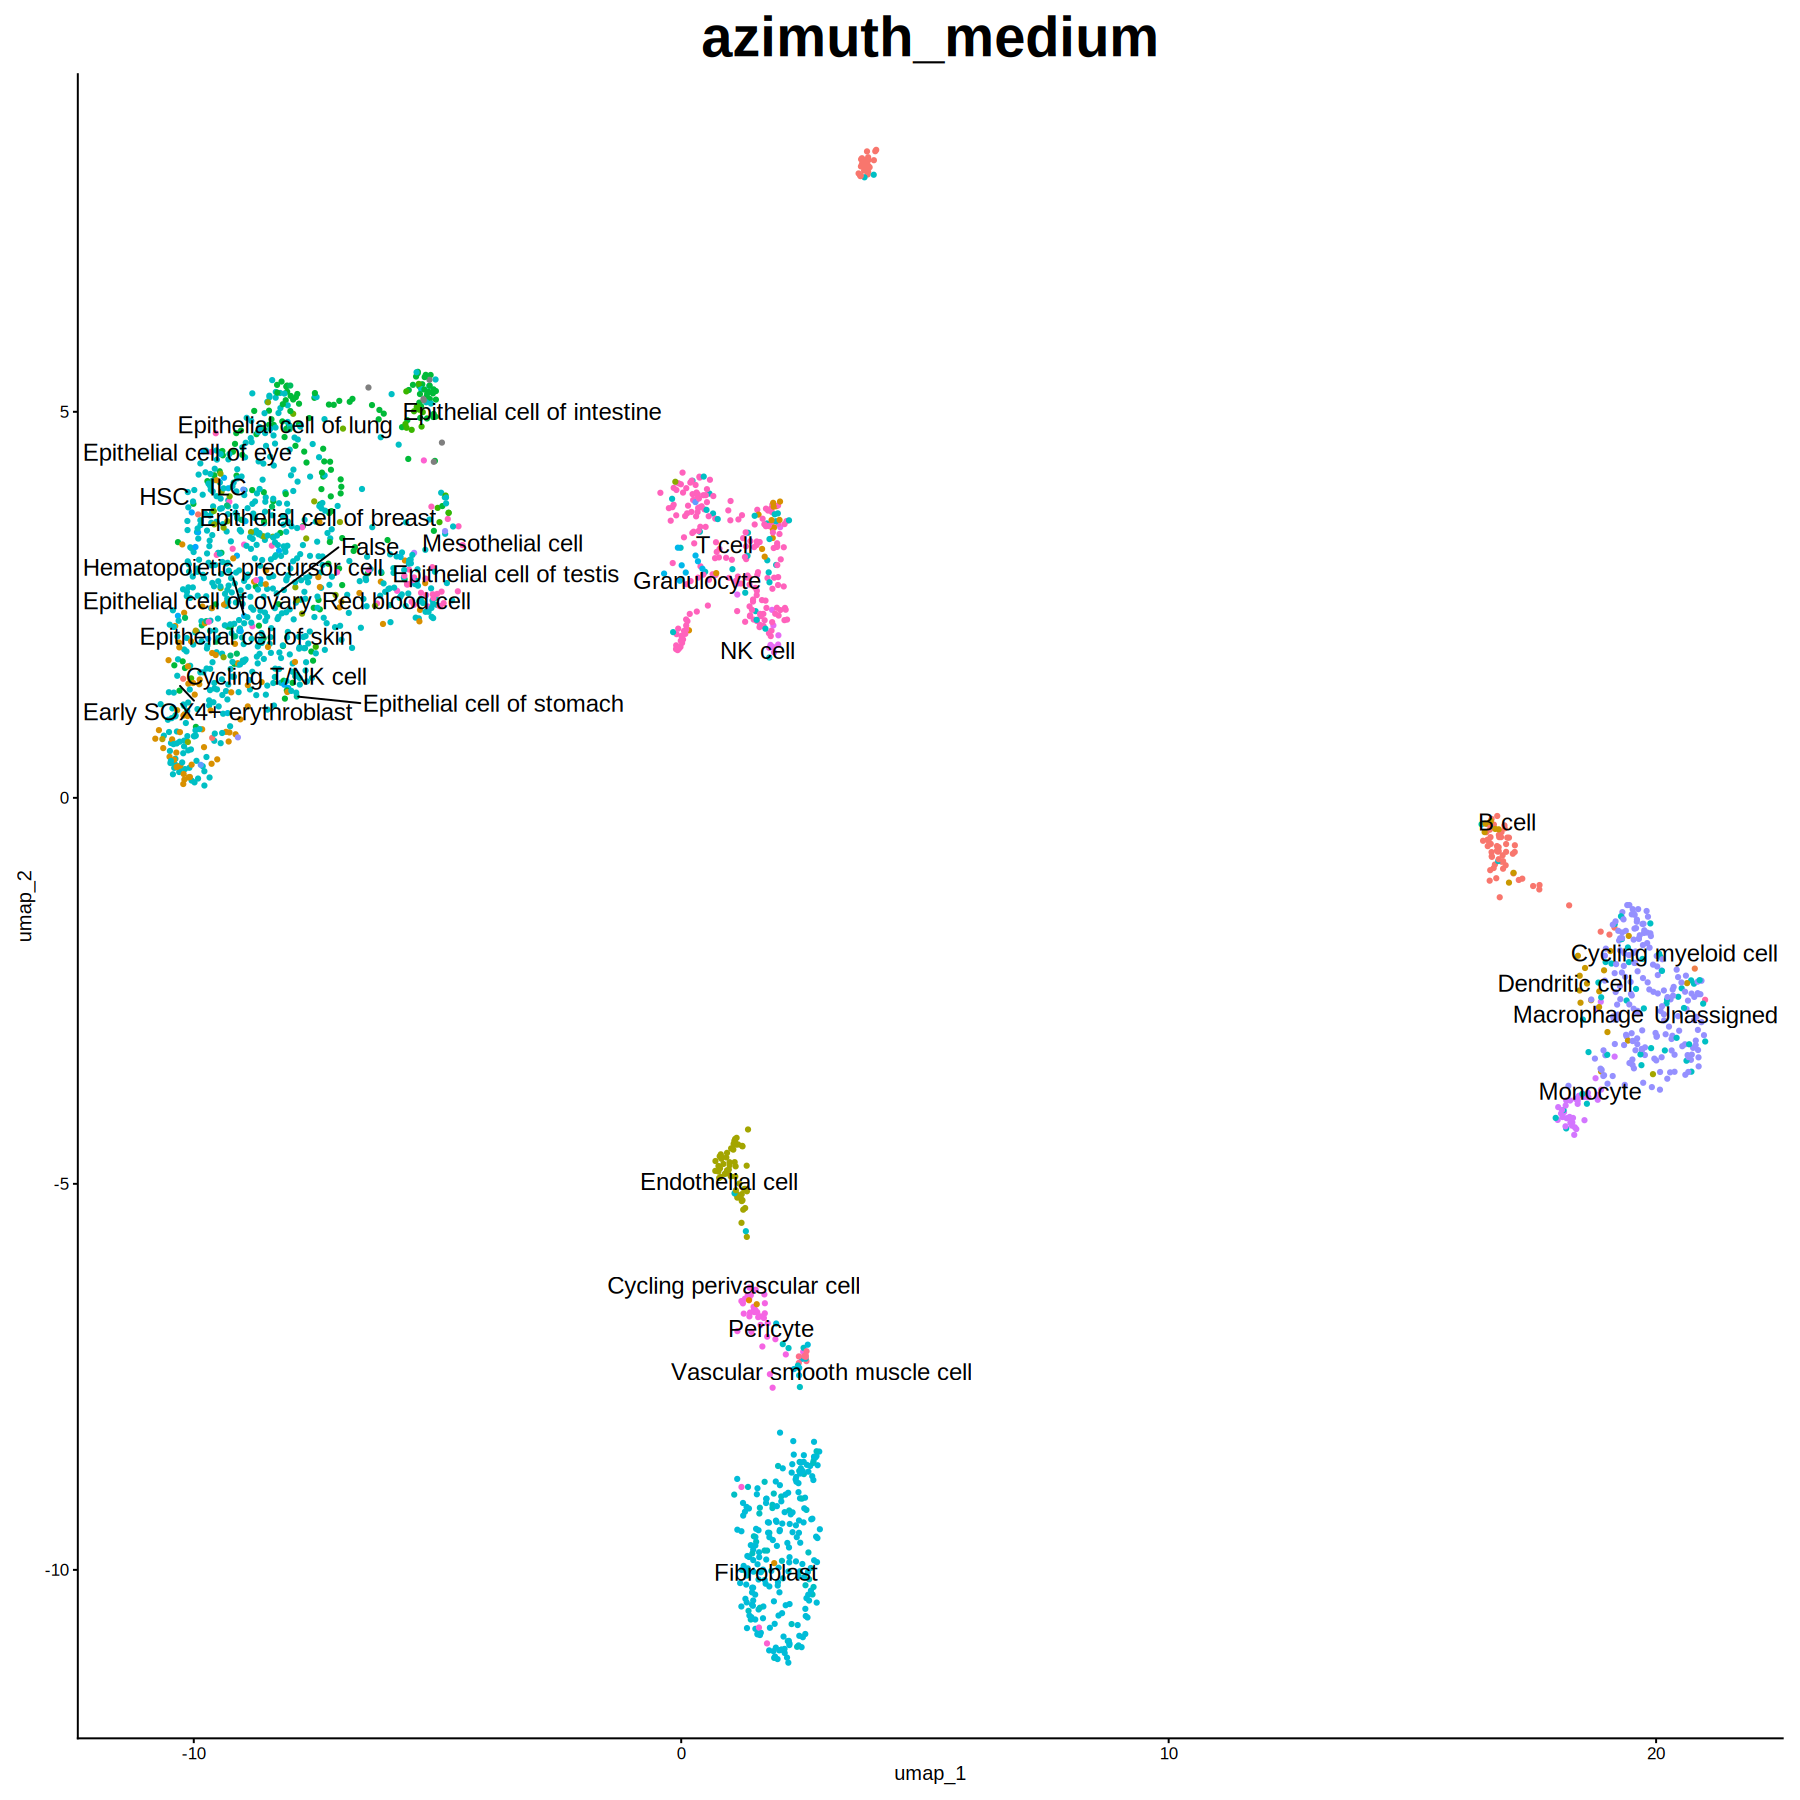

In [36]:
options(repr.plot.width = 18, repr.plot.height = 18, repr.plot.res = 100)
p_az_med <- DimPlot(obj40, group.by = "azimuth_medium", label.size = 6, label = T, reduction = "umap",
    repel = TRUE) + NoLegend() & theme(plot.title = element_text(size = 40))
p_az_med

In [37]:
#install.packages("HGNChelper")

In [38]:
#install.packages("openxlsx", dependencies = TRUE)

In [39]:
# load libraries
lapply(c("dplyr","Seurat","HGNChelper"), library, character.only = T)

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.



[[1]]
 [1] "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"       "SeuratObject"
 [6] "sp"           "dplyr"        "stats"        "graphics"     "grDevices"   
[11] "utils"        "datasets"     "methods"      "base"        

[[2]]
 [1] "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"       "SeuratObject"
 [6] "sp"           "dplyr"        "stats"        "graphics"     "grDevices"   
[11] "utils"        "datasets"     "methods"      "base"        

[[3]]
 [1] "HGNChelper"   "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"      
 [6] "SeuratObject" "sp"           "dplyr"        "stats"        "graphics"    
[11] "grDevices"    "utils"        "datasets"     "methods"      "base"

# Cell type assignment using scType

Now, let's automatically assign cell types using ScType. For that, we first load 2 additional ScType functions:

In [40]:
# load gene set preparation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
# load cell type annotation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")

Next, let's prepare gene sets from the input cell marker file. By default, we use our in-built cell marker DB, however, feel free to use your own data. Just prepare an input XLSX file in the same format as our DB file. DB file should contain four columns (tissueType - tissue type, cellName - cell type, geneSymbolmore1 - positive marker genes, geneSymbolmore2 - marker genes not expected to be expressed by a cell type)

In addition, provide a tissue type your data belongs to:


In [41]:
# DB file
db_ <- "https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx";
tissue <- "Immune system" # e.g. Immune system,Pancreas,Liver,Eye,Kidney,Brain,Lung,Adrenal,Heart,Intestine,Muscle,Placenta,Spleen,Stomach,Thymus

# prepare gene sets
gs_list <- gene_sets_prepare(db_, tissue)

Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in

In [42]:
obj40 <- ScaleData(obj40)

Centering and scaling data matrix



In [43]:
# check Seurat object version (scRNA-seq matrix extracted differently in Seurat v4/v5)
seurat_package_v5 <- isFALSE('counts' %in% names(attributes(obj40[["RNA"]])));
print(sprintf("Seurat object %s is used", ifelse(seurat_package_v5, "v5", "v4")))

# extract scaled scRNA-seq matrix
scRNAseqData_scaled <- if (seurat_package_v5) as.matrix(obj40[["RNA"]]$scale.data) else as.matrix(obj40[["RNA"]]@scale.data)

# run ScType
es.max <- sctype_score(scRNAseqData = scRNAseqData_scaled, scaled = TRUE, gs = gs_list$gs_positive, gs2 = gs_list$gs_negative)

# NOTE: scRNAseqData parameter should correspond to your input scRNA-seq matrix. For raw (unscaled) count matrix set scaled = FALSE
# When using Seurat, we use "RNA" slot with 'scale.data' by default. Please change "RNA" to "SCT" for sctransform-normalized data,
# or to "integrated" for joint dataset analysis. To apply sctype with unscaled data, use e.g. obj40[["RNA"]]$counts or obj40[["RNA"]]@counts, with scaled set to FALSE.

# merge by cluster
cL_resutls <- do.call("rbind", lapply(unique(obj40@meta.data$seurat_clusters), function(cl){
    es.max.cl = sort(rowSums(es.max[ ,rownames(obj40@meta.data[obj40@meta.data$seurat_clusters==cl, ])]), decreasing = !0)
    head(data.frame(cluster = cl, type = names(es.max.cl), scores = es.max.cl, ncells = sum(obj40@meta.data$seurat_clusters==cl)), 10)
}))
sctype_scores <- cL_resutls %>% group_by(cluster) %>% top_n(n = 1, wt = scores)

# set low-confident (low ScType score) clusters to "unknown"
sctype_scores$type[as.numeric(as.character(sctype_scores$scores)) < sctype_scores$ncells/4] <- "Unknown"
print(sctype_scores[,1:3])

[1] "Seurat object v5 is used"
# A tibble: 8 × 3
# Groups:   cluster [8]
  cluster type                scores
  <fct>   <chr>                <dbl>
1 0       Cancer cells         464. 
2 6       Naive B cells        219. 
3 3       Memory CD8+ T cells  766. 
4 7       Plasma B cells       138. 
5 5       Cancer cells          75.7
6 2       Macrophages         1071. 
7 4       Unknown               24.1
8 1       Endothelial          339. 


Please note that sctype_score function (used above) accepts both positive and negative markers through gs and gs2 arguments. In case, there are no negative markers (i.e. markers providing evidence against a cell being of specific cell type) just set gs2 argument to NULL (i.e. gs2 = NULL).

We can also overlay the identified cell types on UMAP plot:

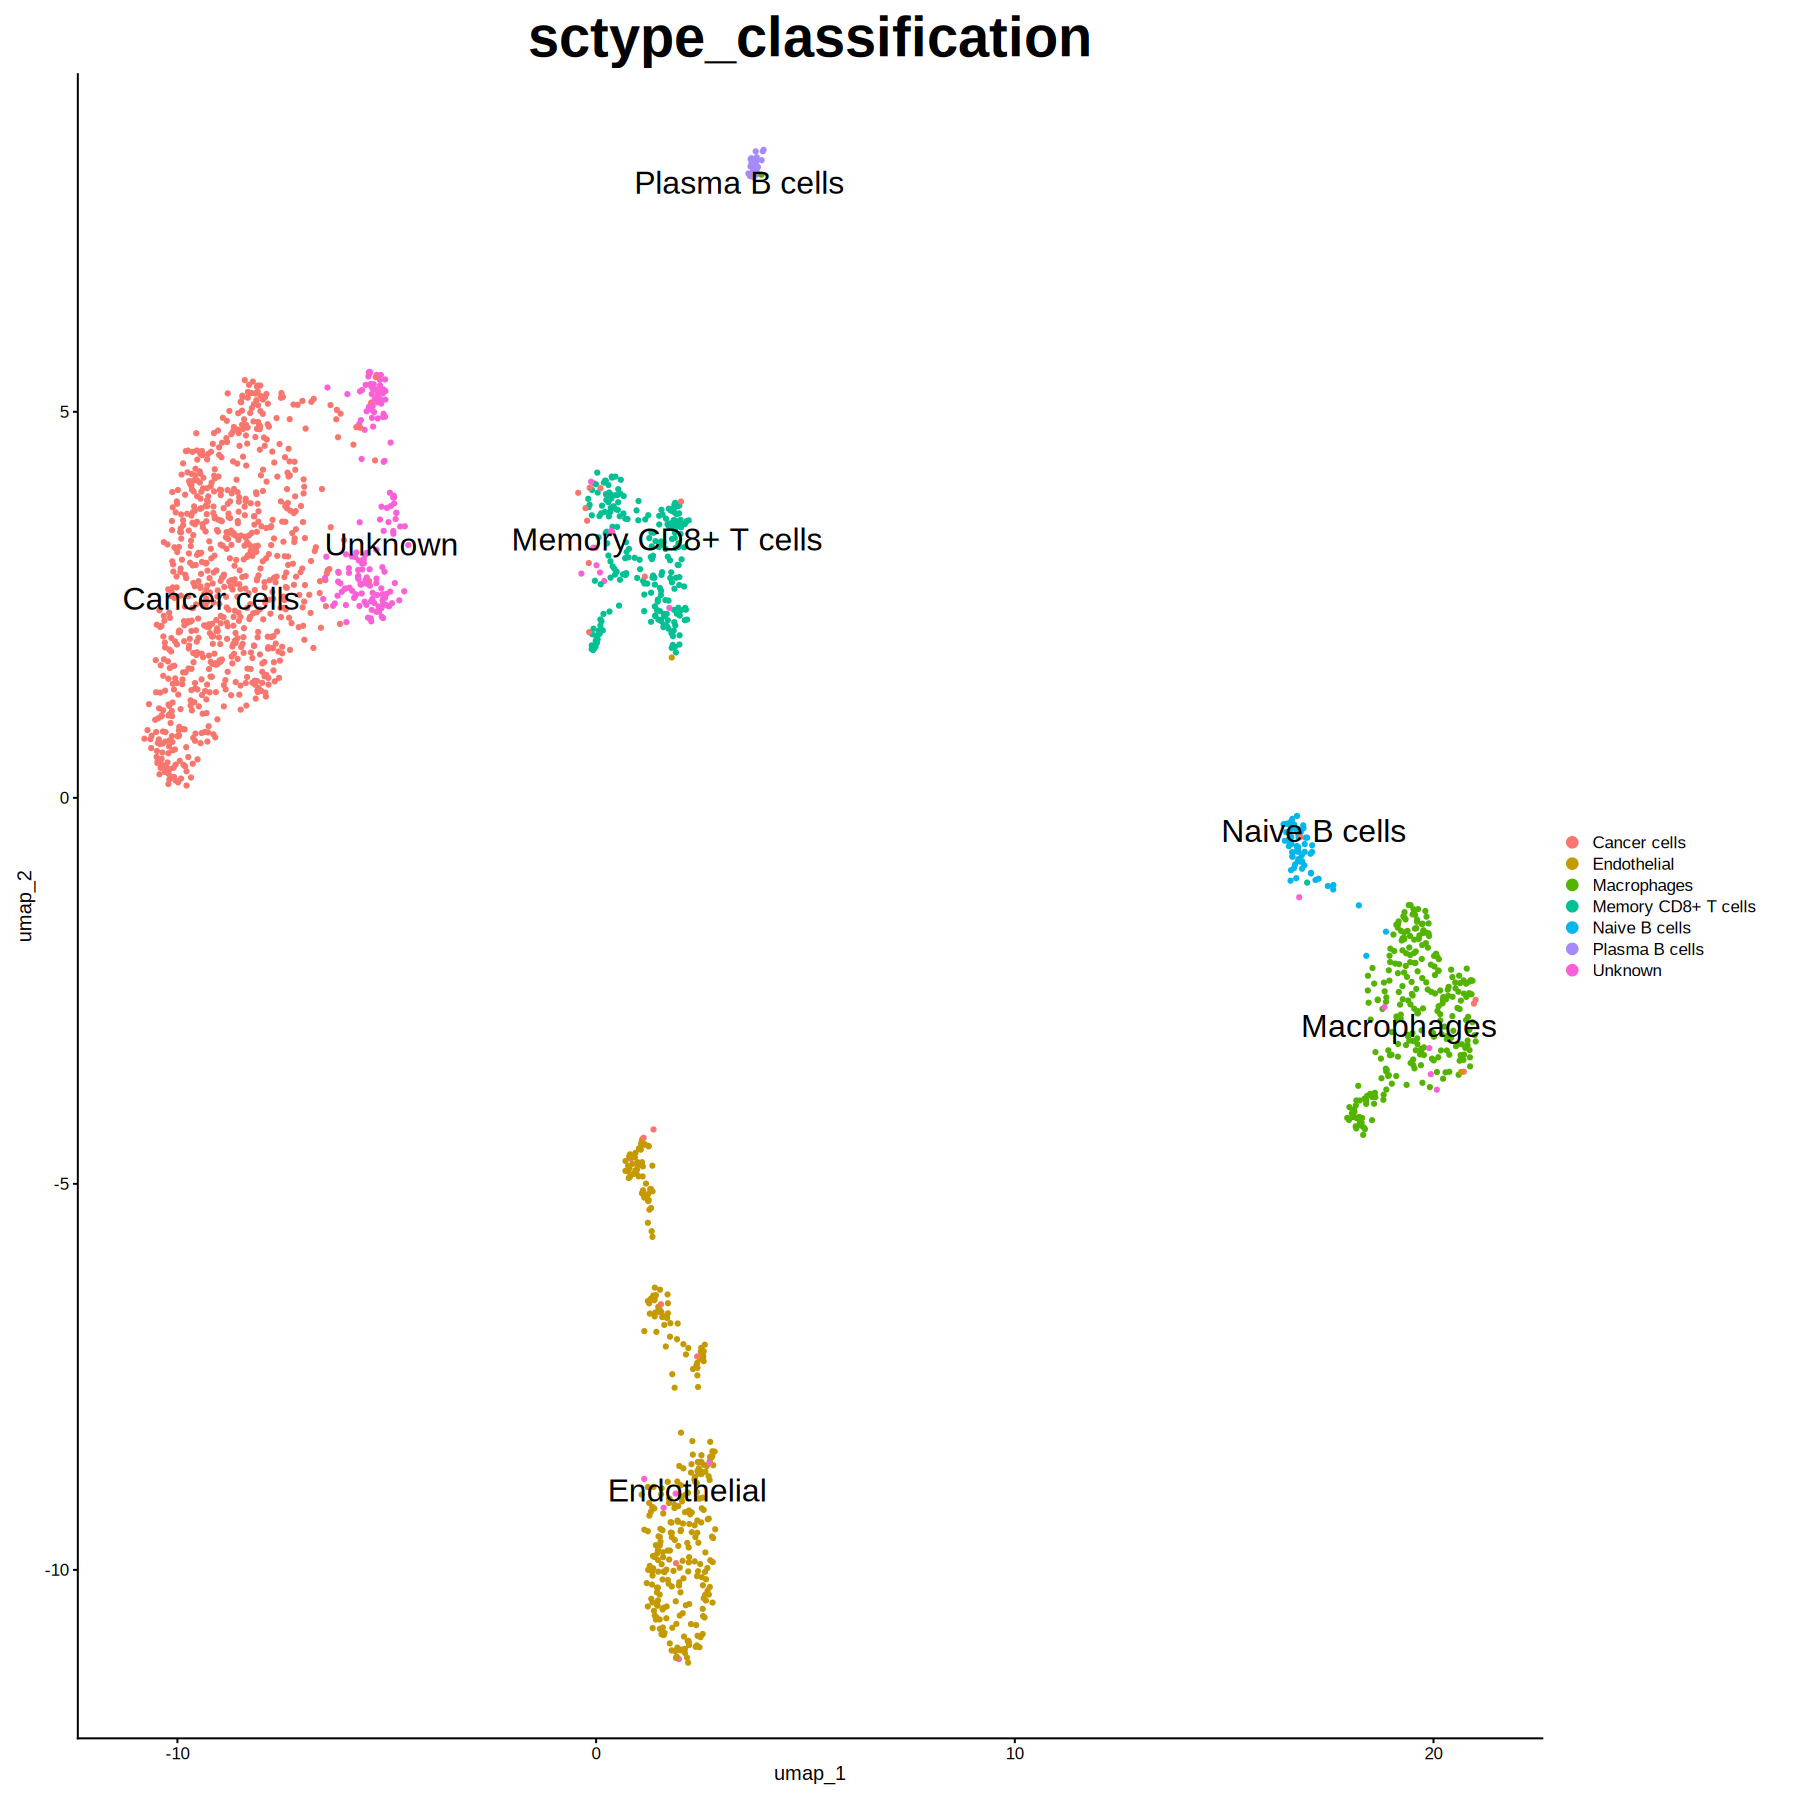

In [44]:
options(repr.plot.width = 18, repr.plot.height = 18, repr.plot.res = 100)
obj40@meta.data$sctype_classification = ""
for(j in unique(sctype_scores$cluster)){
  cl_type = sctype_scores[sctype_scores$cluster==j,];
  obj40@meta.data$sctype_classification[obj40@meta.data$seurat_clusters == j] = as.character(cl_type$type[1])
}

p_sc <- DimPlot(obj40, reduction = "umap", label.size = 8, label = TRUE, repel = TRUE, group.by = 'sctype_classification') & theme(plot.title = element_text(size = 40))
p_sc


# Now lets combine all both annotations together and see what makes sense

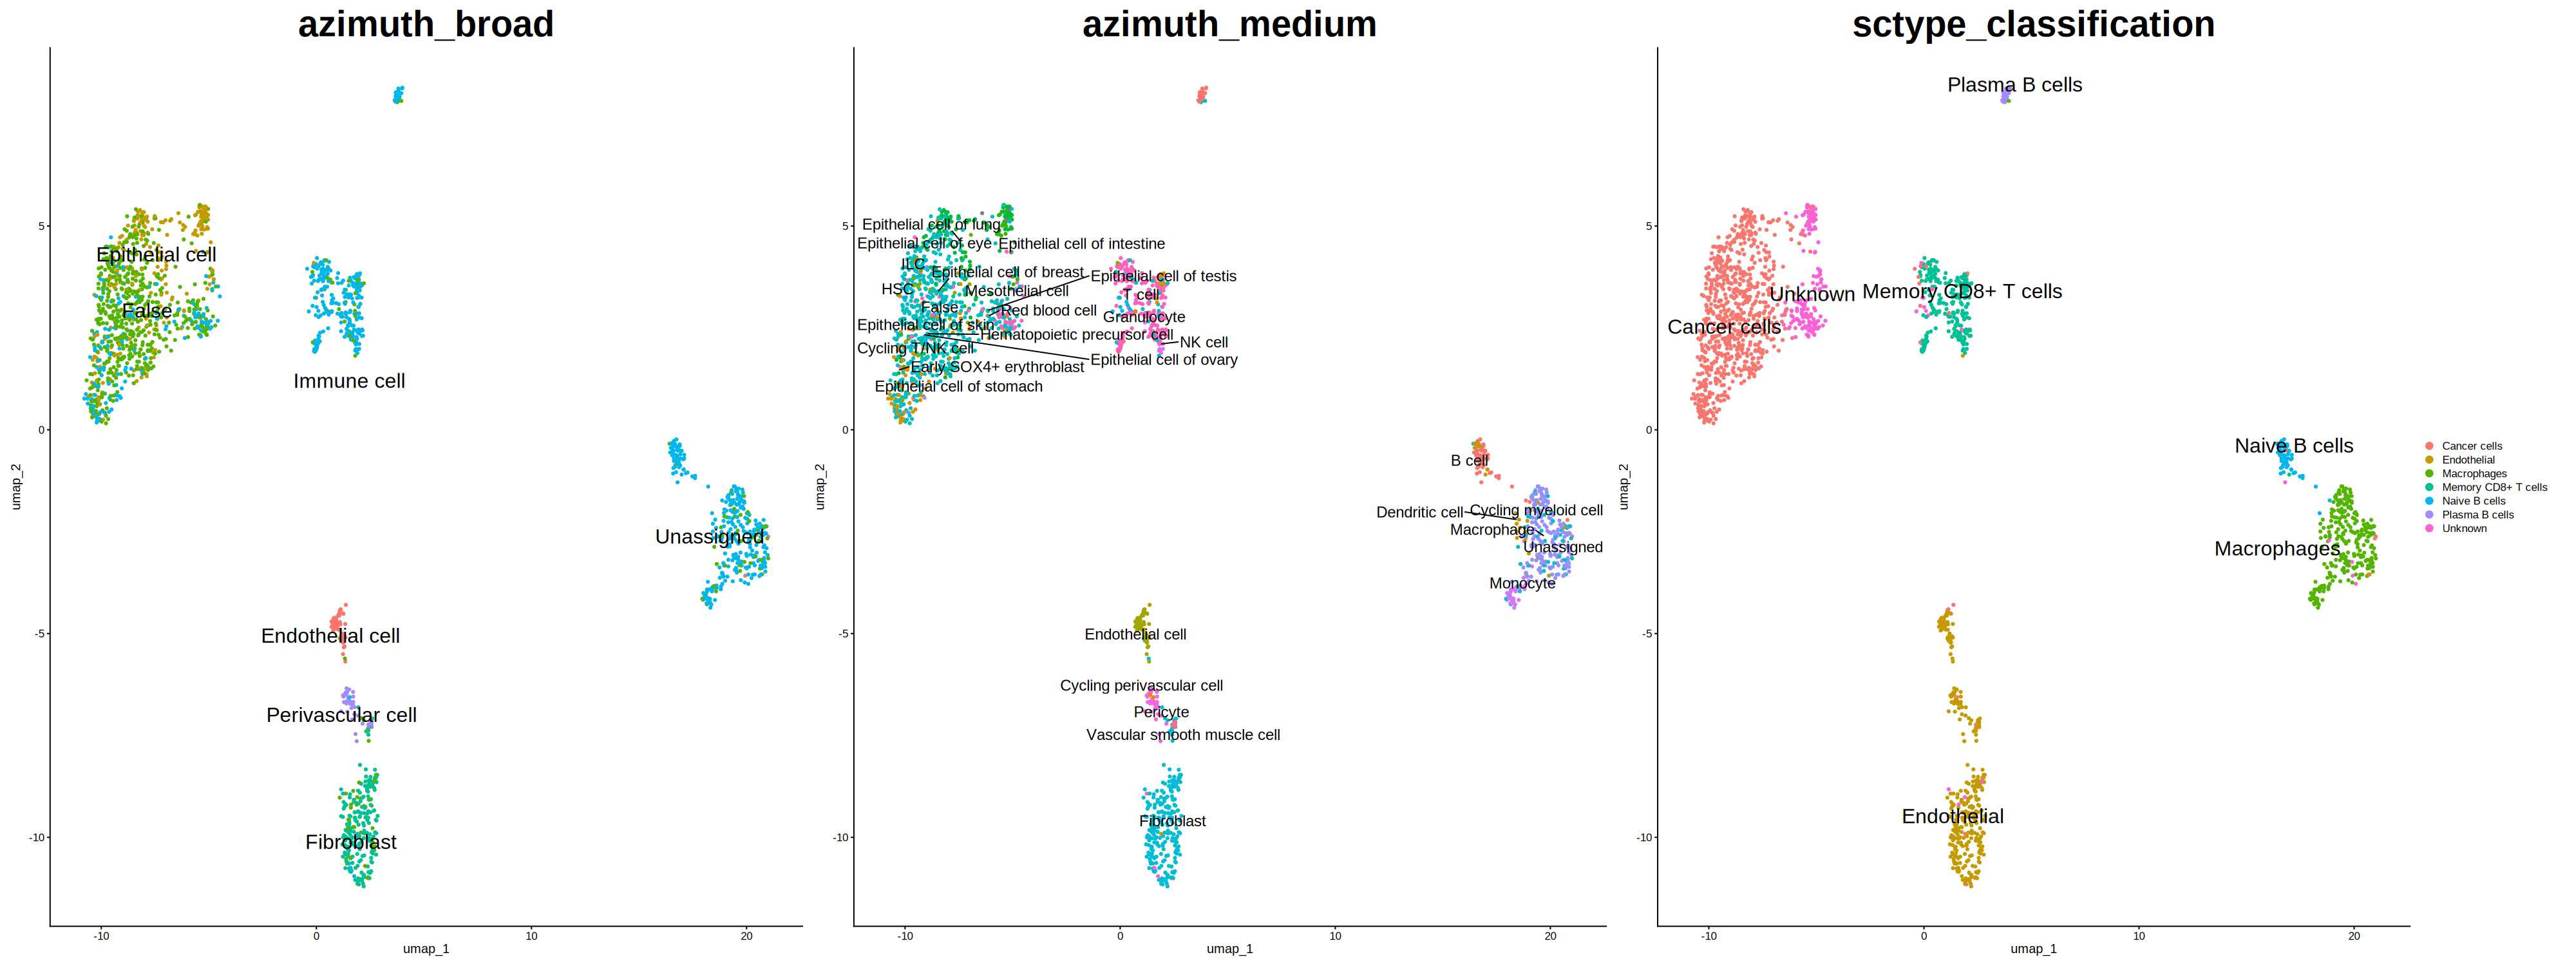

In [45]:
options(repr.plot.width = 40, repr.plot.height = 15, repr.plot.res = 100)
p_az_brd + p_az_med + p_sc

# Cluster proportionality across samples

In [46]:
library(reshape2)

In [47]:
table(obj40$sample)


postT  preT 
 1271   597 

## Cell count by cluster

In [48]:
table(obj40$sctype_classification)


       Cancer cells         Endothelial         Macrophages Memory CD8+ T cells 
                779                 329                 269                 225 
      Naive B cells      Plasma B cells             Unknown 
                 62                  28                 176 

In [49]:
table(obj40$sctype_classification, obj40@meta.data$sample)

                     
                      postT preT
  Cancer cells          497  282
  Endothelial           316   13
  Macrophages           207   62
  Memory CD8+ T cells    56  169
  Naive B cells           9   53
  Plasma B cells         23    5
  Unknown               163   13

## Count of cells per cluster

In [50]:
table_count <- table(obj40$sctype_classification, obj40@meta.data$sample)
table_count <- as.data.frame.matrix(table_count)
table_count

,postT,preT
,<int>,<int>
Cancer cells,497,282
Endothelial,316,13
Macrophages,207,62
Memory CD8+ T cells,56,169
Naive B cells,9,53
Plasma B cells,23,5
Unknown,163,13


## Normalzied count of cells per cluster

In [51]:
apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)})

postT,preT
3910,4723
2486,217
1628,1038
440,2830
70,887
180,83
1282,217


## Plotting the normalized cell counts

In [52]:
table_count_rel <- as.data.frame(apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)}))
table_count_rel$clus <- rownames(table_count)
df <- melt(table_count_rel[,c("clus", 'preT', 'postT')], id.vars=1)

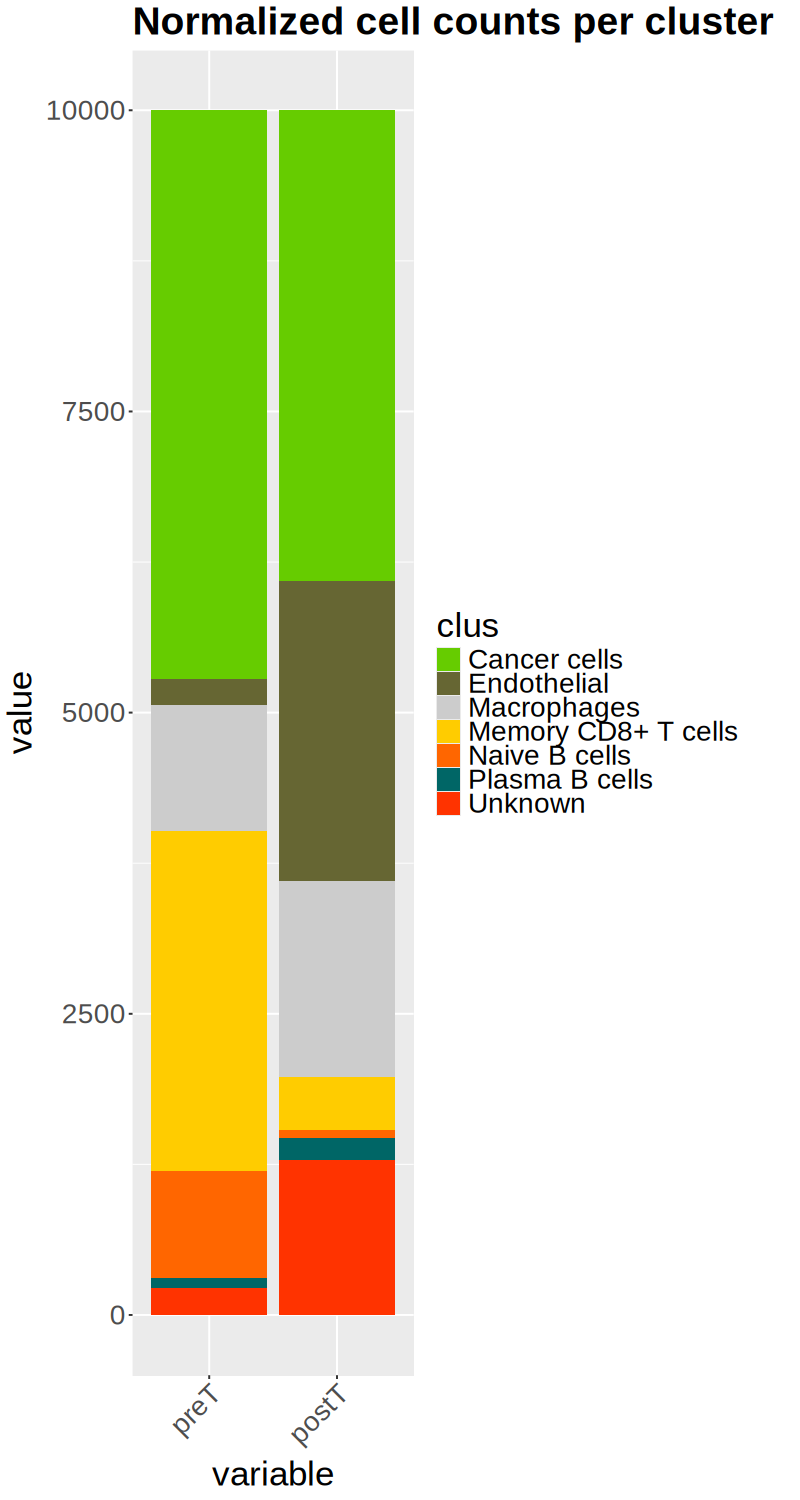

In [53]:
options(repr.plot.width = 8, repr.plot.height = 15, repr.plot.res = 100)
ggplot(df, aes(x = variable, y = value, fill = clus)) +
  geom_bar(position="stack", stat = "identity", width=0.9) +
  scale_fill_manual(values = c("#66CC00","#666633","#CCCCCC", "#FFCC00", "#FF6600", "#006666", "#FF3300", "#CCCC99", "#CC3300", "#0099CC", "#FF3399", "#990066", "#999999", "#006699", "#3399FF", "#99CCFF", "#FFFF00", "#330099", "#660066", "#FFCC66", "#FF9966", "#C5D8F3", "#7ECDBB", "#A6A6A6", "#E6916C", "#CDB7D2","#FBEFAB")) +
  ggtitle("Normalized cell counts per cluster") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  & theme(plot.title = element_text(size = 28, face = "bold")) & theme(text=element_text(size=25))

## Trajectory Analysis (Monocle3)

**What pseudotime actually is, before running any code:** every cell here was captured once, destroyed in the process — we never watch any cell actually change over time. Pseudotime infers a continuum anyway, using a shortcut: cells with similar expression are assumed to sit close together in whatever process is unfolding; very different cells are assumed to be far apart. Ordering cells by that similarity gives a "pseudo" timeline built from a single static snapshot, not a real time-course. The number itself is a *relative distance along a graph* from a root you choose — it has no fixed unit and depends entirely on where you root it; treat it as a within-this-analysis ranking, not an absolute measurement.

**Why a trajectory analysis makes sense for *this* dataset specifically:** this is checkpoint-inhibitor immunotherapy tumor data, pre- and post-treatment. T cell exhaustion — the progressive loss of effector function under chronic antigen exposure — is a textbook example of a real biological continuum (naive/memory → effector → exhausted), not a set of unrelated discrete states, which is exactly the kind of process pseudotime is designed to detect. This is the same "trajectory or not?" judgment call from the lecture: worth deciding deliberately, not just running because the code is available.

**What we're actually hoping to learn:** if a real exhaustion continuum is present and detectable from expression alone, cells rooted at a naive/memory-like population should show low pseudotime, climbing toward cells that look transcriptionally exhausted. The genuine test of whether this is real biology (not just a computational artifact) is checking pseudotime against known exhaustion markers (`PDCD1`, `HAVCR2`, `LAG3`, `TOX`) directly — if pseudotime tracks with these markers, that's real independent evidence. We can also ask a question this dataset is uniquely suited for: does pseudotime *distribution* shift between pre- and post-treatment — i.e., did the therapy actually change where cells sit along this continuum?

In [54]:
#remotes::install_github('cole-trapnell-lab/monocle3')

In [55]:
library(monocle3)

Loading required package: Biobase

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Welcome to Bioc

In [56]:
seurat_to_cds <- function(seurat_obj, assay = "SCT") {
  expr_matrix   <- GetAssayData(seurat_obj, assay = assay, layer = "counts")
  cell_metadata <- seurat_obj@meta.data
  gene_metadata <- data.frame(gene_short_name = rownames(expr_matrix),
                               row.names = rownames(expr_matrix))

  cds <- new_cell_data_set(
    expression_data = expr_matrix,
    cell_metadata   = cell_metadata,
    gene_metadata   = gene_metadata
  )

  reducedDims(cds)$PCA  <- Embeddings(seurat_obj, "pca")
  reducedDims(cds)$UMAP <- Embeddings(seurat_obj, "umap")

  cds
}

cds <- seurat_to_cds(obj40, assay = "SCT")
cds <- cluster_cells(cds)
cds <- learn_graph(cds)

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


**Why the root choice matters and isn't automatic:** Monocle3 has no biological knowledge of which end of the graph is "the beginning" — pseudotime is only interpretable as "progression toward exhaustion" if we deliberately root it at a naive/memory-like population. **EDIT the label below** to match whichever of your `sctype_classification` (or `azimuth_medium`) values actually corresponds to naive/memory T cells once you've looked at the annotation results above — the placeholder name is unlikely to match your data exactly.

In [57]:
# Check what your annotation columns actually produced before editing the label below
table(obj40$sctype_classification)


       Cancer cells         Endothelial         Macrophages Memory CD8+ T cells 
                779                 329                 269                 225 
      Naive B cells      Plasma B cells             Unknown 
                 62                  28                 176 

In [58]:
# EDIT this to match a naive/memory-like label actually present in your data
root_population <- "Memory CD8+ T cells"

root_cells <- colnames(obj40)[obj40$sctype_classification == root_population]
length(root_cells)  # sanity check — should not be 0; if it is, the label above doesn't match

cds <- order_cells(cds, root_cells = root_cells)

[1] 225

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”


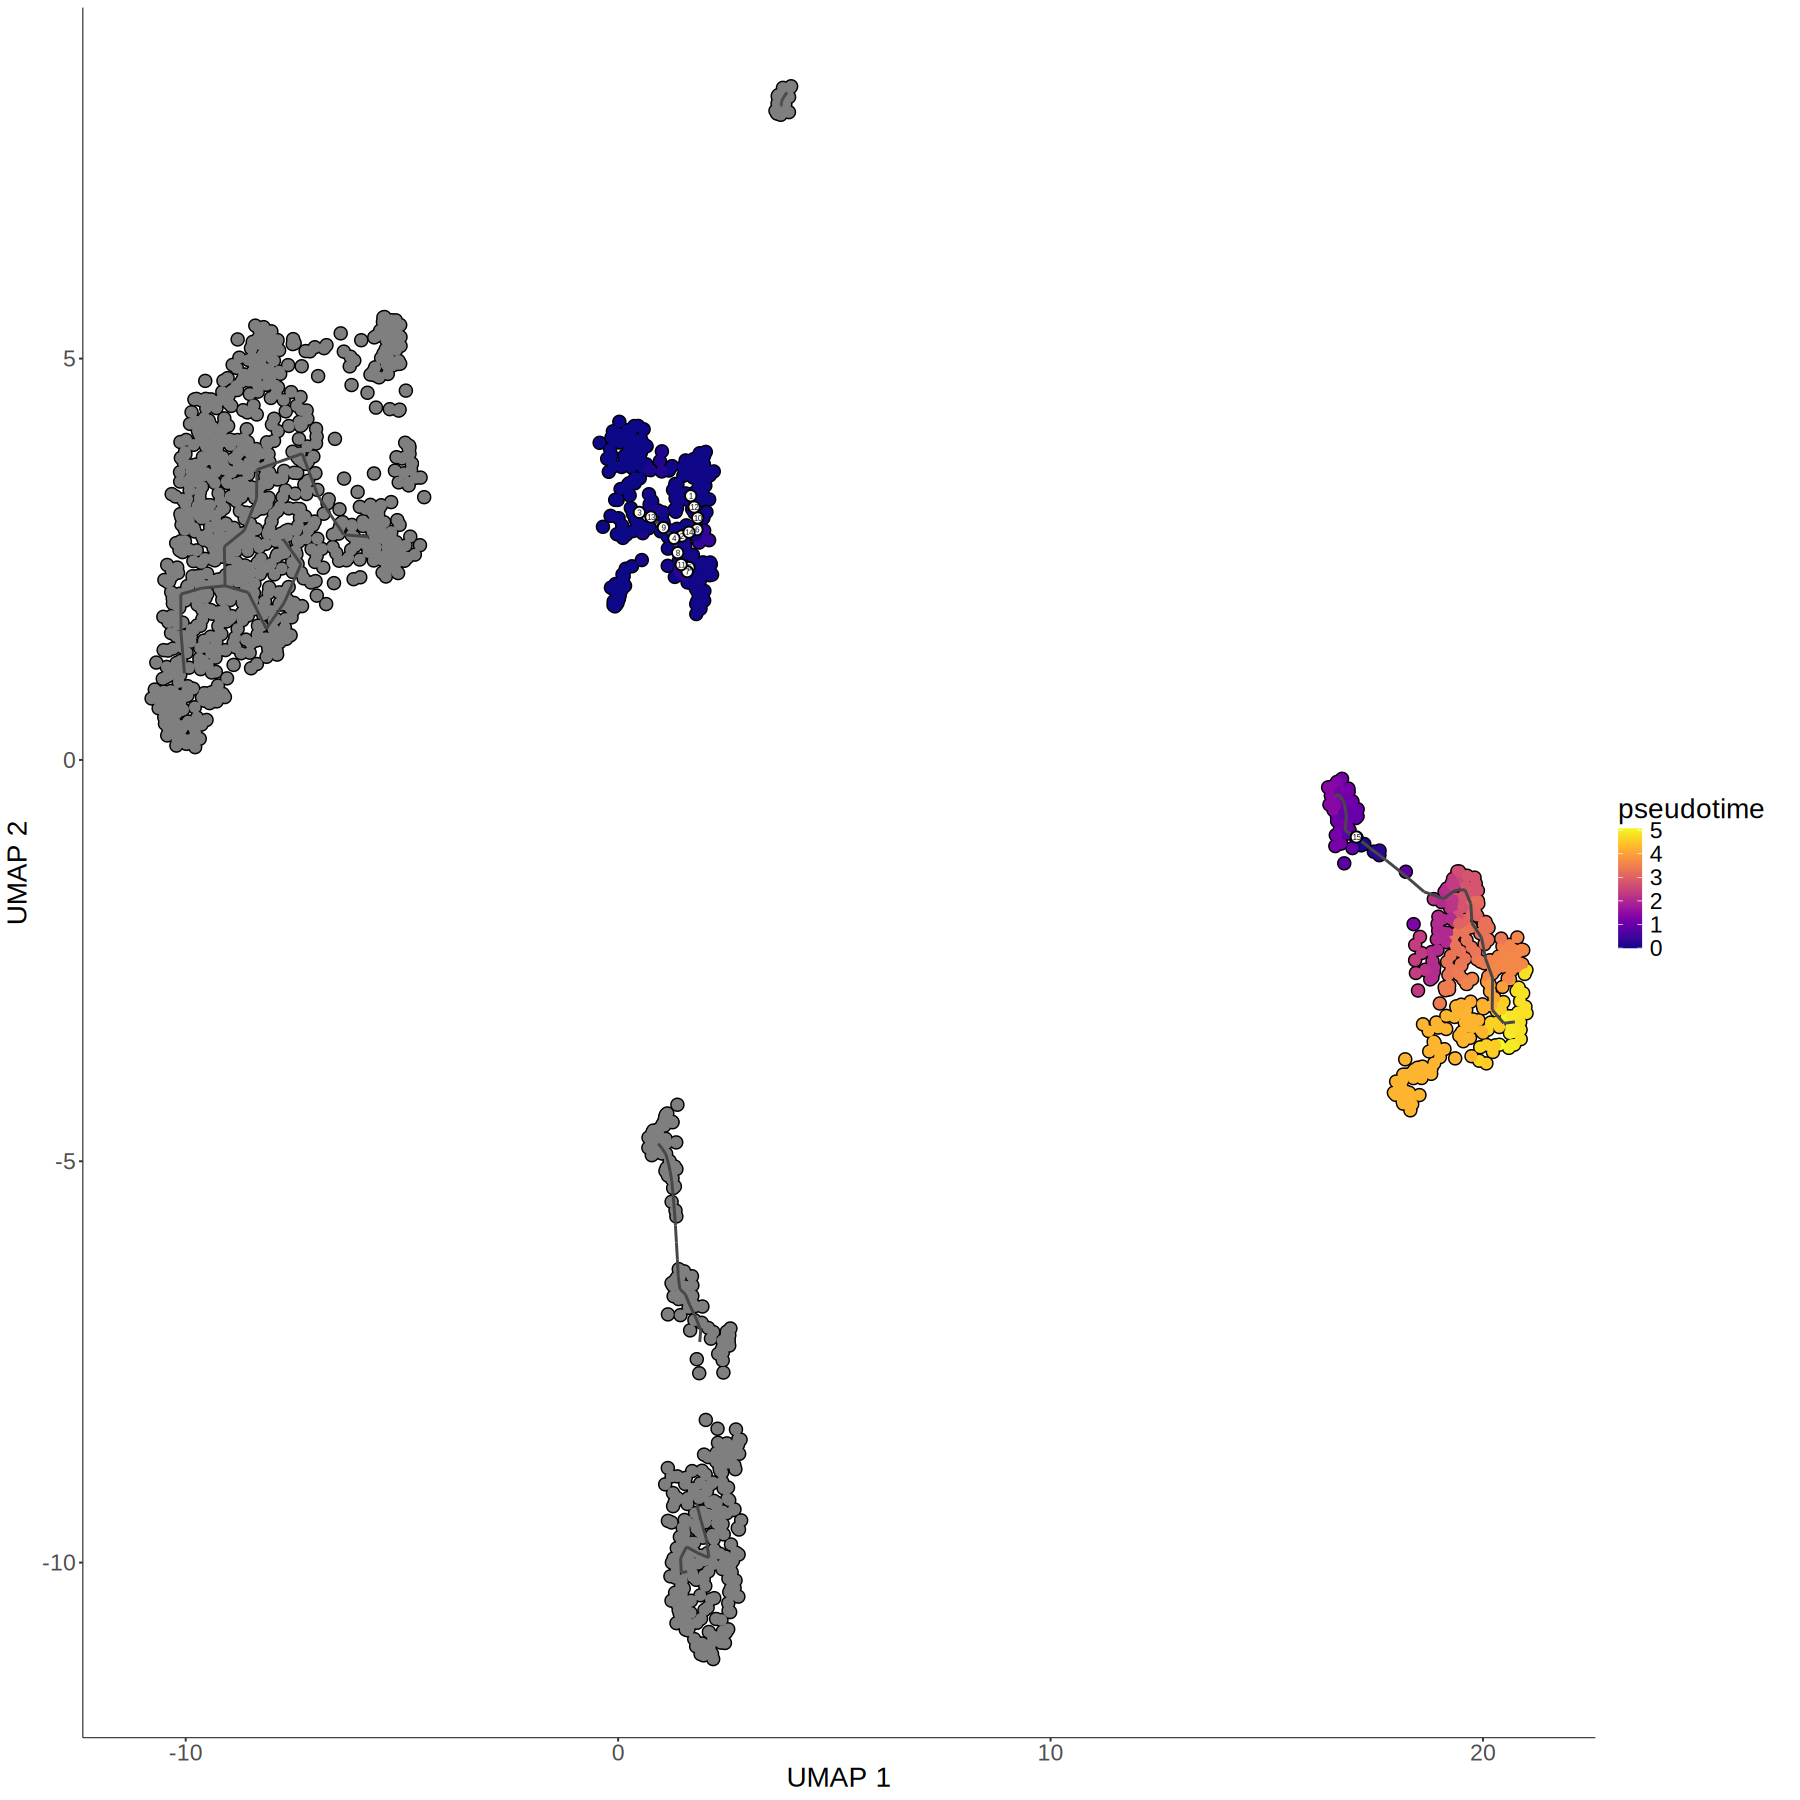

In [59]:
options(repr.plot.width = 18, repr.plot.height = 18, repr.plot.res = 100)
p1.monocle <- plot_cells(cds, color_cells_by = "pseudotime", label_cell_groups = FALSE,
           label_leaves = FALSE, label_branch_points = FALSE, cell_size = 2) + theme(text=element_text(size=20))

p1.monocle

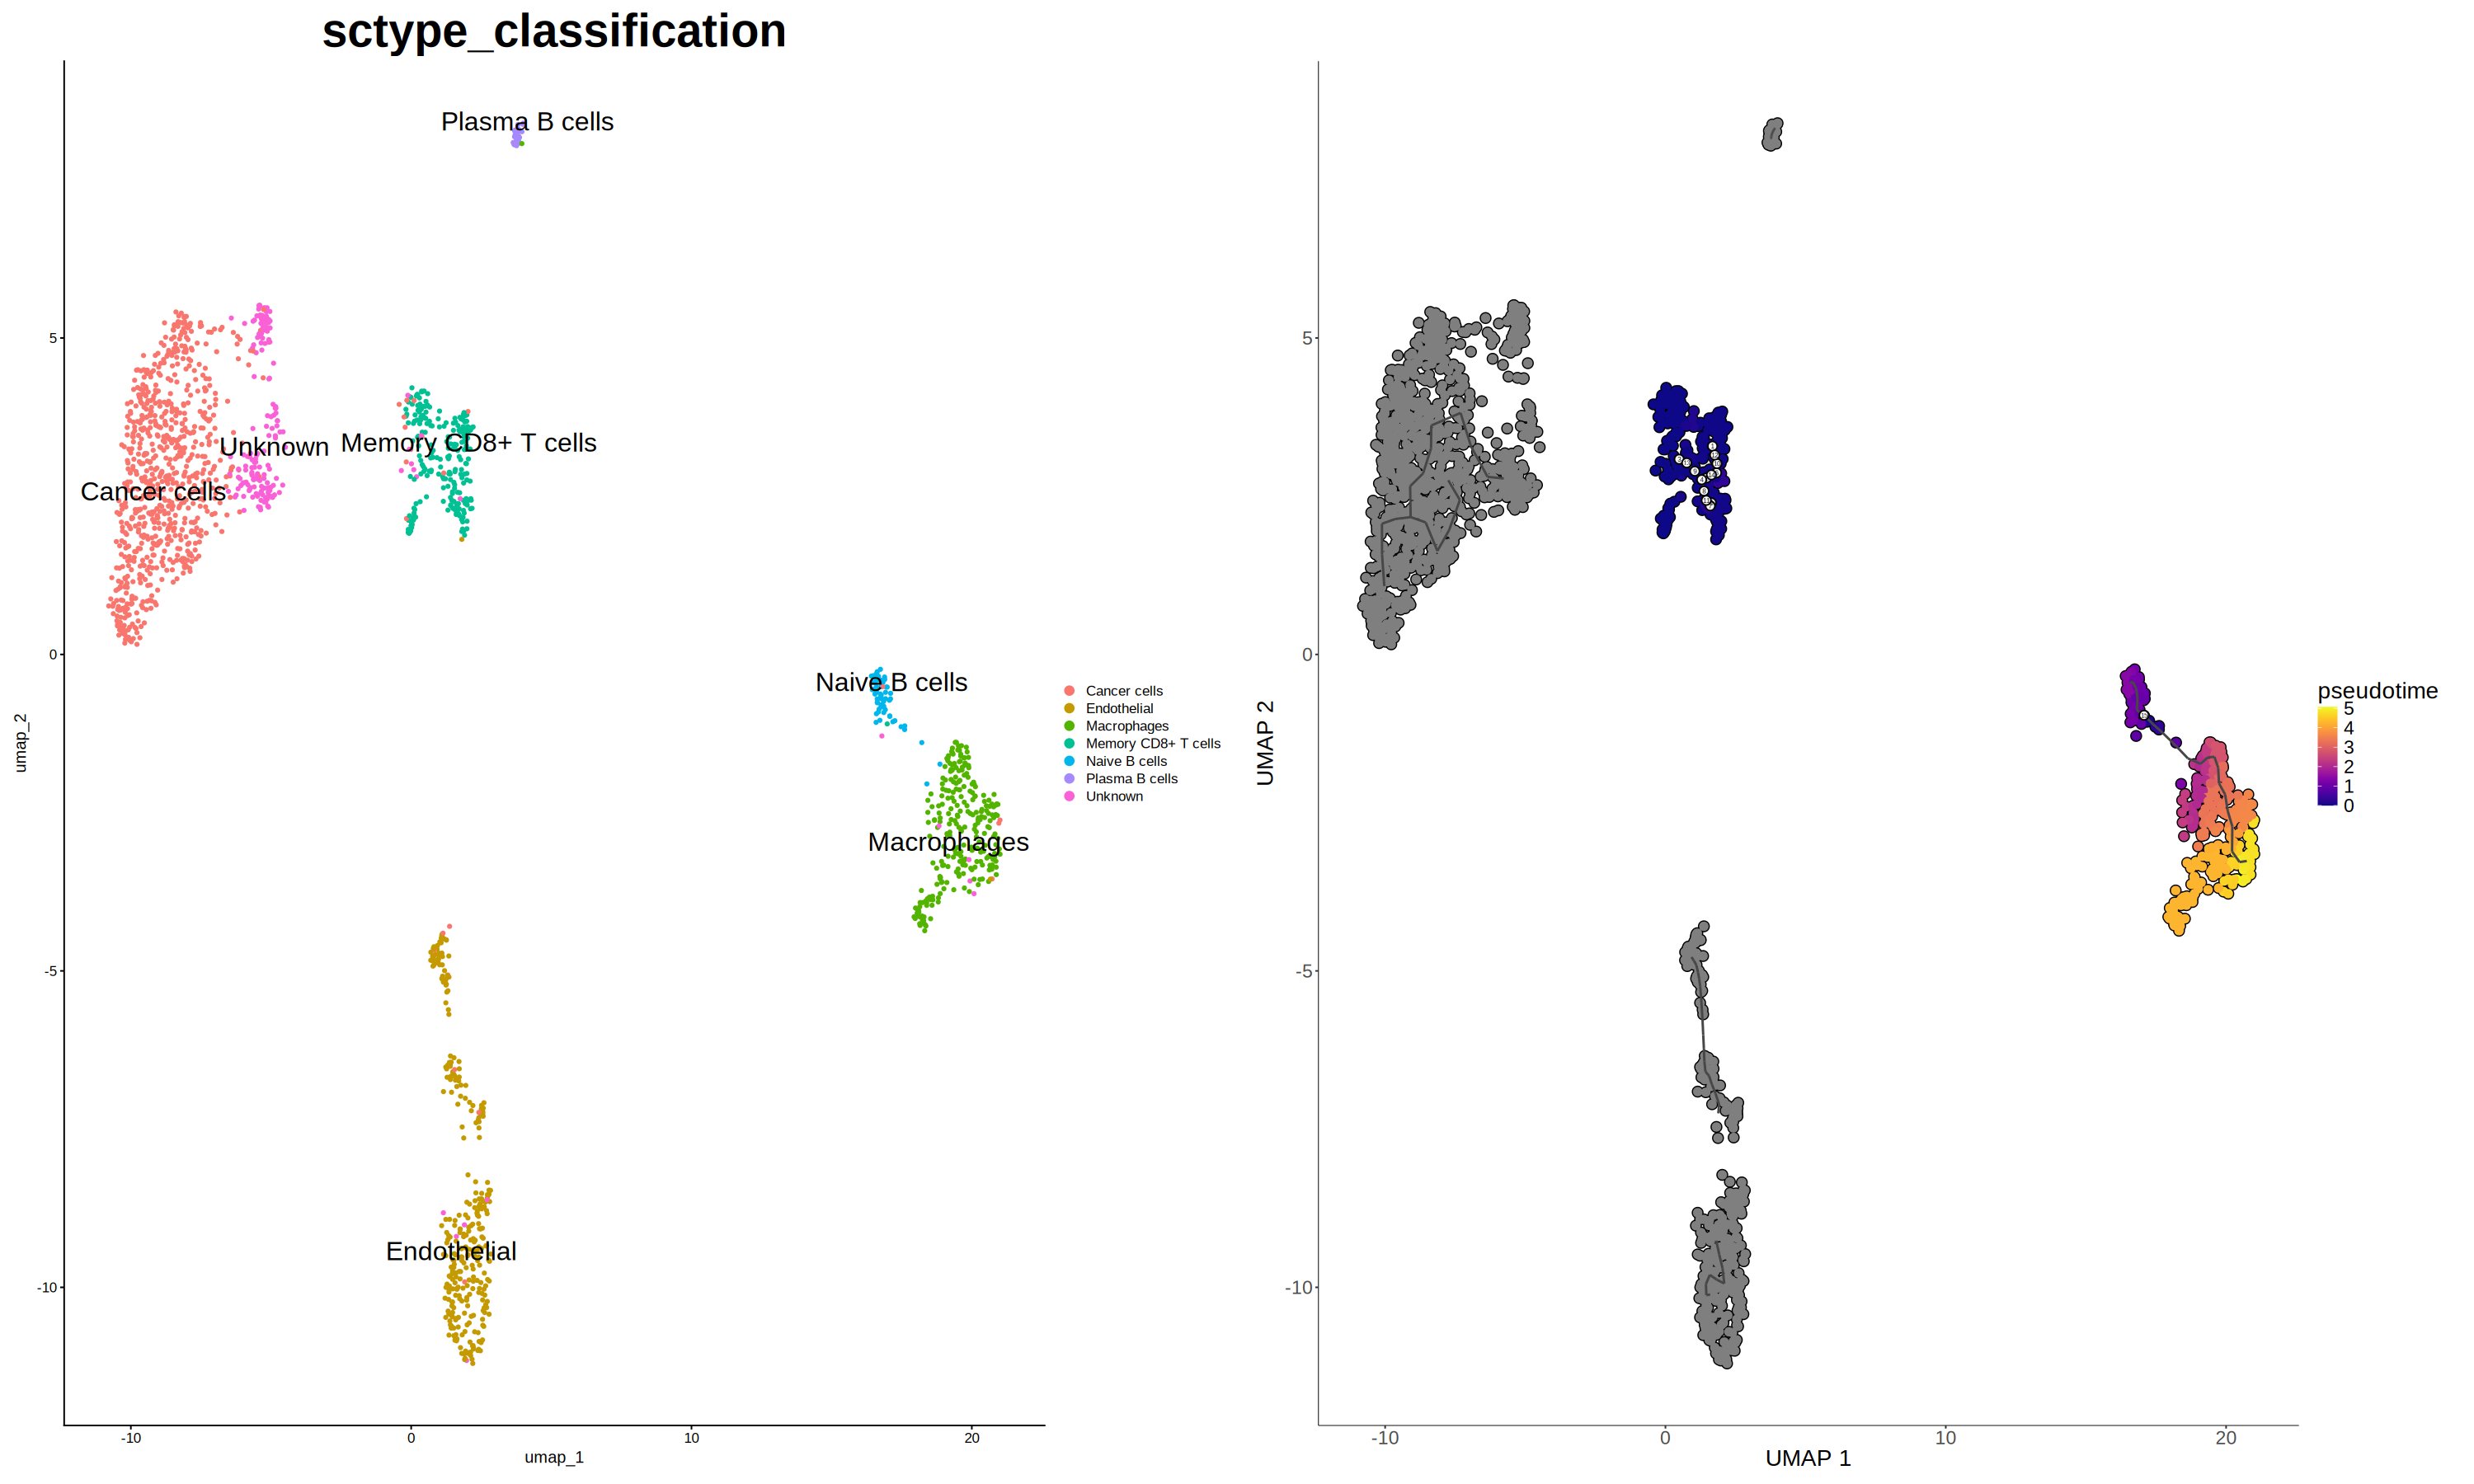

In [60]:
options(repr.plot.width = 30, repr.plot.height = 18, repr.plot.res = 100)
p_sc + p1.monocle

What this plot is actually telling you

Look at the right panel again: there are two separate things happening, not just disconnected noise:

Cancer cells and Endothelial are genuinely disconnected (solid gray, no path from root) — completely correct and expected, since they're unrelated lineages to T cells.
Memory CD8+ T cells (root, dark blue/low pseudotime) IS connected via a graph edge to the Macrophages/Naive B cell blob, which lights up in a real gradient up to ~5. That thin bridging line with numbered nodes is Monocle3 saying "I found a path from your root into this other population."

That second part is the actual problem. T cells differentiating into macrophages isn't real biology — they're different lineages (lymphoid vs. myeloid) entirely. What you're looking at is almost certainly a UMAP-space artifact: learn_graph() doesn't know anything about biology, it just connects whatever's geometrically closest in the reduced-dimension embedding, and a handful of ambiguous or lower-quality cells sitting between those two populations was enough to bridge them. The gradient climbing to yellow inside the Macrophage blob looks like a real trajectory, but it's measuring "distance from T cells" for cells that aren't T cells — not meaningful.

### Summary for participants

Two things are worth taking away from this section, beyond any single plot:

1. **Running a trajectory across unrelated cell types produces a graph that looks connected but isn't biologically real.** The whole-tumor attempt bridged T cells to macrophages — two different lineages — simply because of geometric proximity in UMAP space, not real differentiation. Always restrict trajectory analysis to a population you have a specific, defensible reason to think lies on one continuum, and check the result against known markers before trusting it.

2. **Even after correctly restricting to T cells only, this particular dataset couldn't support the analysis.** With roughly 150-225 captured T cells — a direct consequence of subsampling to a small read depth for this workshop — we hit real limits: `FindClusters()` returned a single undifferentiated cluster, `AddModuleScore()` failed outright on too few distinct expression values to bin, and even score-based rooting ended up selecting nearly the entire population rather than a genuine top fraction.

**Both outcomes are legitimate results to report, not failures of the method.** A real analysis on a full-depth dataset would be expected to avoid both problems, given enough cells and enough sequencing depth per cell. The value here is in recognizing *why* each of these went wrong, so the same mistakes — running trajectory across unrelated lineages, or trusting an automated method past the point your data can actually support — are avoidable on your own future analyses.

# Cell-Cell Communication (NicheNet)

**Why sender/receiver are cell types here, not spatial domains:** unlike the spatial notebook, there's no tissue geography here — sender and receiver are dissociated cell populations from the annotation above (e.g., does a myeloid population signal to CD8+ T cells?). NicheNet doesn't ask "which ligand-receptor pairs are expressed here" — it asks "which of the sender's ligands best explain the specific expression differences I already found in the receiver," which is why the gene set of interest below has to come from a real DE comparison, not just an expression cutoff.

**A genuine advantage over the spatial notebook here:** the spatial analysis needed an imperfect pseudo-replicate workaround for pseudobulk DE, because there was only one tissue section. Here, pre-treatment and post-treatment are real, independent samples — so the DE comparison feeding into `geneset_oi` below rests on much firmer statistical footing.

In [61]:
library(nichenetr)
library(tidyverse)

Registered S3 method overwritten by 'pROC':
  method   from            
  plot.roc spatstat.explore

Warning message:
“replacing previous import ‘e1071::element’ by ‘ggplot2::element’ when loading ‘nichenetr’”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
✔ readr     2.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()    masks IRanges::%within%()
✖ IRanges::collapse()      masks dplyr::collapse()
✖ Biobase::combine()       masks BiocGenerics::combine(), dplyr::combine()
✖ matrixStats::count()     masks dplyr::count()
✖ IRanges::desc()          masks dplyr::desc()
✖ tidyr::expand()          masks S4Vectors::expand()
✖ dplyr::filter()          masks stats::filter()
✖ S4Vectors::first()       masks dplyr::first()
✖ dplyr::lag()             masks stats::lag()
✖ BiocGenerics:

In [63]:
# Prior model download (once; see NicheNet documentation for current links)

#if(organism == "human"){
#  lr_network <- readRDS(url("https://zenodo.org/record/7074291/files/lr_network_human_21122021.rds"))
#  ligand_target_matrix <- readRDS(url("https://zenodo.org/record/7074291/files/ligand_target_matrix_nsga2r_final.rds"))
#  weighted_networks <- readRDS(url("https://zenodo.org/record/7074291/files/weighted_networks_nsga2r_final.rds"))
#} else if(organism == "mouse"){
#  lr_network <- readRDS(url("https://zenodo.org/record/7074291/files/lr_network_mouse_21122021.rds"))
#  ligand_target_matrix <- readRDS(url("https://zenodo.org/record/7074291/files/ligand_target_matrix_nsga2r_final_mouse.rds"))
#  weighted_networks <- readRDS(url("https://zenodo.org/record/7074291/files/weighted_networks_nsga2r_final_mouse.rds"))
#}
organism = "human"

lr_network <- readRDS("./lr_network_human_21122021.rds")
ligand_target_matrix <- readRDS("ligand_target_matrix_nsga2r_final.rds")
weighted_networks <- readRDS("weighted_networks_nsga2r_final.rds")

In [64]:
table(obj40$sctype_classification)
#receiver_cells@meta.data


       Cancer cells         Endothelial         Macrophages Memory CD8+ T cells 
                779                 329                 269                 225 
      Naive B cells      Plasma B cells             Unknown 
                 62                  28                 176 

In [65]:
Idents(obj40) <- "sctype_classification"

sender_ids   <- "Macrophages"      # EDIT — e.g., a myeloid/APC population
receiver_ids <- "Naive B cells"     # EDIT — e.g., the T cell population of interest

obj40 <- PrepSCTFindMarkers(obj40)  # once, on the full object, before any subsetting

# Combined identity instead of subset() + re-set Idents — subset() can lose
# track of PrepSCTFindMarkers()'s correction state with multiple SCT models,
# so we run FindMarkers directly on the full object instead
obj40$celltype_sample <- paste(obj40$sctype_classification, obj40$sample, sep = "_")
Idents(obj40) <- "celltype_sample"

de_receiver <- FindMarkers(
  obj40,
  ident.1 = paste0(receiver_ids, "_postT"),
  ident.2 = paste0(receiver_ids, "_preT"),
  assay = "SCT", test.use = "wilcox", min.pct = 0.1, logfc.threshold = 0.1
)
geneset_oi <- de_receiver %>% filter(p_val_adj < 0.05, avg_log2FC > 0.25) %>% rownames()
length(geneset_oi)  # sanity check — should not be 0

# Reset Idents back to plain cell types — everything below this point needs
# sender_ids/receiver_ids to resolve against sctype_classification, not
# the combined celltype_sample identity used just above
Idents(obj40) <- "sctype_classification"

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 2045.95476398253



[1] 23

**Why the expressed-gene sets below are computed from `WhichCells()` subsets, not the whole object:** this is the exact bug we found and fixed in the spatial notebook — `sender_ids`/`receiver_ids` have to actually subset the data used for everything downstream, or changing them silently has no effect on the results. Worth double-checking this every time `sender_ids`/`receiver_ids` change.

In [66]:
sender_cells_ids   <- WhichCells(obj40, idents = sender_ids)
receiver_cells_ids <- WhichCells(obj40, idents = receiver_ids)

sct_counts <- GetAssayData(obj40, assay = "SCT", layer = "counts")

expressed_genes_sender   <- rownames(obj40)[rowSums(sct_counts[, sender_cells_ids] > 0) > 10]
expressed_genes_receiver <- rownames(obj40)[rowSums(sct_counts[, receiver_cells_ids] > 0) > 10]

ligands   <- lr_network %>% pull(from) %>% unique()
receptors <- lr_network %>% pull(to) %>% unique()
expressed_ligands   <- intersect(ligands, expressed_genes_sender)
expressed_receptors <- intersect(receptors, expressed_genes_receiver)

potential_ligands <- lr_network %>%
  filter(from %in% expressed_ligands & to %in% expressed_receptors) %>%
  pull(from) %>% unique()

ligand_activities <- predict_ligand_activities(
  geneset = geneset_oi,
  background_expressed_genes = expressed_genes_receiver,
  ligand_target_matrix = ligand_target_matrix,
  potential_ligands = potential_ligands
)

ligand_activities %>% arrange(desc(aupr_corrected)) %>% head(10)

test_ligand,auroc,aupr,aupr_corrected,pearson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
COL5A1,0.5856636,0.07069415,0.05278138,0.10061009
COL1A1,0.6029721,0.06956398,0.05165121,0.08409035
GDF5,0.5812157,0.06745337,0.04954060,0.04517750
CNTN1,0.5684240,0.06727859,0.04936582,0.06044448
WNT3A,0.5666655,0.06595248,0.04803971,0.06286882
MDK,0.6021791,0.03652317,0.01861040,0.05801624
EFEMP1,0.5786988,0.03498015,0.01706738,0.04426550
CEACAM6,0.5607696,0.03089321,0.01298044,0.03490971
IFITM1,0.5446678,0.03035692,0.01244415,0.04005480


### Ligand → predicted target gene heatmap

In [67]:
plot_heatmap <- function(mat, y_name, x_name, color = "purple", legend_title = "Score") {
  df <- as.data.frame(mat) %>%
    tibble::rownames_to_column("y") %>%
    tidyr::pivot_longer(-y, names_to = "x", values_to = "score") %>%
    dplyr::mutate(
      y = factor(y, levels = rownames(mat)),
      x = factor(x, levels = colnames(mat))
    )

  ggplot(df, aes(x = x, y = y, fill = score)) +
    geom_tile(color = "white") +
    scale_fill_gradient(low = "whitesmoke", high = color, name = legend_title) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    labs(x = x_name, y = y_name) + theme(plot.title = element_text(size = 28, face = "bold")) + theme(text=element_text(size=25))
}

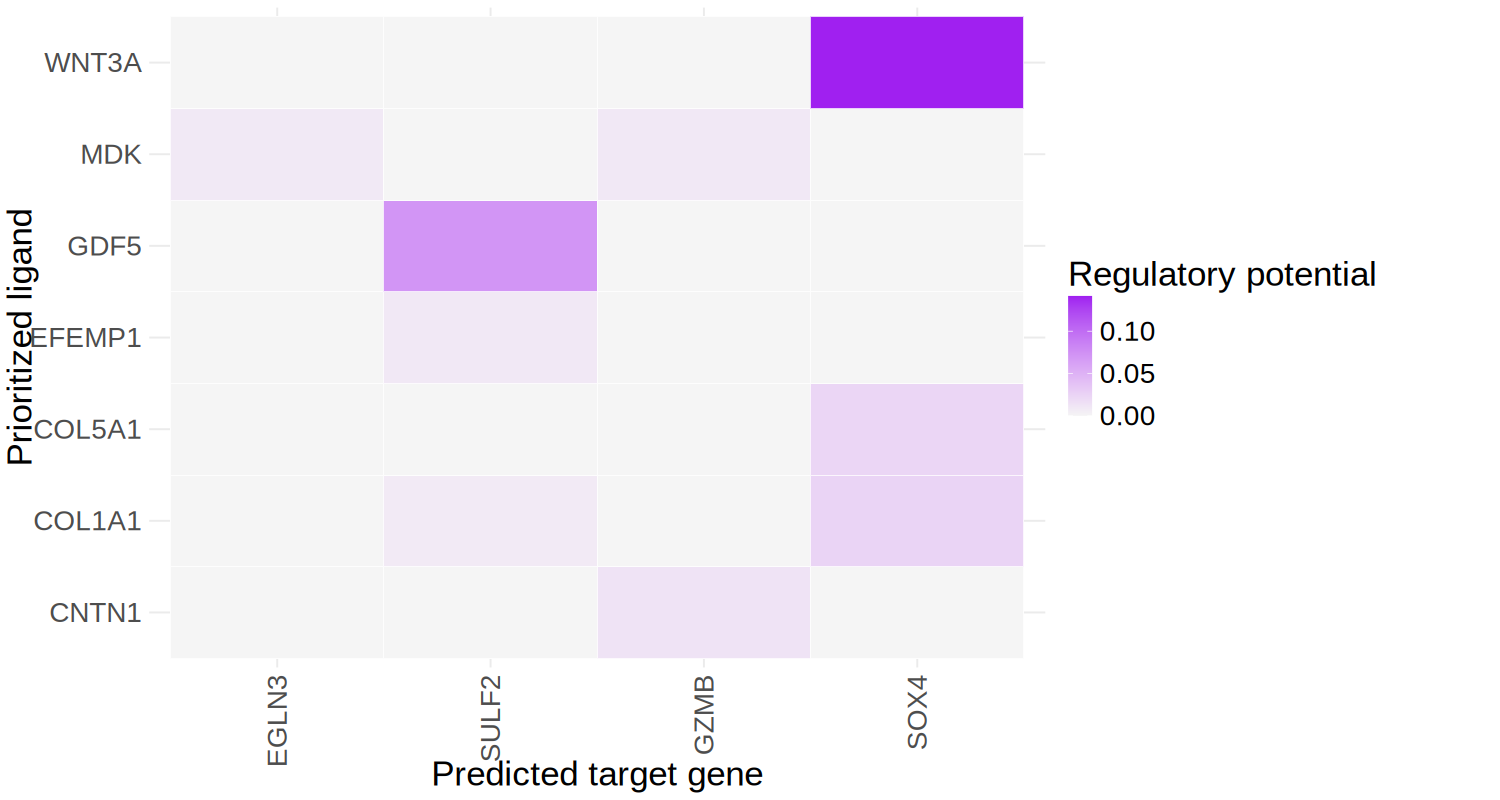

In [68]:
best_upstream_ligands <- ligand_activities %>% top_n(10, aupr_corrected) %>% pull(test_ligand)

active_ligand_target_links_df <- best_upstream_ligands %>%
  lapply(get_weighted_ligand_target_links, geneset = geneset_oi,
         ligand_target_matrix = ligand_target_matrix, n = 200) %>%
  bind_rows() %>%
  drop_na()

active_ligand_target_links <- prepare_ligand_target_visualization(
  ligand_target_df = active_ligand_target_links_df,
  ligand_target_matrix = ligand_target_matrix
)

order_ligands <- intersect(best_upstream_ligands, colnames(active_ligand_target_links))
order_targets <- active_ligand_target_links_df$target %>% unique() %>%
  intersect(rownames(active_ligand_target_links))

vis_ligand_target <- active_ligand_target_links[order_targets, order_ligands] %>% t()

options(repr.plot.width = 15, repr.plot.height = 8, repr.plot.res = 100)
plot_heatmap(
  vis_ligand_target, y_name = "Prioritized ligand", x_name = "Predicted target gene",
  color = "purple", legend_title = "Regulatory potential"
)

**How to read this:** each row is a top-ranked sender ligand; each column is a gene from the real pre-vs-post DE result above. A dark cell means the ligand plausibly drives that specific target gene, per NicheNet's prior model — look for ligands with several genuinely dark cells across the DE gene set, not just a high overall ranking score.

### Ligand → receptor heatmap

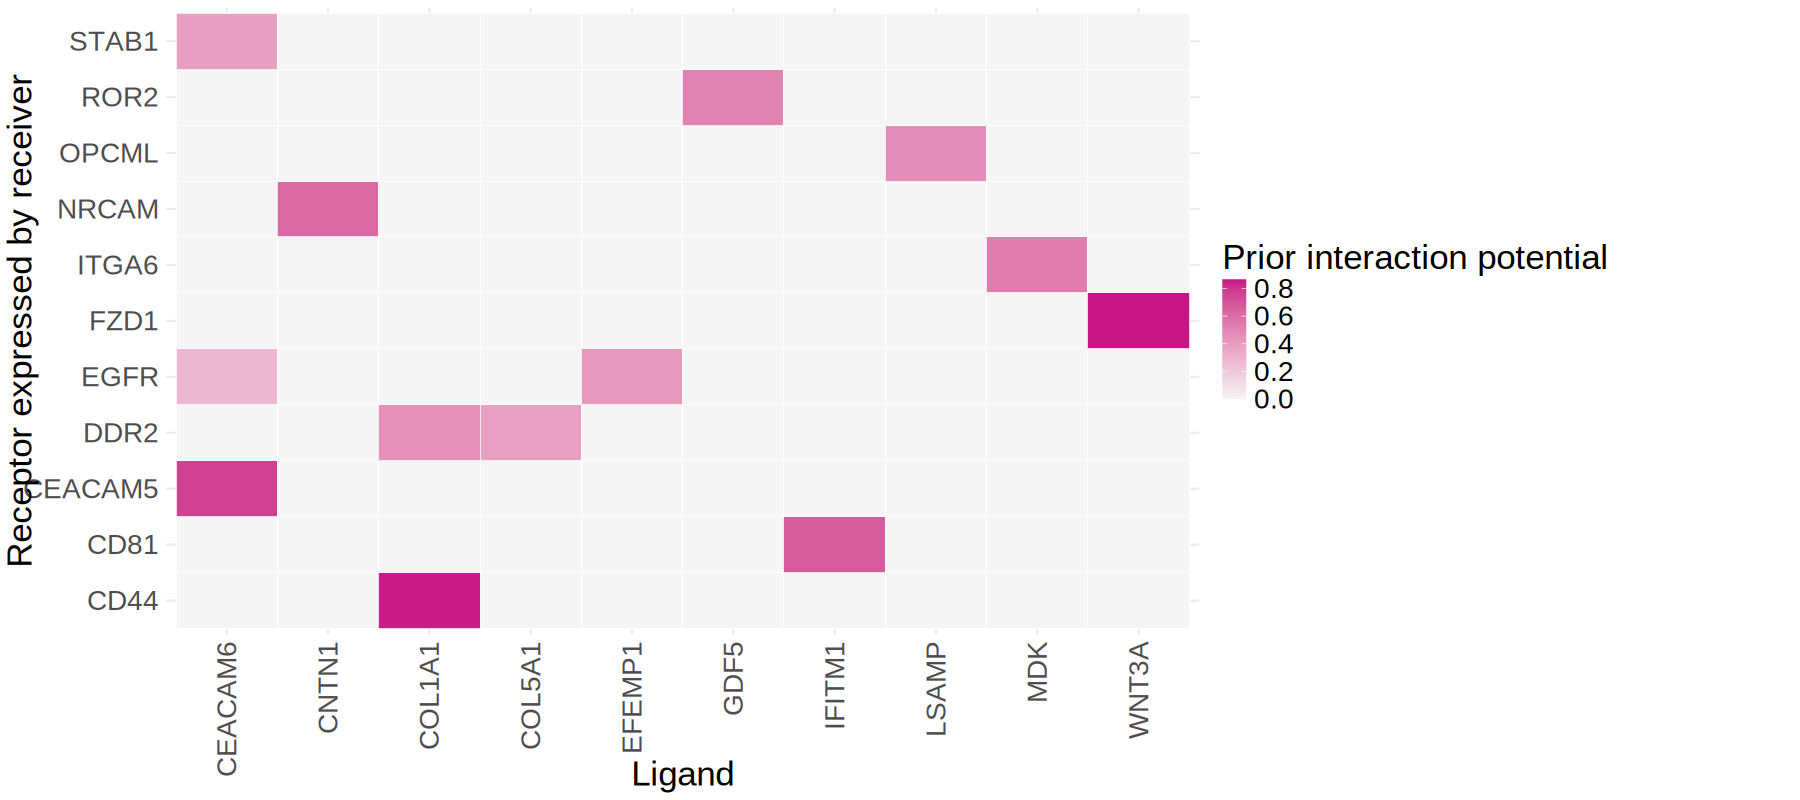

In [69]:
lr_network_top_df_large <- get_weighted_ligand_receptor_links(
  best_upstream_ligands, expressed_receptors, lr_network, weighted_networks$lr_sig
)

# NOTE: uses lr_network's own "from"/"to" naming (ligand/receptor)
lr_network_top_df <- lr_network_top_df_large %>%
  tidyr::spread(from, weight, fill = 0)

lr_network_top_matrix <- lr_network_top_df %>% dplyr::select(-to) %>% as.matrix()
rownames(lr_network_top_matrix) <- lr_network_top_df$to

options(repr.plot.width = 18, repr.plot.height = 8, repr.plot.res = 100)
plot_heatmap(
  lr_network_top_matrix, y_name = "Receptor expressed by receiver", x_name = "Ligand",
  color = "mediumvioletred", legend_title = "Prior interaction potential"
)

**Why this is a different question from the ligand-target heatmap:** that one asks whether a ligand plausibly explains downstream expression changes — mechanistic but indirect. This one asks the literal question: does the receiver actually express a known receptor for this ligand? A ligand that scores well on target prediction but pairs with a barely-expressed receptor is a weaker candidate than the ranking alone suggests.

### Checking the top pair against sample (pre- vs. post-treatment)

**Why this check, in place of the spatial proximity check from the other notebook:** there's no tissue geography here to check co-localization against, but there is something equally informative — does this predicted interaction actually change with treatment? A ligand-receptor pair that shifts between pre- and post-treatment is a much stronger candidate to have played a real role in the treatment response than one that looks identical regardless of treatment.

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.



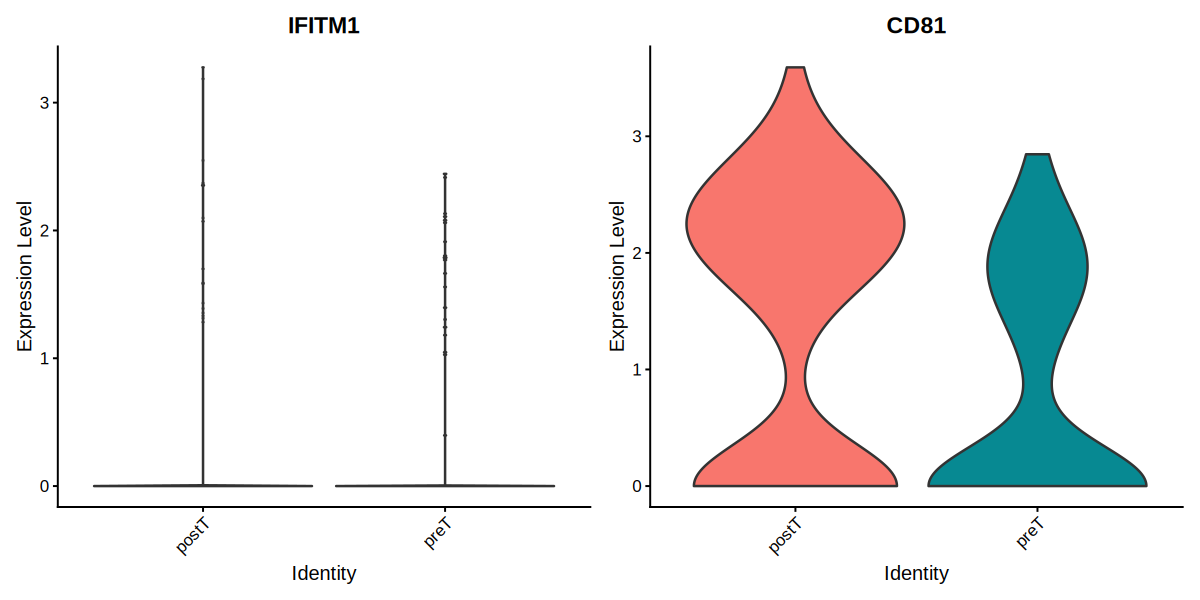

In [70]:
top_pair <- lr_network_top_df_large %>% dplyr::arrange(desc(weight)) %>% dplyr::slice(4)
top_ligand   <- top_pair$from
top_receptor <- top_pair$to

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 100)
VlnPlot(obj40, features = c(top_ligand, top_receptor), group.by = "sample",
        idents = c(sender_ids, receiver_ids), split.by = "sample", pt.size = 0) #+ theme(plot.title = element_text(size = 28, face = "bold")) + theme(text=element_text(size=25))

**What to look for:** a real treatment effect on this signaling axis would show up as the ligand (in the sender) and/or the receptor (in the receiver) shifting between `preT` and `postT` — not just being present at some constant level regardless of treatment. If neither changes with treatment, this pair may be a real interaction in this tumor generally, but not one that's obviously part of the treatment response specifically.

In [71]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] lubridate_1.9.5             forcats_1.0.1              
 [3] stringr_1.6.0               purrr_1.2.2                
 [5] readr_2.2.0                 tidyr_1.3.